# Cleaning the Structural Data for FreeSurfer Morphometry Volumetrics

--------------------------------------------------------------


##### 1- ✅ load the data parts creat a single CSV file and remove the bad subject files 

In [1]:
import os
import pandas as pd
import glob
import re

# Define the input and output folders
input_folder = r"D:\image_group_data\team44\output_for_freesurfer_table"
output_folder = r"D:\image_group_data\team44\Analysis"  # Change the output folder here

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Initialize an empty dictionary to hold subject data
data_dict = {}

import csv

def extract_subject_data(file_path):
    with open(file_path, "r") as f:
        reader = csv.reader(f, delimiter='\t')  # Use tab delimiter for flexibility
        try:
            header = next(reader)  # Read first line as header
            values = next(reader)  # Read second line as values
            return dict(zip(header, values))
        except StopIteration:
            print(f"⚠️ Skipping file {file_path}: Unexpected format (less than 2 lines)")
            return {}


# Define regex patterns for healthy and diseased files
healthy_pattern = re.compile(r"subH\d+.*\.txt|h\d+sub.*\.txt|team44HC4sub\d+.*\.txt|team44HC1sub\d+.*\.txt")
diseased_pattern = re.compile(r"sub(?!H)\d+.*\.txt|team44OLF1sub\d+.*\.txt")

# Loop through all files in the input folder
for file in glob.glob(os.path.join(input_folder, "*.txt")):
    subject_id = os.path.basename(file).split("_")[0]  # Extract subject ID (e.g., sub16 or h1sub13)
    if subject_id not in data_dict:
        data_dict[subject_id] = {}
    # Extract data and update the dictionary
    data_dict[subject_id].update(extract_subject_data(file))
    # Assign label based on the pattern
    if healthy_pattern.match(os.path.basename(file)):
        data_dict[subject_id]['Label'] = 0  # Healthy
    elif diseased_pattern.match(os.path.basename(file)):
        data_dict[subject_id]['Label'] = 1  # Diseased

# Convert the dictionary to a DataFrame
df = pd.DataFrame.from_dict(data_dict, orient='index')

# List of columns to drop
columns_to_remove = [
    "lh.aparc.thickness", "lh.aparc.area", "lh.aparc.volume",
    "lh.aparc.meancurv", "lh.aparc.gauscurv", "lh.aparc.foldind",
    "lh.aparc.curvind", "rh.aparc.thickness", "rh.aparc.area",
    "rh.aparc.volume", "rh.aparc.meancurv", "rh.aparc.gauscurv",
    "rh.aparc.foldind", "rh.aparc.curvind", "Measure:volume"
]

existing_cols_to_remove = [col for col in columns_to_remove if col in df.columns]
df = df.drop(columns=existing_cols_to_remove, errors='ignore')
print(f"✅ Dropped columns: {existing_cols_to_remove}")

df

✅ Dropped columns: ['lh.aparc.thickness', 'lh.aparc.area', 'lh.aparc.volume', 'lh.aparc.meancurv', 'lh.aparc.gauscurv', 'lh.aparc.foldind', 'lh.aparc.curvind', 'rh.aparc.thickness', 'rh.aparc.area', 'rh.aparc.volume', 'rh.aparc.meancurv', 'rh.aparc.gauscurv', 'rh.aparc.foldind', 'rh.aparc.curvind', 'Measure:volume']


,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness,lh_isthmuscingulate_thickness,lh_lateraloccipital_thickness,...,TotalGrayVol,SupraTentorialVol,SupraTentorialVolNotVent,MaskVol,BrainSegVol-to-eTIV,MaskVol-to-eTIV,lhSurfaceHoles,rhSurfaceHoles,SurfaceHoles,EstimatedTotalIntraCranialVol
sub16,2.704,2.802,2.672,1.749,2.644,2.714,2.444,2.823,2.185,2.062,...,622036.884414,966751.0,905631.0,1694483.0,0.689533,1.050711,20.0,22.0,42.0,1612701.318921
sub17,2.401,2.598,2.478,1.901,3.08,2.889,2.529,2.857,2.234,2.075,...,688990.393091,1024754.0,1006051.0,1682209.0,0.749185,1.062534,10.0,6.0,16.0,1583204.401422
sub18,2.466,2.727,2.513,1.701,3.292,2.779,2.516,2.757,2.122,2.264,...,512770.5535,794211.0,782908.0,1291292.0,0.747144,1.062753,15.0,8.0,23.0,1215044.48758
sub19,2.392,2.881,2.706,1.79,3.924,2.725,2.378,2.891,1.984,2.146,...,560506.845884,831027.0,812128.0,1365079.0,0.717366,1.027163,17.0,5.0,22.0,1328979.404305
sub20,2.587,2.213,2.659,1.789,2.53,2.496,2.414,2.915,2.197,2.082,...,644750.018873,1008111.0,964479.0,1781938.0,0.678061,1.048266,18.0,14.0,32.0,1699890.349671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
team44OLF1sub11,2.567,2.447,2.506,1.845,3.344,2.718,2.436,2.644,2.213,1.988,...,683289.64575,1014612.0,1002035.0,1637663.0,0.842192,1.171425,42.0,34.0,76.0,1398009.238147
team44OLF1sub12,2.724,2.65,2.708,1.837,2.854,2.711,2.518,2.766,2.586,2.006,...,688678.508993,1084577.0,1058033.0,1707101.0,0.877942,1.229401,17.0,10.0,27.0,1388563.556448
team44OLF1sub13,2.506,2.436,2.518,1.831,2.97,2.61,2.479,2.761,1.957,2.201,...,653837.028503,1005469.0,964503.0,1653335.0,0.701736,1.00275,17.0,10.0,27.0,1648801.602325
team44OLF1sub14,2.799,2.282,2.671,2.104,3.469,2.944,2.658,2.888,2.349,2.171,...,704111.215824,1073774.0,1052492.0,1759066.0,0.769821,1.11546,15.0,16.0,31.0,1576987.683405


In [2]:
df.reset_index(inplace=True)
df.rename(columns={"index": "Subject_ID"}, inplace=True)
df  # Verify that "Subject_ID" appears as a column


,Subject_ID,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness,lh_isthmuscingulate_thickness,...,TotalGrayVol,SupraTentorialVol,SupraTentorialVolNotVent,MaskVol,BrainSegVol-to-eTIV,MaskVol-to-eTIV,lhSurfaceHoles,rhSurfaceHoles,SurfaceHoles,EstimatedTotalIntraCranialVol
0,sub16,2.704,2.802,2.672,1.749,2.644,2.714,2.444,2.823,2.185,...,622036.884414,966751.0,905631.0,1694483.0,0.689533,1.050711,20.0,22.0,42.0,1612701.318921
1,sub17,2.401,2.598,2.478,1.901,3.08,2.889,2.529,2.857,2.234,...,688990.393091,1024754.0,1006051.0,1682209.0,0.749185,1.062534,10.0,6.0,16.0,1583204.401422
2,sub18,2.466,2.727,2.513,1.701,3.292,2.779,2.516,2.757,2.122,...,512770.5535,794211.0,782908.0,1291292.0,0.747144,1.062753,15.0,8.0,23.0,1215044.48758
3,sub19,2.392,2.881,2.706,1.79,3.924,2.725,2.378,2.891,1.984,...,560506.845884,831027.0,812128.0,1365079.0,0.717366,1.027163,17.0,5.0,22.0,1328979.404305
4,sub20,2.587,2.213,2.659,1.789,2.53,2.496,2.414,2.915,2.197,...,644750.018873,1008111.0,964479.0,1781938.0,0.678061,1.048266,18.0,14.0,32.0,1699890.349671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,team44OLF1sub11,2.567,2.447,2.506,1.845,3.344,2.718,2.436,2.644,2.213,...,683289.64575,1014612.0,1002035.0,1637663.0,0.842192,1.171425,42.0,34.0,76.0,1398009.238147
101,team44OLF1sub12,2.724,2.65,2.708,1.837,2.854,2.711,2.518,2.766,2.586,...,688678.508993,1084577.0,1058033.0,1707101.0,0.877942,1.229401,17.0,10.0,27.0,1388563.556448
102,team44OLF1sub13,2.506,2.436,2.518,1.831,2.97,2.61,2.479,2.761,1.957,...,653837.028503,1005469.0,964503.0,1653335.0,0.701736,1.00275,17.0,10.0,27.0,1648801.602325
103,team44OLF1sub14,2.799,2.282,2.671,2.104,3.469,2.944,2.658,2.888,2.349,...,704111.215824,1073774.0,1052492.0,1759066.0,0.769821,1.11546,15.0,16.0,31.0,1576987.683405


In [3]:
# Remove bad subjects (from the second code block)
subjects_to_remove = [
    "sub20", "sub34","sub39","sub21","sub16", "sub22","sub30","sub31","sub41",
    'team44HC4sub57','team44OLF1sub01','team44OLF1sub02','team44OLF1sub03','team44OLF1sub04',
    'team44OLF1sub06','team44OLF1sub13','team44OLF1sub15']  

df_Struc_subR = df[~df['Subject_ID'].isin(subjects_to_remove)].copy()

# Specify the output file path for the cleaned data with bad subjects removed
output_file_cleaned = os.path.join(output_folder, "structural_subR.csv")

# Save the cleaned data with subjects removed
df_Struc_subR.to_csv(output_file_cleaned, index=False)

print(f"Table with bad subjects removed saved at: {output_file_cleaned}")
df_Struc_subR

Table with bad subjects removed saved at: D:\image_group_data\team44\Analysis\structural_subR.csv


,Subject_ID,lh_bankssts_thickness,lh_caudalanteriorcingulate_thickness,lh_caudalmiddlefrontal_thickness,lh_cuneus_thickness,lh_entorhinal_thickness,lh_fusiform_thickness,lh_inferiorparietal_thickness,lh_inferiortemporal_thickness,lh_isthmuscingulate_thickness,...,TotalGrayVol,SupraTentorialVol,SupraTentorialVolNotVent,MaskVol,BrainSegVol-to-eTIV,MaskVol-to-eTIV,lhSurfaceHoles,rhSurfaceHoles,SurfaceHoles,EstimatedTotalIntraCranialVol
1,sub17,2.401,2.598,2.478,1.901,3.08,2.889,2.529,2.857,2.234,...,688990.393091,1024754.0,1006051.0,1682209.0,0.749185,1.062534,10.0,6.0,16.0,1583204.401422
2,sub18,2.466,2.727,2.513,1.701,3.292,2.779,2.516,2.757,2.122,...,512770.5535,794211.0,782908.0,1291292.0,0.747144,1.062753,15.0,8.0,23.0,1215044.48758
3,sub19,2.392,2.881,2.706,1.79,3.924,2.725,2.378,2.891,1.984,...,560506.845884,831027.0,812128.0,1365079.0,0.717366,1.027163,17.0,5.0,22.0,1328979.404305
7,sub23,2.563,2.552,2.605,1.906,3.347,2.875,2.582,2.959,2.36,...,660144.989857,1014763.0,994588.0,1633833.0,0.757246,1.075988,8.0,14.0,22.0,1518449.159226
8,sub24,2.662,2.232,2.471,1.819,3.111,2.703,2.48,2.75,2.154,...,645388.214993,1057731.0,1031136.0,1609433.0,0.750861,1.004338,11.0,13.0,24.0,1602481.299915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,team44OLF1sub09,2.601,2.889,2.512,1.991,3.56,2.721,2.383,2.81,2.385,...,706096.407534,1008095.0,974718.0,1717265.0,0.722445,1.0669,28.0,21.0,49.0,1609584.521933
99,team44OLF1sub10,2.22,2.356,2.385,1.881,2.966,2.395,2.343,2.362,2.103,...,665541.698293,1034545.0,975558.0,1777866.0,0.715325,1.079515,41.0,23.0,64.0,1646912.485982
100,team44OLF1sub11,2.567,2.447,2.506,1.845,3.344,2.718,2.436,2.644,2.213,...,683289.64575,1014612.0,1002035.0,1637663.0,0.842192,1.171425,42.0,34.0,76.0,1398009.238147
101,team44OLF1sub12,2.724,2.65,2.708,1.837,2.854,2.711,2.518,2.766,2.586,...,688678.508993,1084577.0,1058033.0,1707101.0,0.877942,1.229401,17.0,10.0,27.0,1388563.556448


##### 2- ✅ checking and removing the null values -> no null no duplicate

------------------------------


<span style="color:red">should it be for each  mean or median group?</span>


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import skew

# ✅ Load the dataset
df = pd.read_csv(r'D:\image_group_data\team44\Analysis\structural_subR.csv')

# ✅ 1️⃣ Identify Issues Before Cleaning

# ✅ Detect Missing Values
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
missing_summary = missing_counts[missing_counts > 0]

# ✅ Detect Infinite Values
inf_counts = ((df == np.inf) | (df == -np.inf)).sum()
total_infs = inf_counts.sum()
inf_summary = inf_counts[inf_counts > 0]

# ✅ Detect Duplicate Rows
duplicate_rows = df.duplicated().sum()

# ✅ Detect Duplicate Columns
duplicate_columns_mask = df.T.duplicated()
duplicate_column_names = df.columns[duplicate_columns_mask].tolist()
duplicate_column_count = len(duplicate_column_names)

# ✅ Detect Constant Columns
constant_columns_mask = df.nunique() <= 1  # Columns where all values are the same
constant_column_names = df.columns[constant_columns_mask].tolist()
constant_column_count = len(constant_column_names)

# ✅ Detect Columns with More Than 50% Missing Values
threshold = 0.5 * len(df)
high_missing_mask = missing_counts > threshold
high_missing_columns = [col for col in df.columns if col in high_missing_mask.index and high_missing_mask[col]]
high_missing_count = len(high_missing_columns)

# ✅ Print Issues Before Cleaning
print("\n📌 Issues Before Cleaning:")
print("🔹 Missing values per column:\n", missing_summary)
print("🔹 Total missing values:", total_missing)
print("\n🔹 Infinite values per column:\n", inf_summary)
print("🔹 Total infinite values:", total_infs)
print("\n🔹 Total duplicate rows:", duplicate_rows)
print("\n🔹 Total duplicate columns:", duplicate_column_count)
if duplicate_column_count > 0:
    print("🟠 Duplicate columns found:", duplicate_column_names)
print("\n🔹 Total constant columns:", constant_column_count)
if constant_column_count > 0:
    print("🟠 Constant columns found:", constant_column_names)
print("\n🔹 Columns with more than 50% missing values:", high_missing_count)
if high_missing_count > 0:
    print("🟠 Columns to be removed due to high missing values:", high_missing_columns)

# ✅ 2️⃣ Clean the Data

# 🔹 Handling Infinite Values (Replacing with NaN)
if total_infs > 0:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print("\n✅ Infinite values replaced with NaN.")
    
# 🔹 Removing Duplicate Columns
print(f"Columns Before Removing Duplicates: {df.shape[1]}")
df = df.loc[:, ~duplicate_columns_mask]
print(f"Columns After Removing Duplicates: {df.shape[1]}")

print(f"Columns Before Removing Constants: {df.shape[1]}")
df = df.loc[:, ~constant_columns_mask]
print(f"Columns After Removing Constants: {df.shape[1]}")


# 🔹 Checking if any high-missing-value columns were already removed
existing_high_missing_columns = []
for col in high_missing_columns:
    if col not in df.columns:
        print(f"⚠️ Column '{col}' was already removed in a previous step and will not be processed again.")
    else:
        existing_high_missing_columns.append(col)

# 🔹 Removing Columns with More Than 50% Missing Values (Only If They Still Exist)
if existing_high_missing_columns:
    df = df.drop(columns=existing_high_missing_columns, errors='ignore')  # Avoid KeyError if columns were already removed
    df = df.dropna(axis=1, how='all')  # Drop columns that are entirely NaN

    print("\n✅ Columns with >50% missing values removed:", existing_high_missing_columns)



# 🔹 Handling Missing Values (Replacing with Mean or Median Based on Skewness)
remaining_missing_counts = df.isnull().sum()
remaining_missing_cols = remaining_missing_counts[remaining_missing_counts > 0].index.tolist()

if remaining_missing_cols:
    print("\n🔹 Replacing missing values intelligently:")
    for col in remaining_missing_cols:
        col_skewness = skew(df[col].dropna())  # Calculate skewness excluding NaNs
        if -0.5 <= col_skewness <= 0.5:
            fill_value = df[col].mean()  # Use mean for normal distribution
            method = "Mean"
        else:
            fill_value = df[col].median()  # Use median for skewed distribution
            method = "Median"
        
        df[col].fillna(fill_value, inplace=True)
        print(f"✅ {col}: Missing values replaced using {method} ({fill_value:.2f})")

# ✅ 3️⃣ Final Verification
print("\n📌 Final Verification After Cleaning:")
print(f" - Missing values: {df.isnull().sum().sum()}")
print(f" - Infinite values: {((df == np.inf) | (df == -np.inf)).sum().sum()}")
print(f" - Duplicate rows: {df.duplicated().sum()}")
print(f" - Duplicate columns: {df.T.duplicated().sum()}")
print(f" - Constant columns: {(df.nunique() <= 1).sum()}")

# ✅ Save the cleaned dataset (optional)
df.to_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing.csv', index=False)

# Reload and verify
df_test = pd.read_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing.csv')
print(f"Final Column Count After Reload: {df_test.shape[1]}")

print("\n✅ Data Cleaning Complete. Cleaned dataset saved.")



📌 Issues Before Cleaning:
🔹 Missing values per column:
 Series([], dtype: int64)
🔹 Total missing values: 0

🔹 Infinite values per column:
 Series([], dtype: int64)
🔹 Total infinite values: 0

🔹 Total duplicate rows: 0

🔹 Total duplicate columns: 4
🟠 Duplicate columns found: ['Right-WM-hypointensities', 'Left-non-WM-hypointensities', 'Right-non-WM-hypointensities', 'EstimatedTotalIntraCranialVol']

🔹 Total constant columns: 4
🟠 Constant columns found: ['Left-WM-hypointensities', 'Right-WM-hypointensities', 'Left-non-WM-hypointensities', 'Right-non-WM-hypointensities']

🔹 Columns with more than 50% missing values: 0
Columns Before Removing Duplicates: 547
Columns After Removing Duplicates: 543
Columns Before Removing Constants: 543
Columns After Removing Constants: 542

📌 Final Verification After Cleaning:
 - Missing values: 0
 - Infinite values: 0
 - Duplicate rows: 0
 - Duplicate columns: 0
 - Constant columns: 0
Final Column Count After Reload: 542

✅ Data Cleaning Complete. Cleaned 

In [5]:
# Identify categorical columns (non-numeric data)
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(" Categorical Features in the Dataset:", categorical_columns)


 Categorical Features in the Dataset: ['Subject_ID']


In [6]:
df.to_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing.csv', index=False)

##### 3- ✅ outlier detection

-------------

<span style="color:red">should it be for each group?</span>


<span style="color:red">please check the code? what z score ?</span>


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing.csv')

# Identify numerical columns (ignore categorical ones)
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

# Compute IQR for each feature and detect outliers
outlier_dict = {}
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    
    if not outliers.empty:
        outlier_dict[column] = len(outliers)

# Convert outlier counts into a DataFrame
outlier_df = pd.DataFrame(list(outlier_dict.items()), columns=['Feature', 'Outlier Count'])
outlier_df


,Feature,Outlier Count
0,lh_caudalmiddlefrontal_thickness,1
1,lh_cuneus_thickness,1
2,lh_fusiform_thickness,5
3,lh_inferiorparietal_thickness,1
4,lh_inferiortemporal_thickness,4
...,...,...
399,BrainSegVol-to-eTIV,1
400,MaskVol-to-eTIV,1
401,lhSurfaceHoles,3
402,rhSurfaceHoles,1


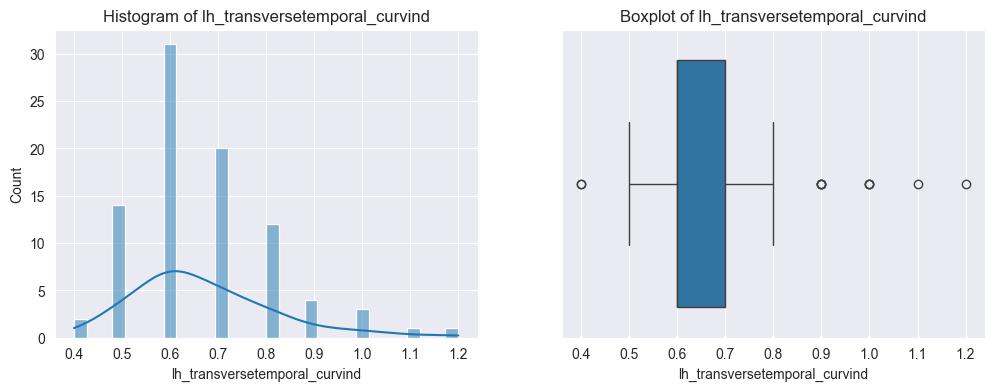

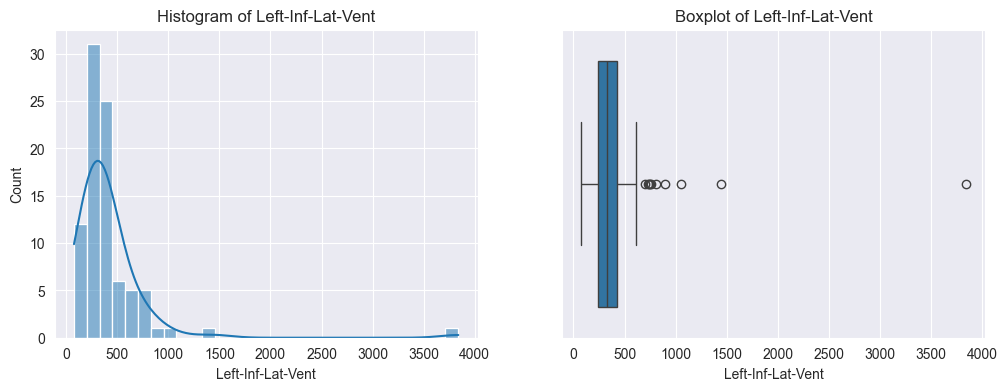

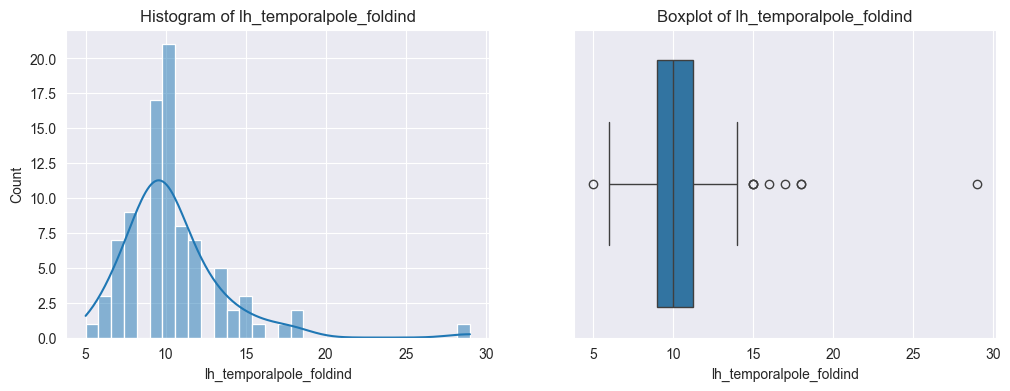

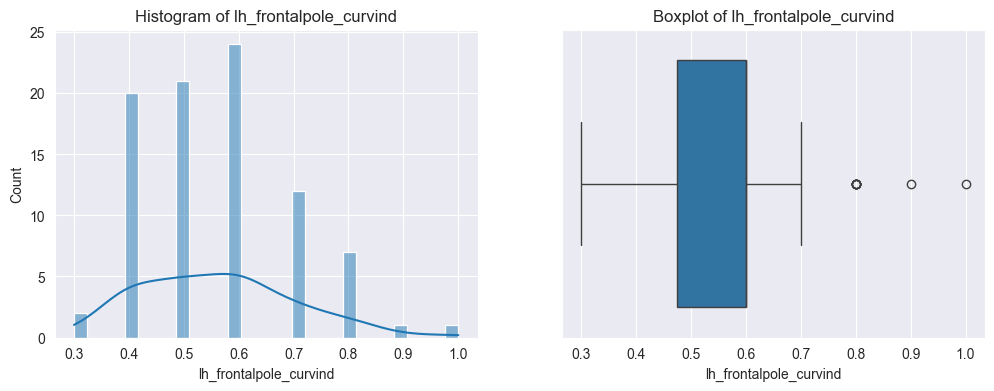

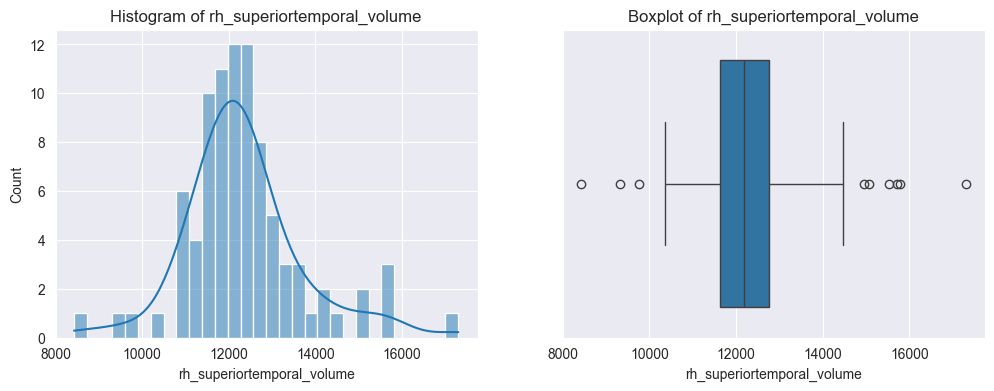

In [8]:
# Select features with the most outliers
outlier_count = {}
for col in numerical_columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_count[col] = ((df[col] < lower) | (df[col] > upper)).sum()

# Sort features by outlier count
sorted_outliers = sorted(outlier_count.items(), key=lambda x: x[1], reverse=True)

# Select the top 5 most affected features
sample_features = [feature for feature, count in sorted_outliers[:5]]

# Now visualize the selected features
import matplotlib.pyplot as plt
import seaborn as sns

for feature in sample_features:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[feature], bins=30, kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram of {feature}")
    
    # Boxplot
    sns.boxplot(x=df[feature], ax=ax[1])
    ax[1].set_title(f"Boxplot of {feature}")
    
    plt.show()


In [9]:
def replace_outliers_per_feature(df, columns):
    df_cleaned = df.copy()
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR  # More strict filtering for extreme values
        upper_bound = Q3 + 3 * IQR

        # Determine skewness to choose mean or median
        skewness = df[column].skew()
        #replacement_value = df[column].median() if skewness > 0.5 else df[column].mean()

        df_cleaned[column] = np.clip(df_cleaned[column], lower_bound, upper_bound)

        #print(f"🛠️ Replaced outliers in {column} using {'Median' if skewness > 0.5 else 'Mean'}")
        print(f"🛠️ Replaced outliers in {column} using clipping")

    return df_cleaned

df_adjusted = replace_outliers_per_feature(df, numerical_columns)
print("✅ Outliers adjusted per feature, keeping subjects intact.")


🛠️ Replaced outliers in lh_bankssts_thickness using clipping
🛠️ Replaced outliers in lh_caudalanteriorcingulate_thickness using clipping
🛠️ Replaced outliers in lh_caudalmiddlefrontal_thickness using clipping
🛠️ Replaced outliers in lh_cuneus_thickness using clipping
🛠️ Replaced outliers in lh_entorhinal_thickness using clipping
🛠️ Replaced outliers in lh_fusiform_thickness using clipping
🛠️ Replaced outliers in lh_inferiorparietal_thickness using clipping
🛠️ Replaced outliers in lh_inferiortemporal_thickness using clipping
🛠️ Replaced outliers in lh_isthmuscingulate_thickness using clipping
🛠️ Replaced outliers in lh_lateraloccipital_thickness using clipping
🛠️ Replaced outliers in lh_lateralorbitofrontal_thickness using clipping
🛠️ Replaced outliers in lh_lingual_thickness using clipping
🛠️ Replaced outliers in lh_medialorbitofrontal_thickness using clipping
🛠️ Replaced outliers in lh_middletemporal_thickness using clipping
🛠️ Replaced outliers in lh_parahippocampal_thickness using c

In [10]:
print(f"Subjects before cleaning: {df.shape[0]}")
print(f"Subjects after cleaning: {df_adjusted.shape[0]}")  # Should be the same


Subjects before cleaning: 88
Subjects after cleaning: 88


In [11]:
df_adjusted.to_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing_out.csv', index=False)

##### 4- ✅ Normalizing Standardization 

----------------

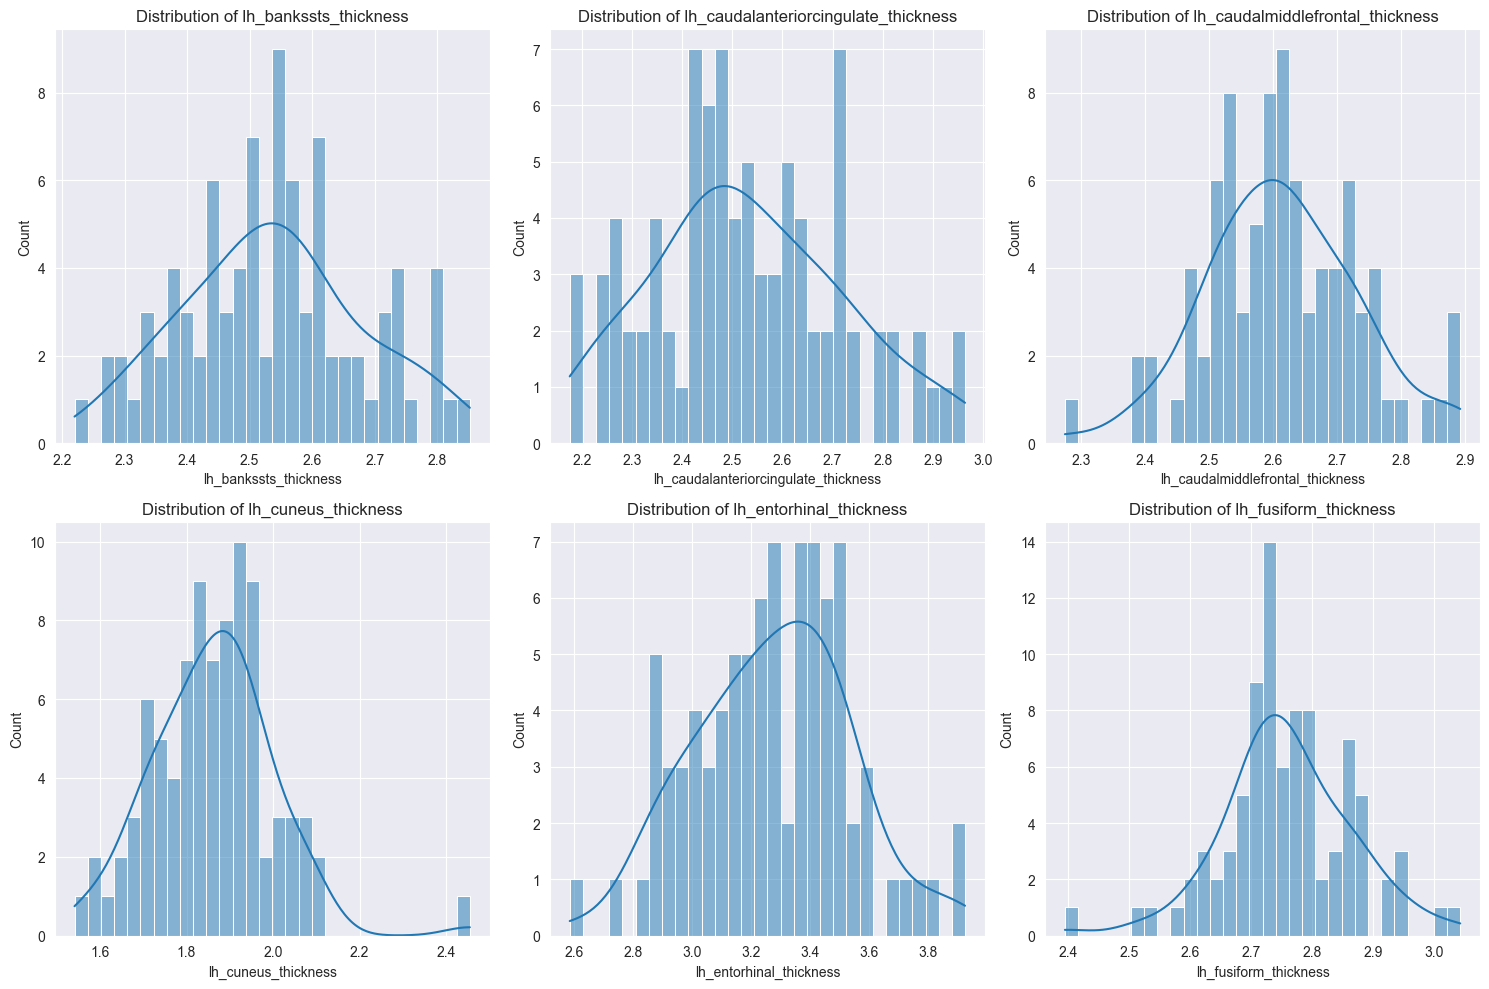

In [12]:

df = pd.read_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing_out.csv')
import seaborn as sns
import matplotlib.pyplot as plt

# Select a few representative numerical features
sample_features = numerical_columns[:6]  # Modify the number as needed

# Determine the number of rows and columns for the grid layout
num_features = len(sample_features)
cols = 3  # Number of columns in the grid
rows = (num_features // cols) + (num_features % cols > 0)  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))  # Adjust figure size

# Flatten axes for easy iteration if it's a multi-row layout
axes = axes.flatten()

# Loop through features and plot in subplots
for i, feature in enumerate(sample_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")

# Remove any empty subplots if features are less than grid slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [13]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform numerical features
df_standardized = df.copy()
# Ensure Label is not included in scaling
numerical_columns = [col for col in numerical_columns if col != "Label"]

# Apply standardization only to numerical features
df_standardized[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print("Features standardized using Z-score scaling.")
print("🔍 Unique values in Label after scaling:", df_standardized["Label"].unique())



Features standardized using Z-score scaling.
🔍 Unique values in Label after scaling: [1 0]


In [14]:
# Print summary statistics to verify the transformation
print("Standardized Data (Mean ~ 0, Std ~ 1):")
print("🔍 Standardized Data Check:")
print("Mean values (should be ~0):")
print(df_standardized[numerical_columns].mean().round(3))

print("Std values (should be ~1):")
print(df_standardized[numerical_columns].std().round(3))


Standardized Data (Mean ~ 0, Std ~ 1):
🔍 Standardized Data Check:
Mean values (should be ~0):
lh_bankssts_thickness                   0.0
lh_caudalanteriorcingulate_thickness    0.0
lh_caudalmiddlefrontal_thickness       -0.0
lh_cuneus_thickness                    -0.0
lh_entorhinal_thickness                 0.0
                                       ... 
BrainSegVol-to-eTIV                     0.0
MaskVol-to-eTIV                         0.0
lhSurfaceHoles                         -0.0
rhSurfaceHoles                         -0.0
SurfaceHoles                            0.0
Length: 540, dtype: float64
Std values (should be ~1):
lh_bankssts_thickness                   1.006
lh_caudalanteriorcingulate_thickness    1.006
lh_caudalmiddlefrontal_thickness        1.006
lh_cuneus_thickness                     1.006
lh_entorhinal_thickness                 1.006
                                        ...  
BrainSegVol-to-eTIV                     1.006
MaskVol-to-eTIV                         1.006

In [15]:
df_standardized.to_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm.csv', index=False)


##### 5- ✅ Feature selection

----------------

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, levene
from statsmodels.stats.multitest import multipletests

# Load dataset
df = pd.read_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm.csv')

# Ensure the label column exists
label_col = "Label"

if label_col not in df.columns:
    raise ValueError(f"⚠️ Column '{label_col}' not found in the dataset!")

# Debug: Print unique values in the Label column
print(f"🔍 Unique values in '{label_col}': {df[label_col].unique()}")

# Drop rows where Label is NaN
df = df.dropna(subset=[label_col])

# Ensure Label is numeric
df[label_col] = pd.to_numeric(df[label_col], errors='coerce')

# Keep only 0 and 1
df = df[df[label_col].isin([0, 1])]

# Debugging output
print(f"✅ After cleaning, dataset contains {df.shape[0]} rows with valid labels.")

# Separate groups
group1 = df[df[label_col] == 0]  # Healthy
group2 = df[df[label_col] == 1]  # Diseased

print(f"✅ Found {len(group1)} Healthy subjects and {len(group2)} Diseased subjects.")

if len(group1) == 0 or len(group2) == 0:
    raise ValueError("⚠️ One or both groups are empty! Please check your data.")

# Save a sample for manual debugging if needed
df.head(20).to_csv(r"D:\image_group_data\team44\Analysis\debug_sample.csv", index=False)
print("📁 Sample saved for debugging. Check 'debug_sample.csv' if needed.")

# Perform T-tests
p_values = []
features_tested = []
skipped_features = 0  # Track number of skipped features

# Get initial numerical feature count
numerical_features = [feature for feature in df.select_dtypes(include=['number']).columns if feature != label_col]
print(f"🔍 Starting with {len(numerical_features)} numerical features for T-test.")

for feature in numerical_features:
    # Skip features with zero variance
    if group1[feature].nunique() == 1 or group2[feature].nunique() == 1:
        print(f"⚠️ Skipping {feature}: Has zero variance in one or both groups.")
        skipped_features += 1
        continue

    # Ensure feature has enough valid data for comparison
    if group1[feature].dropna().shape[0] < 10 or group2[feature].dropna().shape[0] < 10:
        print(f"⚠️ Skipping {feature}: Not enough non-NaN values for T-test.")
        skipped_features += 1
        continue

    # Check variance equality
    stat, p = levene(group1[feature].dropna(), group2[feature].dropna(), center='mean')
    equal_var = p > 0.05  
    #levene() compares the variance of group1[feature] and group2[feature].
    #Removes NaN values using .dropna() (ensuring a valid test).
    #Uses center='mean', which calculates variance based on the mean (other options: 'median' or 'trimmed').
    #📌 What is Levene’s Test Doing?
    #Null Hypothesis (H₀): The two groups have equal variances.
    #Alternative Hypothesis (H₁): The two groups have different variances.

    # Perform T-test
    t_stat, p_val = ttest_ind(
        group1[feature].dropna(), 
        group2[feature].dropna(), 
        equal_var=equal_var, 
        nan_policy='omit'
    )
    #If equal_var=True, it performs a Student’s T-test.
    #If equal_var=False, it performs a Welch’s T-test.
    
    # Append results
    features_tested.append(feature)
    p_values.append(p_val)

# Print the number of skipped and tested features
print(f"✅ {len(features_tested)} features were successfully tested.")
print(f"⚠️ {skipped_features} features were skipped due to missing values or zero variance.")

# Convert to DataFrame
t_test_results = pd.DataFrame({'Feature': features_tested, 'p_value': p_values})

# Remove NaN p-values before multiple testing correction
t_test_results = t_test_results.dropna(subset=['p_value'])

# Apply FDR correction (Benjamini-Hochberg)
if not t_test_results.empty:
    _, corrected_p_values, _, _ = multipletests(t_test_results["p_value"], alpha=0.05, method='fdr_bh')
    t_test_results["corrected_p_value"] = corrected_p_values
else:
    print("⚠️ No valid p-values found for multiple testing correction!")

# Count significant features before and after correction
uncorrected_significant_features = t_test_results[t_test_results['p_value'] < 0.05].shape[0]
corrected_significant_features = t_test_results[t_test_results['corrected_p_value'] < 0.05].shape[0]

print(f"✅ {uncorrected_significant_features} features are significant before FDR correction.")
print(f"✅ {corrected_significant_features} features are significant after FDR correction.")

# Save results
output_file = r"D:\image_group_data\team44\Analysis\t_test_feature_selection.csv"
t_test_results.to_csv(output_file, index=False)
print(f"📁 Results saved at: {output_file}")

# Display first few rows
print(t_test_results.head())


🔍 Unique values in 'Label': [1 0]
✅ After cleaning, dataset contains 88 rows with valid labels.
✅ Found 63 Healthy subjects and 25 Diseased subjects.
📁 Sample saved for debugging. Check 'debug_sample.csv' if needed.
🔍 Starting with 540 numerical features for T-test.
⚠️ Skipping 5th-Ventricle: Has zero variance in one or both groups.
⚠️ Skipping non-WM-hypointensities: Has zero variance in one or both groups.
✅ 538 features were successfully tested.
⚠️ 2 features were skipped due to missing values or zero variance.
✅ 121 features are significant before FDR correction.
✅ 50 features are significant after FDR correction.
📁 Results saved at: D:\image_group_data\team44\Analysis\t_test_feature_selection.csv
                                Feature   p_value  corrected_p_value
0                 lh_bankssts_thickness  0.024130           0.141106
1  lh_caudalanteriorcingulate_thickness  0.810596           0.931571
2      lh_caudalmiddlefrontal_thickness  0.000697           0.015003
3            

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset (make sure it's the final processed dataset)
df = pd.read_csv(r'D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm.csv')

# Load FDR-corrected significant features from T-test results
t_test_results = pd.read_csv(r"D:\image_group_data\team44\Analysis\t_test_feature_selection.csv")

# Select only FDR-corrected significant features
fdr_significant_features = t_test_results[t_test_results['corrected_p_value'] < 0.05]['Feature'].tolist()

if not fdr_significant_features:
    raise ValueError("⚠️ No features passed FDR correction. Consider lowering the threshold or using uncorrected p-values.")

print(f"✅ Using {len(fdr_significant_features)} FDR-corrected significant features for Random Forest.")

# Define feature matrix and target variable
X = df[fdr_significant_features]
y = df["Label"]  # Make sure 'Label' exists

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Compute feature importance
feature_importance = pd.DataFrame({'Feature': fdr_significant_features, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Save feature importance results
feature_importance.to_csv(r"D:\image_group_data\team44\Analysis\random_forest_feature_importance.csv", index=False)

# Select top 10-25 most important features
top_features = feature_importance['Feature'].tolist()[:20]  # Adjust number as needed

print(f"✅ Random Forest completed. {len(top_features)} top features selected.")
print("📁 Results saved to 'random_forest_feature_importance.csv'.")


✅ Using 50 FDR-corrected significant features for Random Forest.
✅ Random Forest completed. 20 top features selected.
📁 Results saved to 'random_forest_feature_importance.csv'.


In [18]:
from sklearn.feature_selection import RFE

# ============================ APPLY RFE ============================ #

# Ensure there are features from Random Forest before RFE
if len(top_features) == 0:
    print("⚠️ No features were selected by Random Forest. Skipping RFE.")
else:
    # Apply Recursive Feature Elimination (RFE) with Random Forest
    selector = RFE(
        estimator=RandomForestClassifier(n_estimators=100, random_state=42),
        n_features_to_select=10  # Select top 10 features
    )

    # Fit RFE on the **train dataset**
    selector.fit(X_train, y_train)

    # Get selected feature names
    final_features = [f for f, s in zip(fdr_significant_features, selector.support_) if s]


    # Save final selected features
    output_path = r"D:\image_group_data\team44\Analysis\final_selected_features.csv"
    pd.DataFrame({'Selected_Features': final_features}).to_csv(output_path, index=False)

    # Print results
    print(f"✅ Final selected features using RFE: {final_features}")
    print(f"📊 Total number of final selected features: {len(final_features)}")
    print(f"📁 Results saved to '{output_path}'.")


✅ Final selected features using RFE: ['lh_parsopercularis_thickness', 'lh_lateralorbitofrontal_volume', 'rh_parsorbitalis_thickness', 'rh_lateralorbitofrontal_volume', 'rh_lateralorbitofrontal_foldind', 'Left-Lateral-Ventricle', 'Left-choroid-plexus', 'Right-Lateral-Ventricle', 'Optic-Chiasm', 'BrainSegVol-to-eTIV']
📊 Total number of final selected features: 10
📁 Results saved to 'D:\image_group_data\team44\Analysis\final_selected_features.csv'.


#### Save the Final Dataset

----------------------

In [19]:
import pandas as pd

# Load full dataset
df = pd.read_csv(r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm.csv")

# Load selected features
selected_features_df = pd.read_csv(r"D:\image_group_data\team44\Analysis\final_selected_features.csv")
selected_features = selected_features_df["Selected_Features"].tolist()

# Ensure we keep the Subject ID and Label for training
columns_to_keep = ["Subject_ID", "Label"] + selected_features  # Add label and subject ID

# Extract only the selected features
df_final = df[columns_to_keep]

# Save the final dataset
final_dataset_path = r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv"
df_final.to_csv(final_dataset_path, index=False)

print(f"✅ Final dataset created and saved with {df_final.shape[1]} features (including Subject_ID & Label).")
print(f"📂 File saved at: {final_dataset_path}")


✅ Final dataset created and saved with 12 features (including Subject_ID & Label).
📂 File saved at: D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv


# Exploratory Data Analysis (EDA)

-----------------------------------------

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import shap

# Load Dataset
df = pd.read_csv(r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv")

# Drop unnecessary columns
df = df.drop(columns=['Subject_ID'], errors='ignore')

# Separate Features and Target
num_features = df.drop(columns=['Label'], errors='ignore').columns
X = df[num_features]
y = df['Label']

# Display basic dataset info
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Label                            88 non-null     int64  
 1   lh_parsopercularis_thickness     88 non-null     float64
 2   lh_lateralorbitofrontal_volume   88 non-null     float64
 3   rh_parsorbitalis_thickness       88 non-null     float64
 4   rh_lateralorbitofrontal_volume   88 non-null     float64
 5   rh_lateralorbitofrontal_foldind  88 non-null     float64
 6   Left-Lateral-Ventricle           88 non-null     float64
 7   Left-choroid-plexus              88 non-null     float64
 8   Right-Lateral-Ventricle          88 non-null     float64
 9   Optic-Chiasm                     88 non-null     float64
 10  BrainSegVol-to-eTIV              88 non-null     float64
dtypes: float64(10), int64(1)
memory usage: 7.7 KB
None

Missing Values:
 La


Class Distribution:
 Label
0    63
1    25
Name: count, dtype: int64


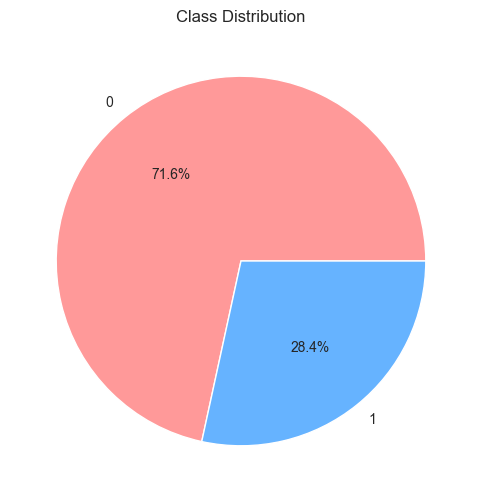

In [21]:
# Step 1: Class Distribution
class_distribution = df['Label'].value_counts()
print("\nClass Distribution:\n", class_distribution)
# 🔹 Class Distribution Visualization
plt.figure(figsize=(6, 6))
class_distribution.plot(kind="pie", autopct='%1.1f%%', colors=["#ff9999", "#66b3ff"])
plt.title("Class Distribution")
plt.ylabel("")  # Hide y-axis label
plt.show()



<span style="color:red">should we remove high correlation? we only have 10 features and the high correlation ones are from different hemesphears (what threshhold?) </span>


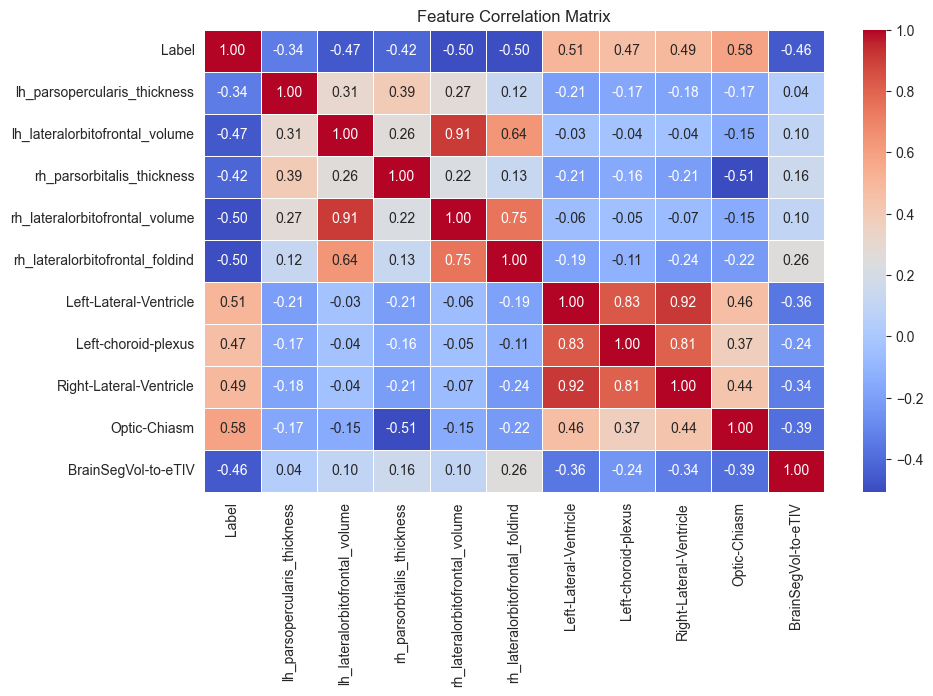

In [22]:
# 🔹 Step 3: Feature Correlation Analysis (Check Multicollinearity)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()


# 📊 Variance Inflation Factor (VIF)

**Variance Inflation Factor (VIF)** is a measure of **multicollinearity** in regression models. It quantifies how much a feature is correlated with other features.

## 📌 Formula for VIF
\[
VIF_i = \frac{1}{1 - R^2_i}
\]
- \( R^2_i \) is the **R-squared value** obtained by regressing feature \( i \) on all other features.
- **Higher VIF** means **higher collinearity**.
- **VIF > 5 or 10** suggests significant multicollinearity.

## ✅ Interpretation of VIF
| **VIF Value** | **Interpretation** |
|--------------|------------------|
| **VIF < 5**  | Low multicollinearity (Safe) |
| **VIF 5 - 10** | Moderate multicollinearity (Investigate) |
| **VIF > 10** | High multicollinearity (Consider removing the feature) |

🚀 **VIF helps identify redundant features that should be removed or transformed!**


In [23]:
#Variance Inflation Factor (VIF) Computation
# Compute VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = num_features
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVIF Scores:\n", vif_data)



VIF Scores:
                            Feature       VIF
0     lh_parsopercularis_thickness  1.321367
1   lh_lateralorbitofrontal_volume  6.162985
2       rh_parsorbitalis_thickness  1.618304
3   rh_lateralorbitofrontal_volume  8.240846
4  rh_lateralorbitofrontal_foldind  2.866063
5           Left-Lateral-Ventricle  7.930013
6              Left-choroid-plexus  3.474369
7          Right-Lateral-Ventricle  7.039605
8                     Optic-Chiasm  1.791115
9              BrainSegVol-to-eTIV  1.306251


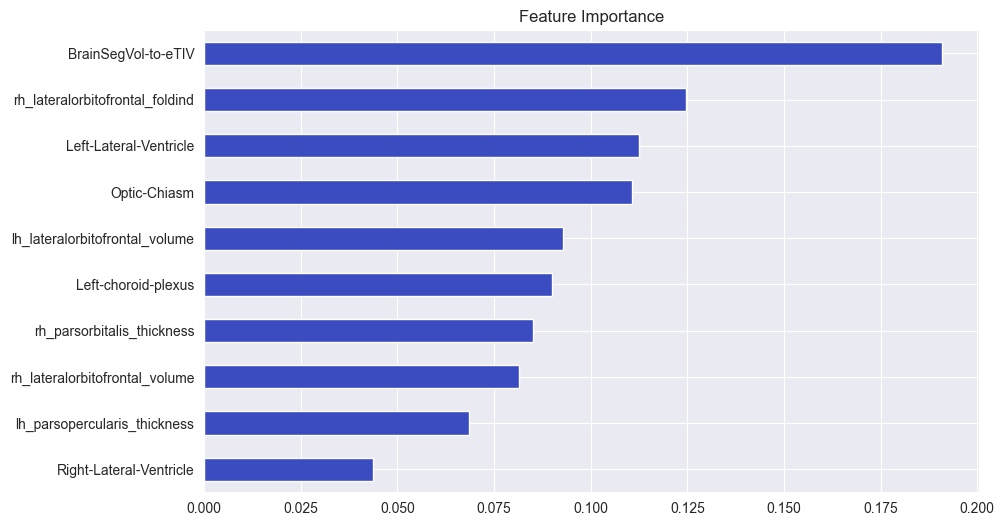

In [24]:
#🔹 Step 5: Feature Importance with Random Forest
# Train a simple Random Forest to rank feature importance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance Plot
importances = pd.Series(rf.feature_importances_, index=num_features)
importances.sort_values().plot(kind="barh", figsize=(10, 6), colormap="coolwarm")
plt.title("Feature Importance")
plt.show()


<span style="color:red">????????????????????????????) </span>


In [25]:
outlier_summary = {}

for feature in num_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
    outlier_summary[feature] = len(outliers)

# 🔹 Outlier Detection - Show Features with Most Outliers
outlier_df_sorted = outlier_df.sort_values(by="Outlier Count", ascending=False)
print("\n🔍 Features with Most Outliers:\n", outlier_df_sorted.head(10))




🔍 Features with Most Outliers:
                            Feature  Outlier Count
182  lh_transversetemporal_curvind             11
366              Left-Inf-Lat-Vent             10
259     rh_superiortemporal_volume              9
180         lh_frontalpole_curvind              9
156        lh_temporalpole_foldind              9
301    rh_parsopercularis_gauscurv              9
340  rh_transversetemporal_foldind              9
376                            CSF              8
299     rh_middletemporal_gauscurv              8
194   rh_parsopercularis_thickness              8


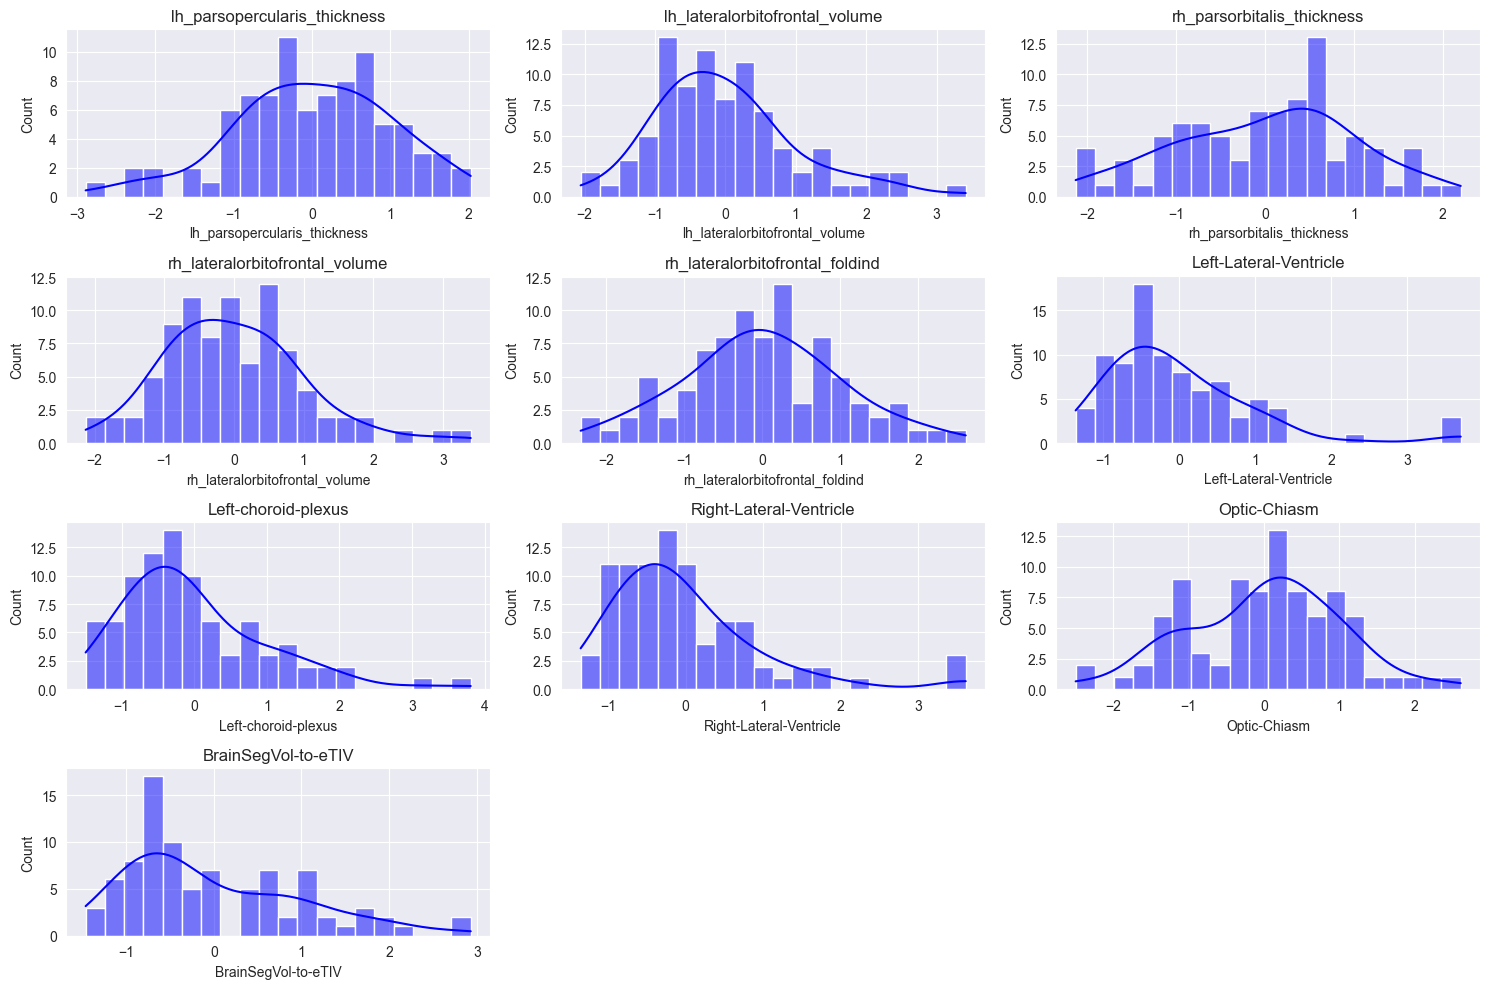

In [26]:
# 🔹 Univariate Analysis (Feature Distributions)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(num_features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[feature], bins=20, kde=True, color="blue")
    plt.title(feature)
plt.tight_layout()
plt.show()


<span style="color:red">before vs after?) </span>


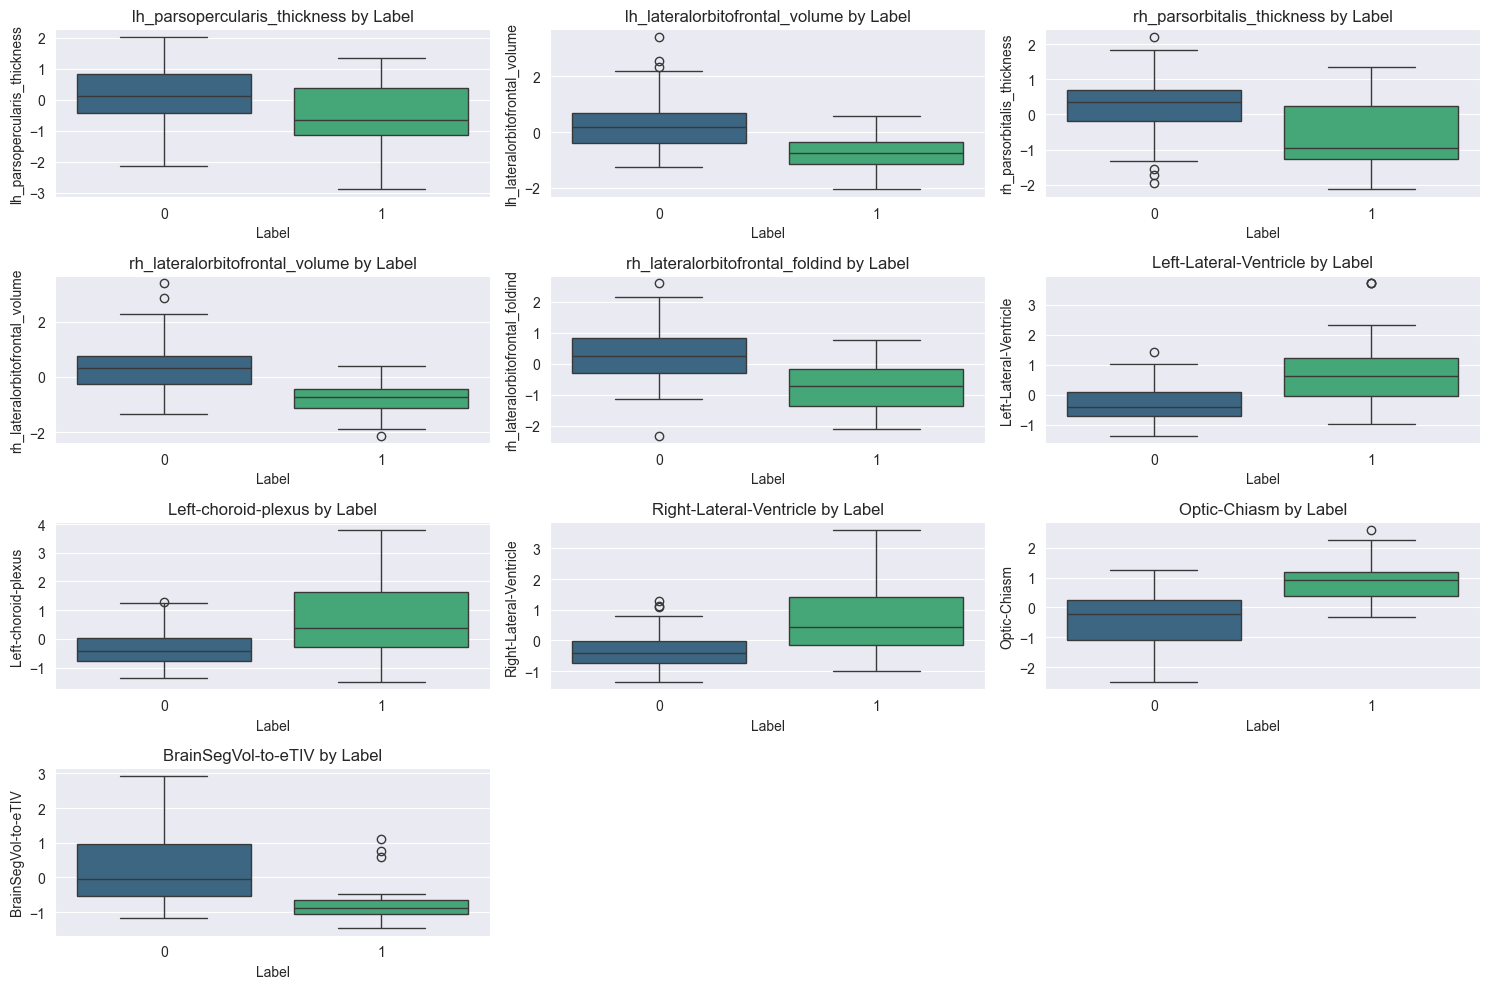

In [27]:
# 🔹 Bivariate Analysis (Boxplots of Features vs Label)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(num_features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x="Label", y=feature, data=df, hue="Label", palette="viridis", legend=False)
    plt.title(f"{feature} by Label")
plt.tight_layout()
plt.show()


# Machine learning

--------------------------------------------------------------

# 1- supervised classification


## ----------------- method 1

In [28]:
########################
# 1. Import Libraries
########################
# Standard Libraries
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, confusion_matrix

# Models from scikit-learn
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    Perceptron, PassiveAggressiveClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, BaggingClassifier, HistGradientBoostingClassifier
)
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# External Libraries Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

# For handling class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [29]:
########################
# 2. Define Custom Metrics
########################
# Custom Metric: Specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp + 1e-9)

specificity_scorer = make_scorer(specificity_score, greater_is_better=True)

def supports_roc_auc(model):
    return hasattr(model, "predict_proba") or hasattr(model, "decision_function")


In [30]:
########################
# 3. Define Models to Test
########################
# Dictionary of models to test
models = {
    # Linear Models
    "CalibratedRidge": RidgeClassifier(),
    "CalibratedPAC": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    "CalibratedSGD": SGDClassifier(max_iter=1000, random_state=42, loss='hinge'),
    "CalibratedPerceptron": Perceptron(max_iter=1000, random_state=42),
    
    # Discriminant Analysis
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    "QDA": QuadraticDiscriminantAnalysis(),
    
    # Naive Bayes
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    
    # Tree-based Models
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME'),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10),
    
    # SVM-based Models
    "SVC": SVC(probability=True),
    "CalibratedLinearSVC": LinearSVC(max_iter=10000),
    "NuSVC": NuSVC(probability=True),
    
    # Neighbors-based Models
    "KNN": KNeighborsClassifier(),
    
    # Gaussian Process
    "GaussianProcessClassifier": GaussianProcessClassifier(random_state=42),
    
    # Neural Networks
    "MLPClassifier": MLPClassifier(max_iter=2000, random_state=42),
    
    # External Models
    "XGBClassifier": XGBClassifier(eval_metric='logloss'),
    "LGBMClassifier": LGBMClassifier(),
    "CatBoostClassifier": CatBoostClassifier(verbose=0)
}

### 📌 Why Are Some Models "Calibrated"?

Some classifiers **do not natively output probabilities**, which are essential for evaluating **ROC-AUC, precision-recall curves, and probability-based decisions**. 

#### ⚡ Models That Need Calibration:
- **SVM (`LinearSVC`)**
- **SGD Classifier (`SGDClassifier`)**
- **Perceptron (`Perceptron`)**
- **Passive Aggressive Classifier (`PAC`)**
- **Ridge Classifier (`RidgeClassifier`)**

These models produce **raw decision scores**, but **not probability estimates**.  
To fix this, we use **`CalibratedClassifierCV`**, which applies **Platt Scaling** or **Isotonic Regression** to **convert scores into calibrated probabilities**.

#### ✅ Models That Don't Need Calibration:
- **Tree-based models (RandomForest, XGBoost, LGBM, etc.)** → Already output well-calibrated probabilities.
- **Naïve Bayes (GaussianNB, BernoulliNB)** → Probabilistic by nature.

🚀 **Calibration ensures that predicted probabilities reflect real-world likelihoods!**


In [31]:
########################
# 4. Define Bayesian Optimization Parameter Spaces
########################
from skopt.space import Real, Integer, Categorical

param_spaces = {
    "LogisticRegression": {
        'classifier__C': Real(1e-4, 100, prior='log-uniform'),
        'classifier__solver': Categorical(['lbfgs', 'liblinear', 'sag', 'saga'])
    },
    "CalibratedRidge": {
        'classifier__alpha': Real(1e-4, 10, prior='log-uniform')
    },
    "CalibratedPAC": {
        'classifier__C': Real(1e-3, 10, prior='log-uniform')
    },
    "CalibratedSGD": {
        'classifier__alpha': Real(1e-6, 1, prior='log-uniform'),
        'classifier__loss': Categorical(['hinge','log','modified_huber','squared_hinge','perceptron'])
    },
    "CalibratedPerceptron": {
        'classifier__alpha': Real(1e-6, 1, prior='log-uniform')
    },
    "CalibratedLinearSVC": {
        'classifier__C': Real(1e-3, 10, prior='log-uniform')
    },

    "LDA": {
        'classifier__shrinkage': Categorical(['auto', 0.1, 0.5, 0.9, None]),
        'classifier__solver': Categorical(['lsqr']),
    },

    "QDA": {
        'classifier__reg_param': Real(0, 1, prior='uniform')
    },
    "GaussianNB": {
        'classifier__var_smoothing': Real(1e-12, 1e-3, prior='log-uniform')
    },
    "BernoulliNB": {
        'classifier__alpha': Real(1e-3, 10, prior='log-uniform')
    },
    "DecisionTree": {
        'classifier__max_depth': Integer(1, 50),
        'classifier__min_samples_split': Integer(2, 20),
        'classifier__min_samples_leaf': Integer(1, 20)
    },
    "RandomForest": {
        'classifier__n_estimators': Integer(50, 300),
        'classifier__max_depth': Integer(2, 50),
        'classifier__min_samples_split': Integer(2, 20)
    },
    "ExtraTrees": {
        'classifier__n_estimators': Integer(50, 300),
        'classifier__max_depth': Integer(2, 50),
        'classifier__min_samples_split': Integer(2, 20)
    },
    "GradientBoosting": {
        'classifier__n_estimators': Integer(50, 300),
        'classifier__learning_rate': Real(1e-3, 0.3, prior='log-uniform'),
        'classifier__max_depth': Integer(1, 10)
    },
    "HistGradientBoosting": {
        'classifier__max_iter': Integer(50, 300),
        'classifier__learning_rate': Real(1e-3, 0.3, prior='log-uniform'),
        'classifier__max_depth': Integer(1, 10)
    },
    "AdaBoost": {
        'classifier__n_estimators': Integer(50, 300),
        'classifier__learning_rate': Real(1e-3, 1, prior='log-uniform')
    },
    "Bagging": {
        'classifier__n_estimators': Integer(10, 200),
        'classifier__max_samples': Real(0.1, 1.0, prior='uniform')
    },
    "SVC": {
        'classifier__C': Real(1e-3, 10, prior='log-uniform'),
        'classifier__gamma': Real(1e-4, 1, prior='log-uniform'),
        'classifier__kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid'])
    },
    "NuSVC": {
        'classifier__nu': Real(0.1, 0.5, prior='uniform'),
        'classifier__gamma': Real(1e-4, 1, prior='log-uniform'),
        'classifier__kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid'])
    },

    "KNN": {
        'classifier__n_neighbors': Integer(1, 50),
        'classifier__leaf_size': Integer(10, 50)
    },
    "GaussianProcessClassifier": {
        'classifier__max_iter_predict': Integer(50, 300)
    },
    "MLPClassifier": {
        'classifier__alpha': Real(1e-6, 1e-1, prior='log-uniform'),
        'classifier__learning_rate_init': Real(1e-4, 0.1, prior='log-uniform'),
        'classifier__hidden_layer_sizes': Integer(50, 300)
    },
    "XGBClassifier": {
        'classifier__n_estimators': Integer(50, 300),
        'classifier__learning_rate': Real(1e-3, 0.3, prior='log-uniform'),
        'classifier__max_depth': Integer(1,10)
    },
    "LGBMClassifier": {
        'classifier__n_estimators': Integer(50, 300),
        'classifier__learning_rate': Real(1e-3, 0.3, prior='log-uniform'),
        'classifier__num_leaves': Integer(10, 100),
        'classifier__max_depth': Integer(-1, 20),
        'classifier__min_child_samples': Integer(1, 20),
        'classifier__min_split_gain': Real(0.0, 1.0, prior='uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, prior='uniform'),
        'classifier__lambda_l1': Real(1e-6, 10.0, prior='log-uniform'),
        'classifier__lambda_l2': Real(1e-6, 10.0, prior='log-uniform')
    },
    "CatBoostClassifier": {
        'classifier__iterations': Integer(50, 300),
        'classifier__learning_rate': Real(1e-3, 0.3, prior='log-uniform'),
        'classifier__depth': Integer(1, 10)
    }
}

In [32]:

########################
# 5. Cross-Validation
########################

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

########################
# 6. Define Scoring Metrics
########################

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'specificity': specificity_scorer,
    'roc_auc': 'roc_auc'
}

########################
# 7. Define Helper Functions
########################
# XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX Not being used
# Custom transformer to remove highly correlated features
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationRemover(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
        self.to_drop_ = None
        
    def fit(self, X, y=None):
        df_corr = pd.DataFrame(X)
        corr_matrix = df_corr.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop_ = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self
    
    def transform(self, X, y=None):
        df = pd.DataFrame(X)
        return df.drop(columns=self.to_drop_, errors='ignore').values


In [33]:
def process_datasets(dataset_paths, use_bayes_opt=True, n_iter=10):
    results = []

    for dataset_path in dataset_paths:
        dataset_name = os.path.splitext(os.path.basename(dataset_path))[0]
        df = pd.read_csv(dataset_path)
        print(dataset_path, df['Label'].value_counts())
        
        # Remove Subject_ID if present
        if 'Subject_ID' in df.columns:
            df = df.drop(columns=['Subject_ID'])

        X = df.drop(columns=['Label'])
        y = df['Label']
        
        # Split the dataset into Train+Validation and Test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        print("Training set label counts:", y_train_val.value_counts())
        
        # Check for imbalance
        class_counts = y_train_val.value_counts()
        majority_class_count = class_counts.max()
        minority_class_count = class_counts.min()
        imbalance_ratio = majority_class_count / minority_class_count
        apply_smote = imbalance_ratio > 1.5  # Arbitrary threshold, adjust as needed
        print("imbalance_ratio:", imbalance_ratio)

        # Base pipeline steps (for non-LDA, non-NB models)
        base_steps = []
        if apply_smote:
            base_steps.append(('smote', SMOTE(random_state=42)))

        # Loop through models
        for model_name, model in models.items():
            # Build pipeline steps (common to all models)
            pipeline_steps = base_steps + [('classifier', model)]
    
            # 3) Build pipeline
            pipeline = ImbPipeline(steps=pipeline_steps)
    
            # 4) If Bayesian optimization
            if use_bayes_opt and model_name in param_spaces:
                bayes_search = BayesSearchCV(
                    estimator=pipeline,
                    search_spaces=param_spaces[model_name],
                    scoring='accuracy',  # or "f1", "accuracy", ...
                    n_iter=n_iter,
                    cv=cv,
                    n_jobs=-1,
                    random_state=42,
                    verbose=0
                )
                bayes_search.fit(X_train_val, y_train_val)
                best_pipeline = bayes_search.best_estimator_
                
                # Evaluate via cross_validate
                cv_results = cross_validate(
                    best_pipeline, 
                    X_train_val, 
                    y_train_val,
                    cv=cv, 
                    scoring=scoring,
                    n_jobs=-1
                )
                # Final fit
                best_pipeline.fit(X_train_val, y_train_val)
                test_accuracy = best_pipeline.score(X_test, y_test)
        
            else:
                # No bayes opt
                cv_results = cross_validate(
                    pipeline, 
                    X_train_val, 
                    y_train_val,
                    cv=cv, 
                    scoring=scoring,
                    n_jobs=-1
                )
                pipeline.fit(X_train_val, y_train_val)
                test_accuracy = pipeline.score(X_test, y_test)
        
            # Extract metrics
            mean_accuracy = np.mean(cv_results['test_accuracy'])
            mean_f1 = np.mean(cv_results['test_f1'])
            mean_precision = np.mean(cv_results['test_precision'])
            mean_recall = np.mean(cv_results['test_recall'])
            mean_specificity = np.mean(cv_results['test_specificity'])
    
            # AUC-ROC (if it exists in the dict)
            mean_auc_roc = None
            if 'test_roc_auc' in cv_results:
                mean_auc_roc = np.mean(cv_results['test_roc_auc'])
            
            # Append results
            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Imbalance_Ratio': imbalance_ratio,
                'SMOTE_Used': apply_smote,
                'CV_Accuracy': mean_accuracy,
                'Test_Accuracy': test_accuracy,
                'F1': mean_f1,
                'Precision': mean_precision,
                'Recall': mean_recall,
                'Specificity': mean_specificity,
                'AUC-ROC': mean_auc_roc
            })
    
    results_df = pd.DataFrame(results)
    return results_df


In [34]:
########################
# 9. Example Dataset Processing
########################
# Example usage for processing datasets
if __name__ == "__main__":
    dataset_paths = [
        r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv"
    ]
    
    results_df = process_datasets(dataset_paths, use_bayes_opt=True, n_iter=10)
    results_df.to_csv(r"D:\image_group_data\team44\Analysis\ML_results.csv", index=False)
    print(results_df)


D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv Label
0    63
1    25
Name: count, dtype: int64
Training set label counts: Label
0    50
1    20
Name: count, dtype: int64
imbalance_ratio: 2.5
[LightGBM] [Warning] lambda_l1 is set=1.5247791391944723, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.5247791391944723
[LightGBM] [Warning] lambda_l2 is set=0.00013300585802877296, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00013300585802877296
[LightGBM] [Warning] lambda_l1 is set=1.5247791391944723, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.5247791391944723
[LightGBM] [Warning] lambda_l2 is set=0.00013300585802877296, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.00013300585802877296
[LightGBM] [Info] Number of positive: 50, number of negative: 50
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000047 seconds.
You can set `force_row_wise=true` to remove the overhead


🔍 Processing CalibratedRidge...
❌ Error computing SHAP values for CalibratedRidge: name 'shap_importance' is not defined
✅ Using `CalibratedRidge` feature importance instead.


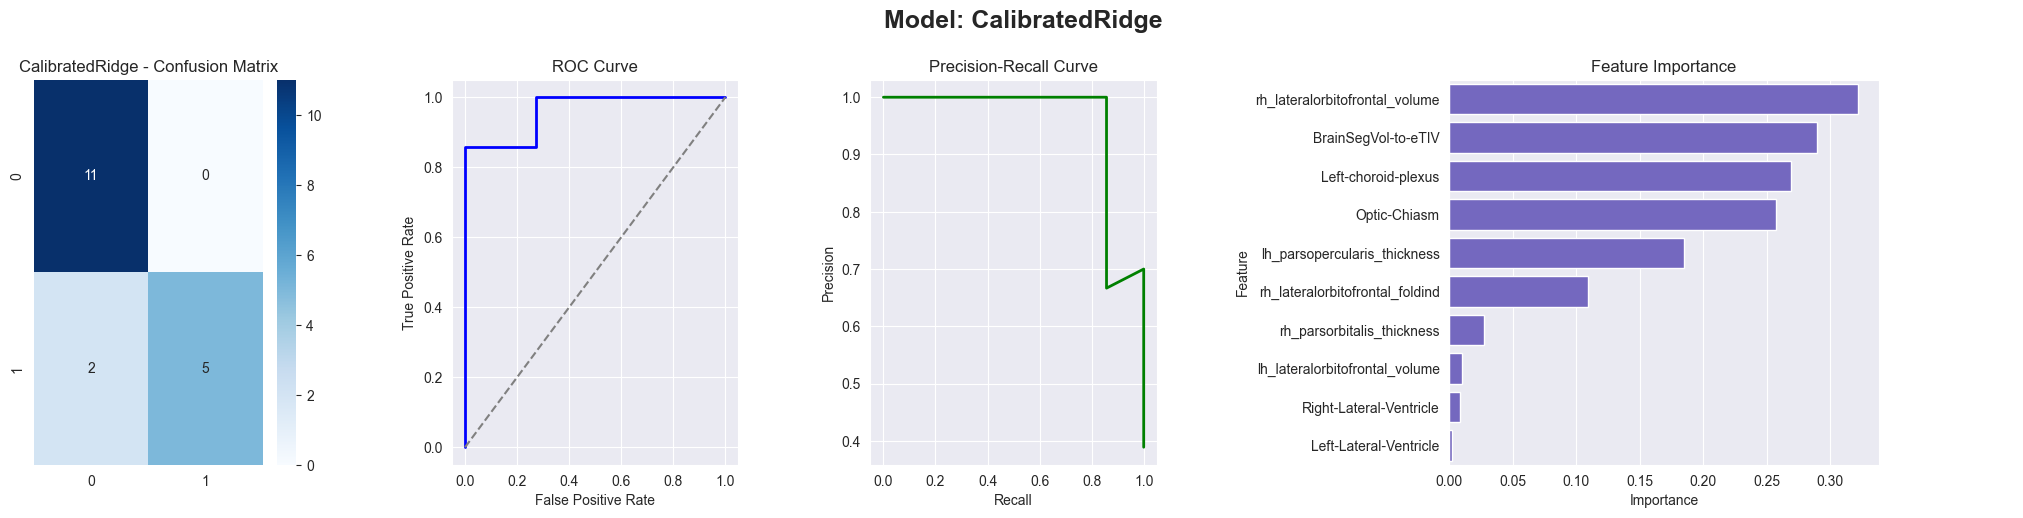


🔍 Processing CalibratedPAC...
❌ Error computing SHAP values for CalibratedPAC: name 'shap_importance' is not defined
✅ Using `CalibratedPAC` feature importance instead.


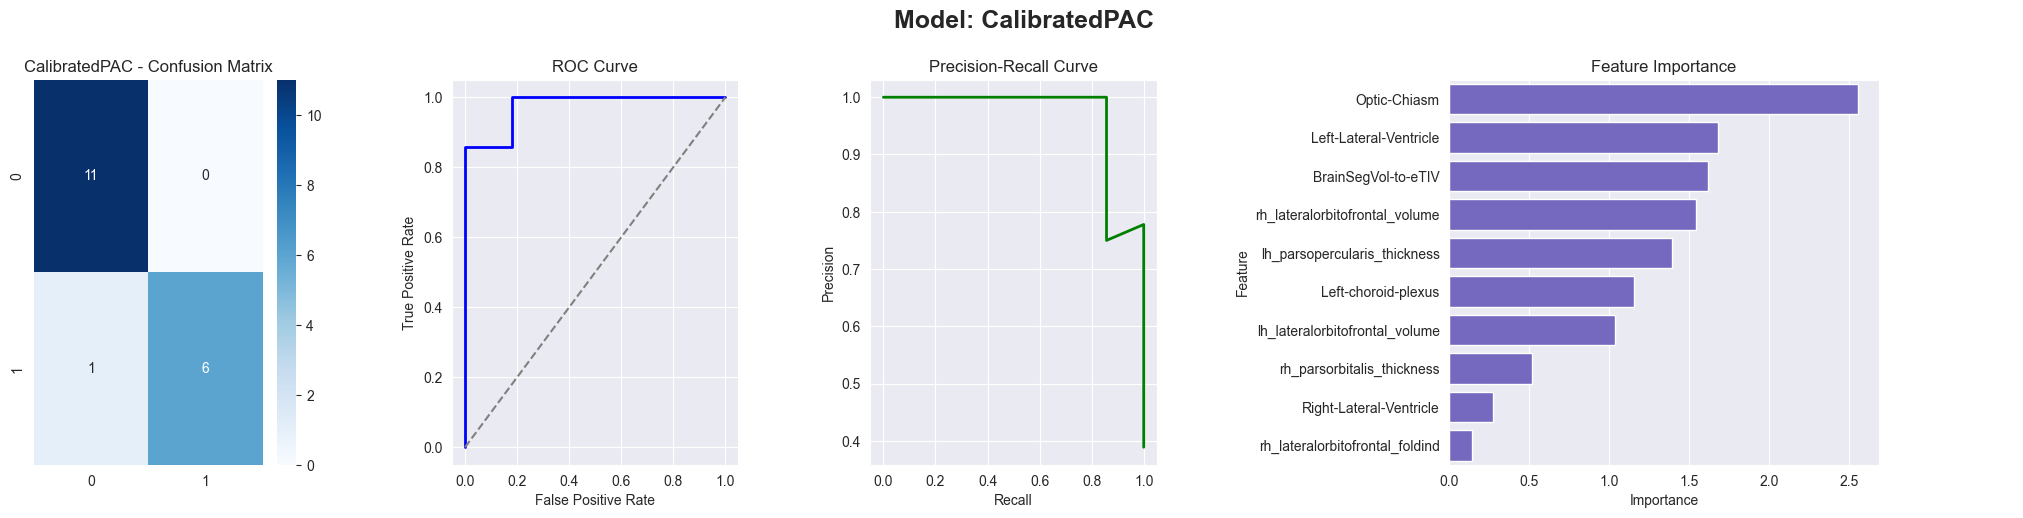


🔍 Processing CalibratedSGD...
❌ Error computing SHAP values for CalibratedSGD: name 'shap_importance' is not defined
✅ Using `CalibratedSGD` feature importance instead.


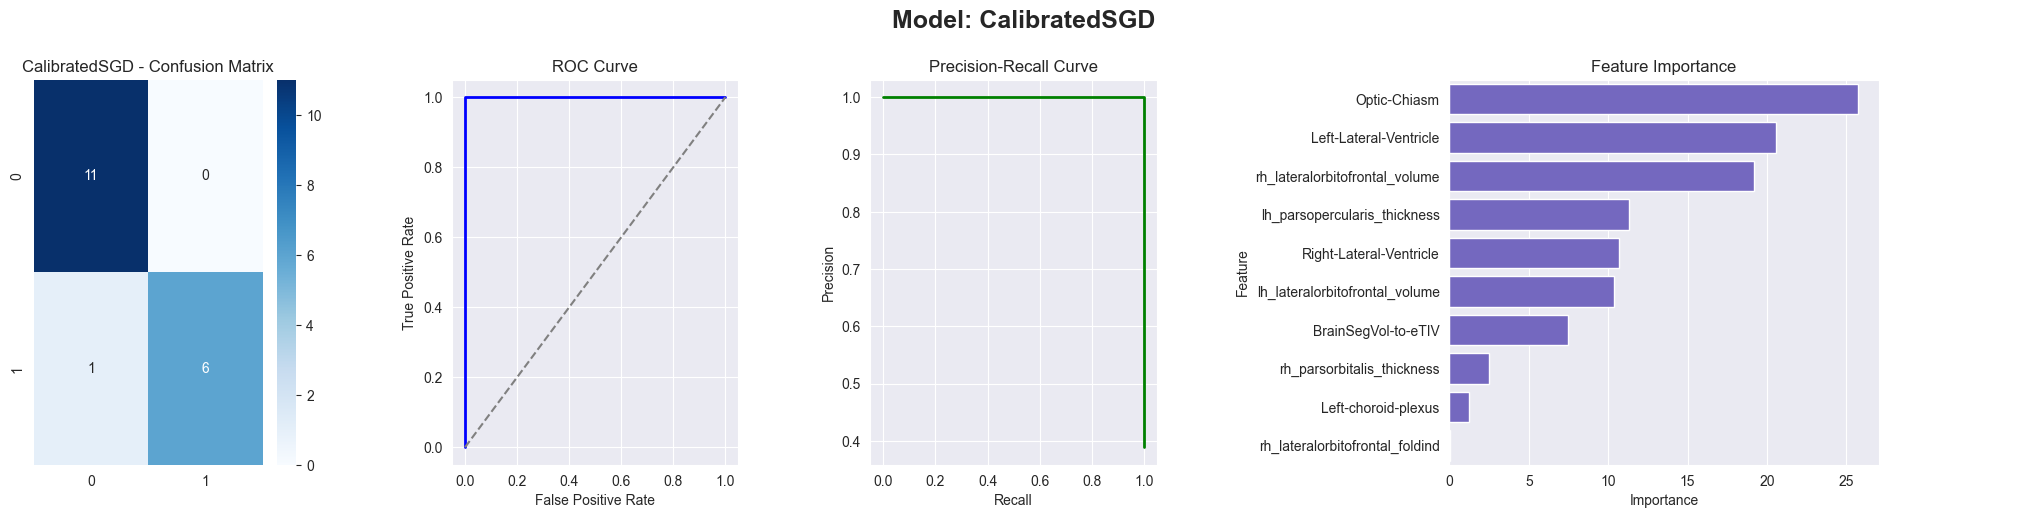


🔍 Processing CalibratedPerceptron...
❌ Error computing SHAP values for CalibratedPerceptron: name 'shap_importance' is not defined
✅ Using `CalibratedPerceptron` feature importance instead.


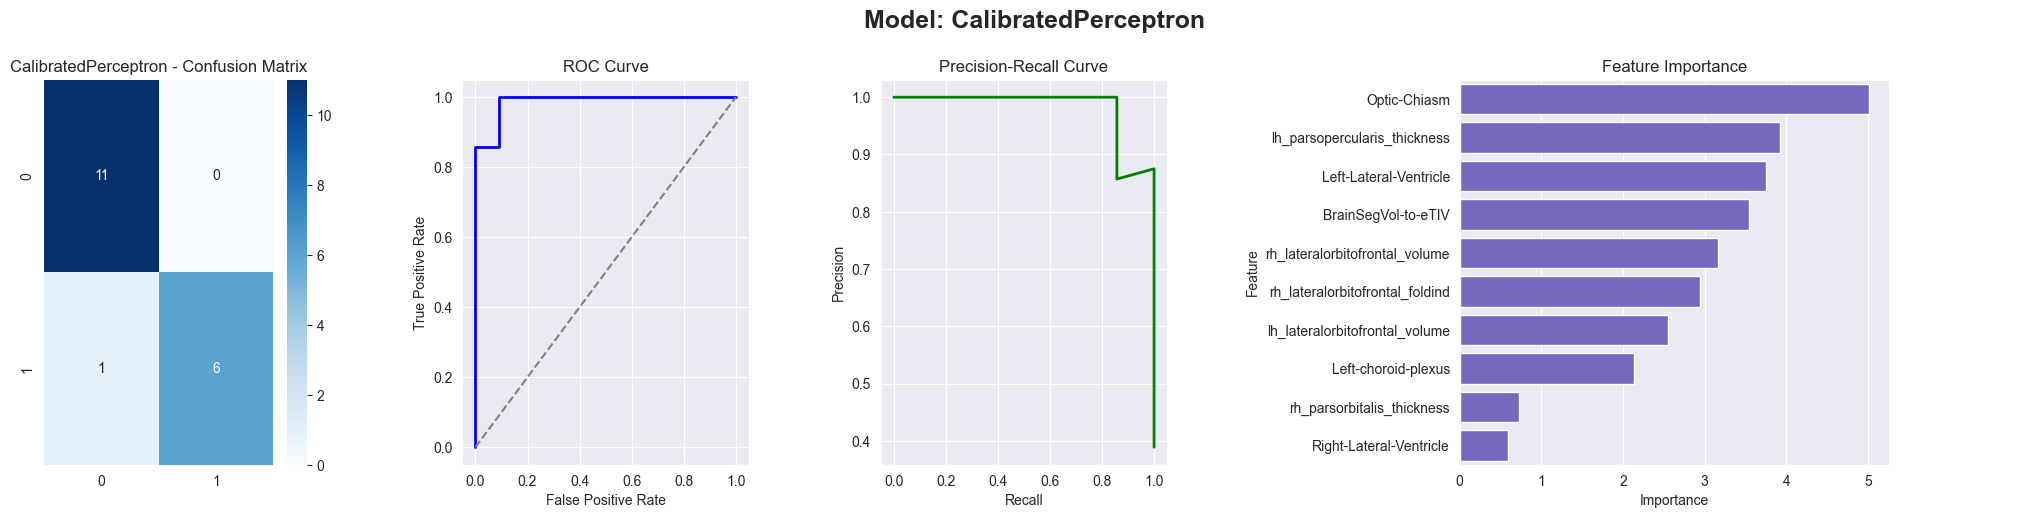


🔍 Processing LDA...
❌ Error computing SHAP values for LDA: name 'shap_importance' is not defined
✅ Using `LDA` feature importance instead.


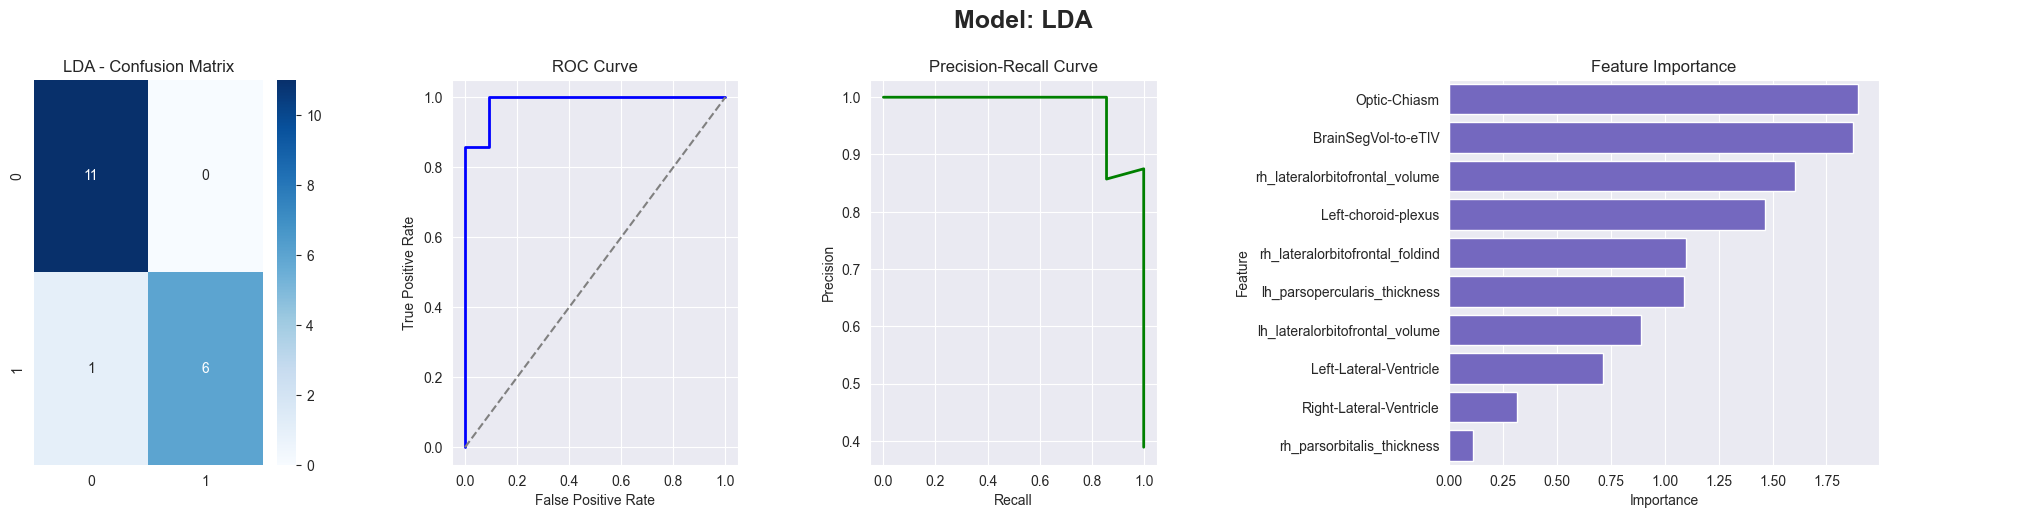


🔍 Processing QDA...
❌ Error computing SHAP values for QDA: name 'shap_importance' is not defined
⚠️ No feature importance available for QDA. Skipping feature importance plot.
⚠️ No feature importance data available for QDA. Skipping plotting.

🔍 Processing GaussianNB...
❌ Error computing SHAP values for GaussianNB: name 'shap_importance' is not defined
⚠️ No feature importance available for GaussianNB. Skipping feature importance plot.
⚠️ No feature importance data available for GaussianNB. Skipping plotting.

🔍 Processing BernoulliNB...
❌ Error computing SHAP values for BernoulliNB: name 'shap_importance' is not defined
⚠️ No feature importance available for BernoulliNB. Skipping feature importance plot.
⚠️ No feature importance data available for BernoulliNB. Skipping plotting.

🔍 Processing DecisionTree...
❌ Error computing SHAP values for DecisionTree: name 'shap_importance' is not defined
✅ Using `DecisionTree` feature importance instead.


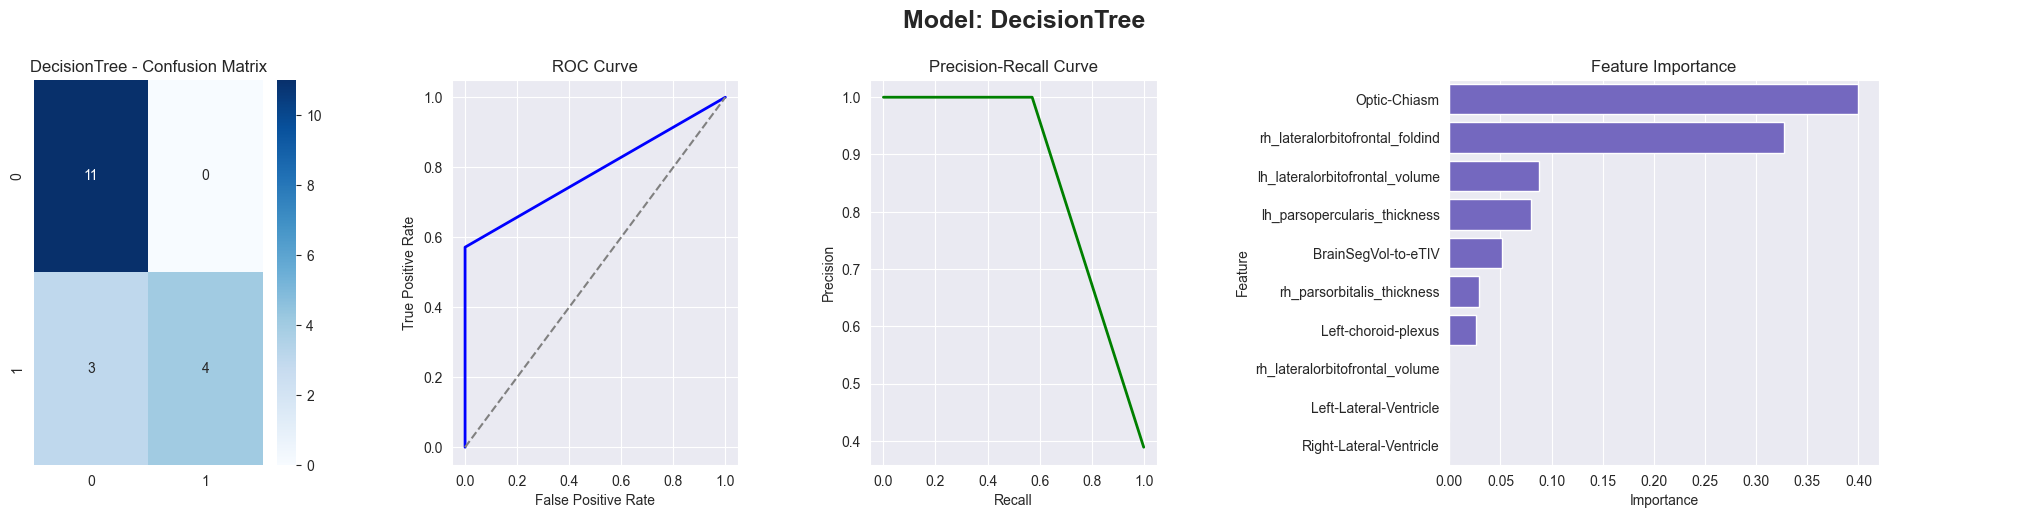


🔍 Processing RandomForest...
❌ Error computing SHAP values for RandomForest: Per-column arrays must each be 1-dimensional
✅ Using `RandomForest` feature importance instead.


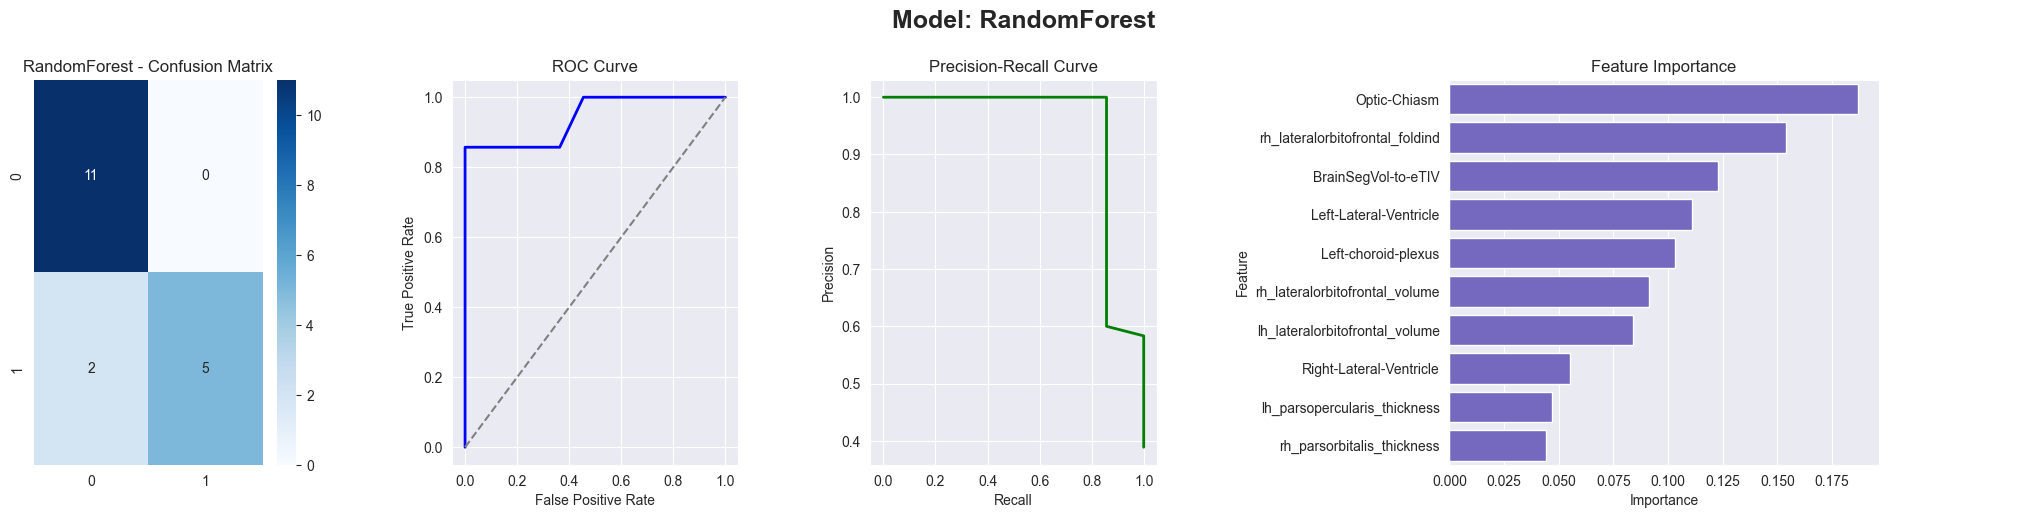


🔍 Processing ExtraTrees...
❌ Error computing SHAP values for ExtraTrees: Per-column arrays must each be 1-dimensional
✅ Using `ExtraTrees` feature importance instead.


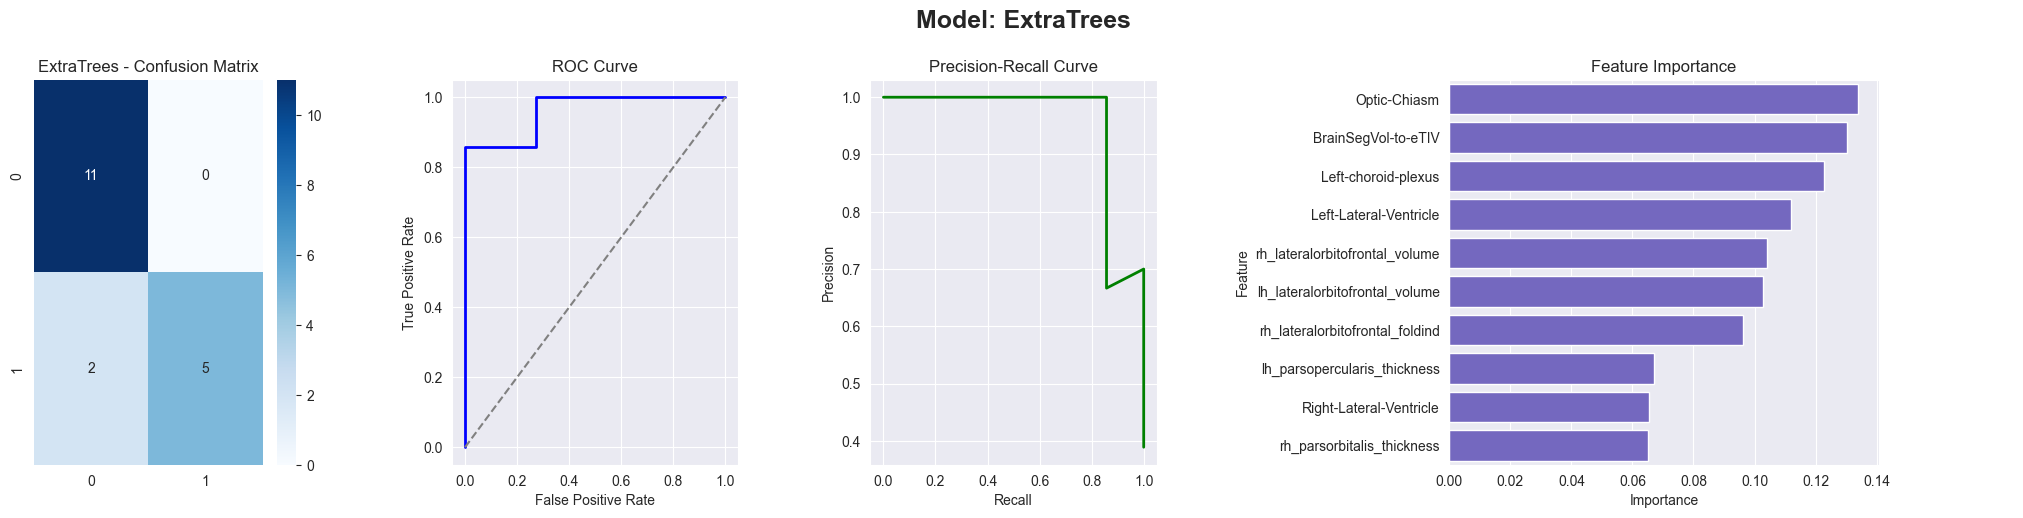


🔍 Processing GradientBoosting...


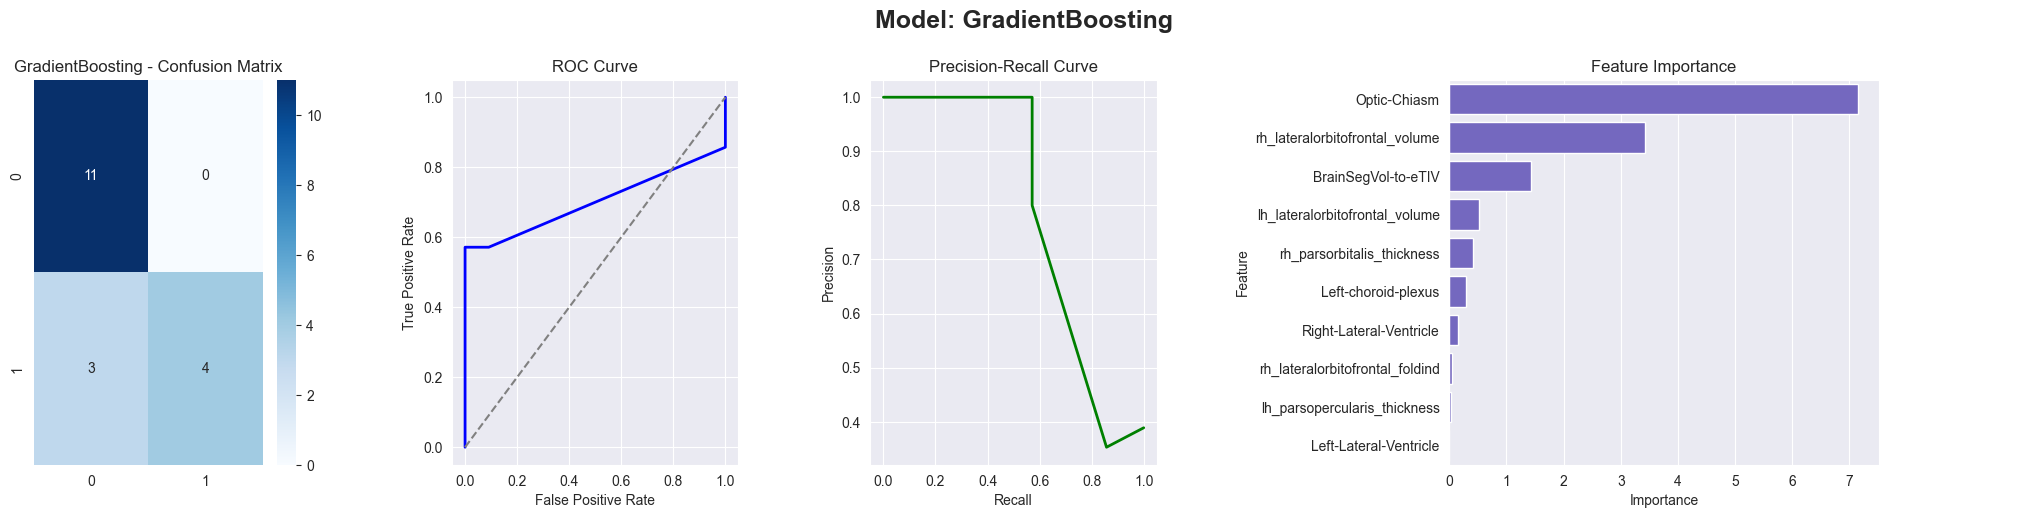


🔍 Processing HistGradientBoosting...


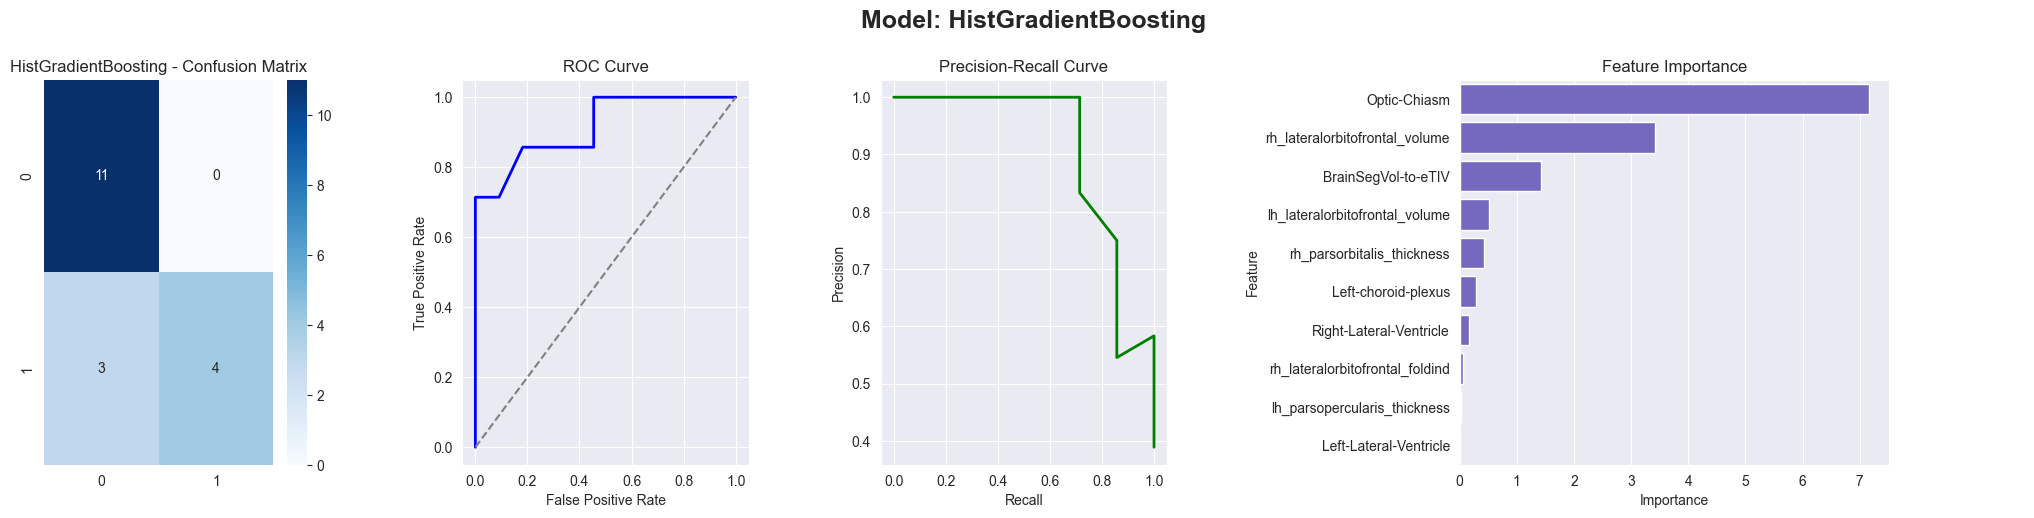


🔍 Processing AdaBoost...


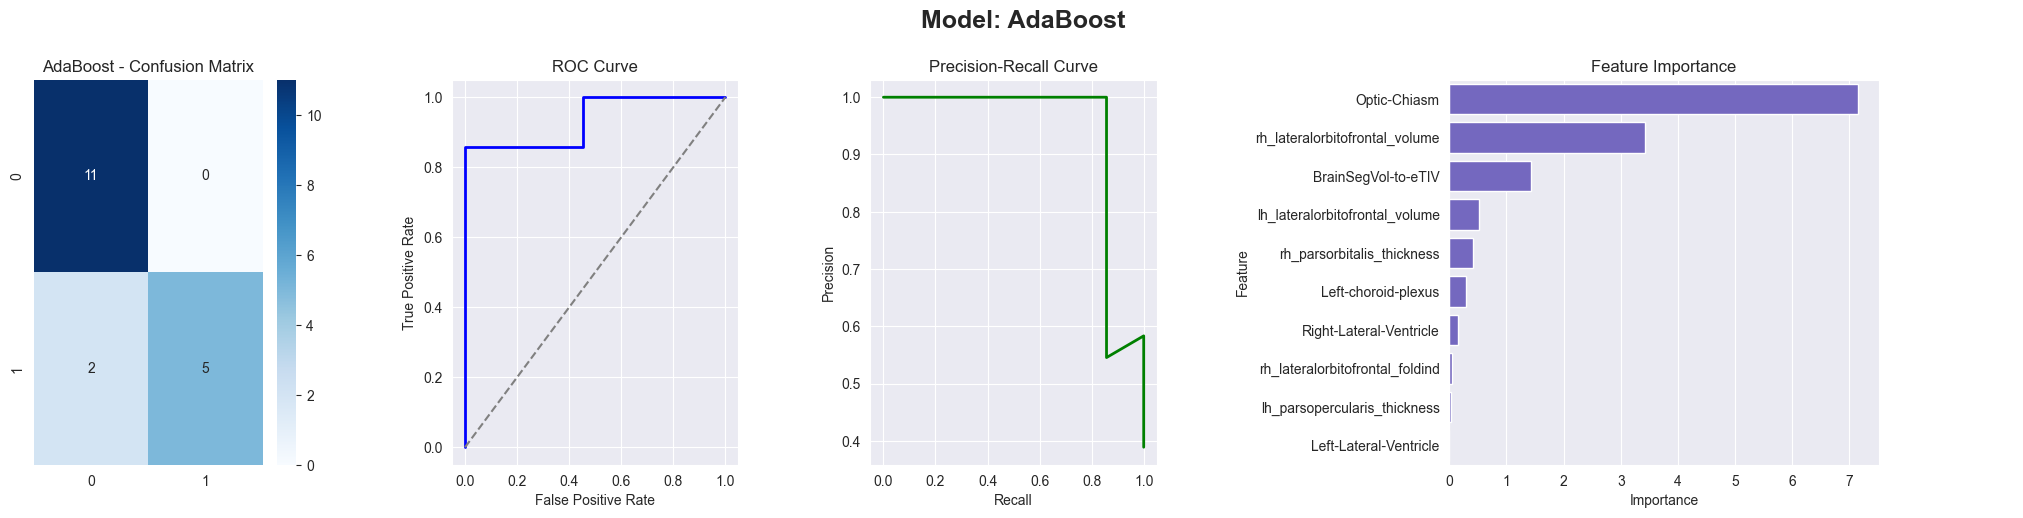


🔍 Processing Bagging...


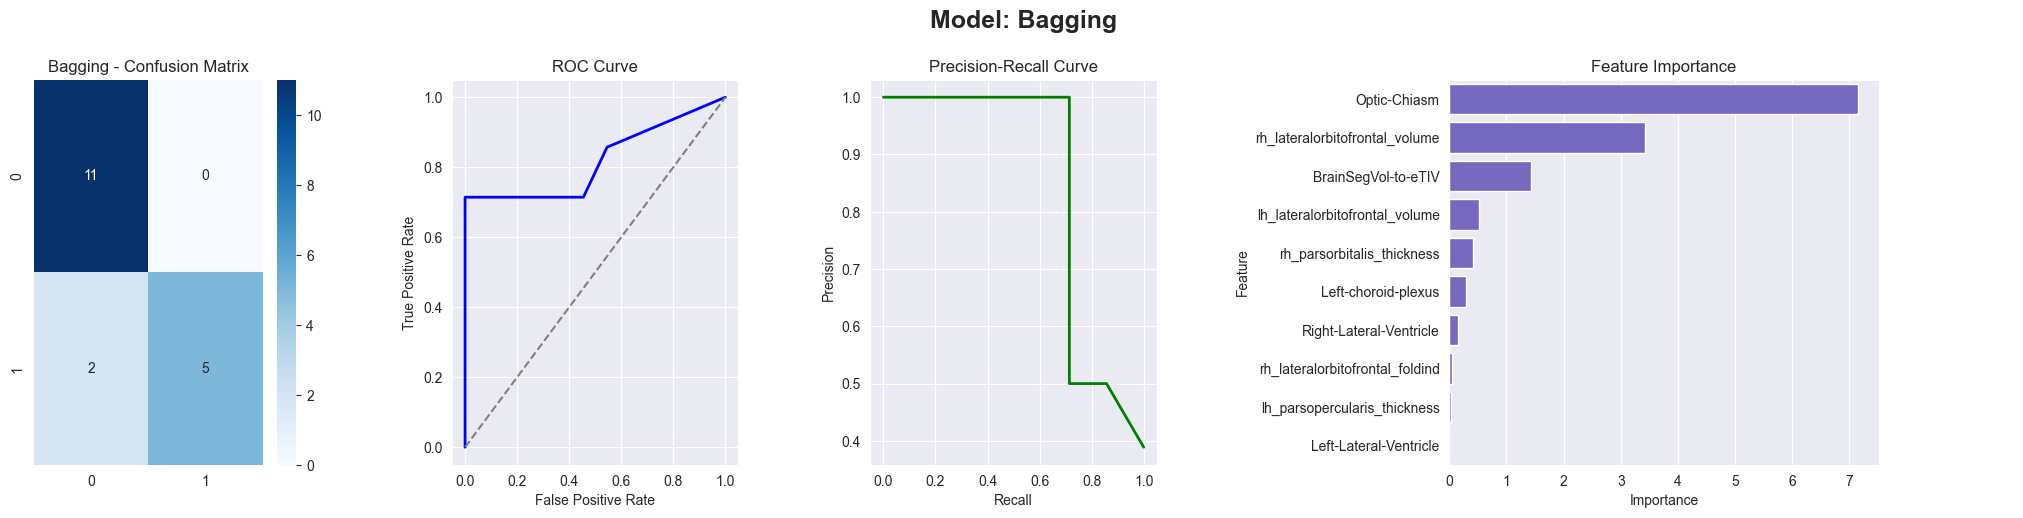


🔍 Processing SVC...


  0%|          | 0/18 [00:00<?, ?it/s]

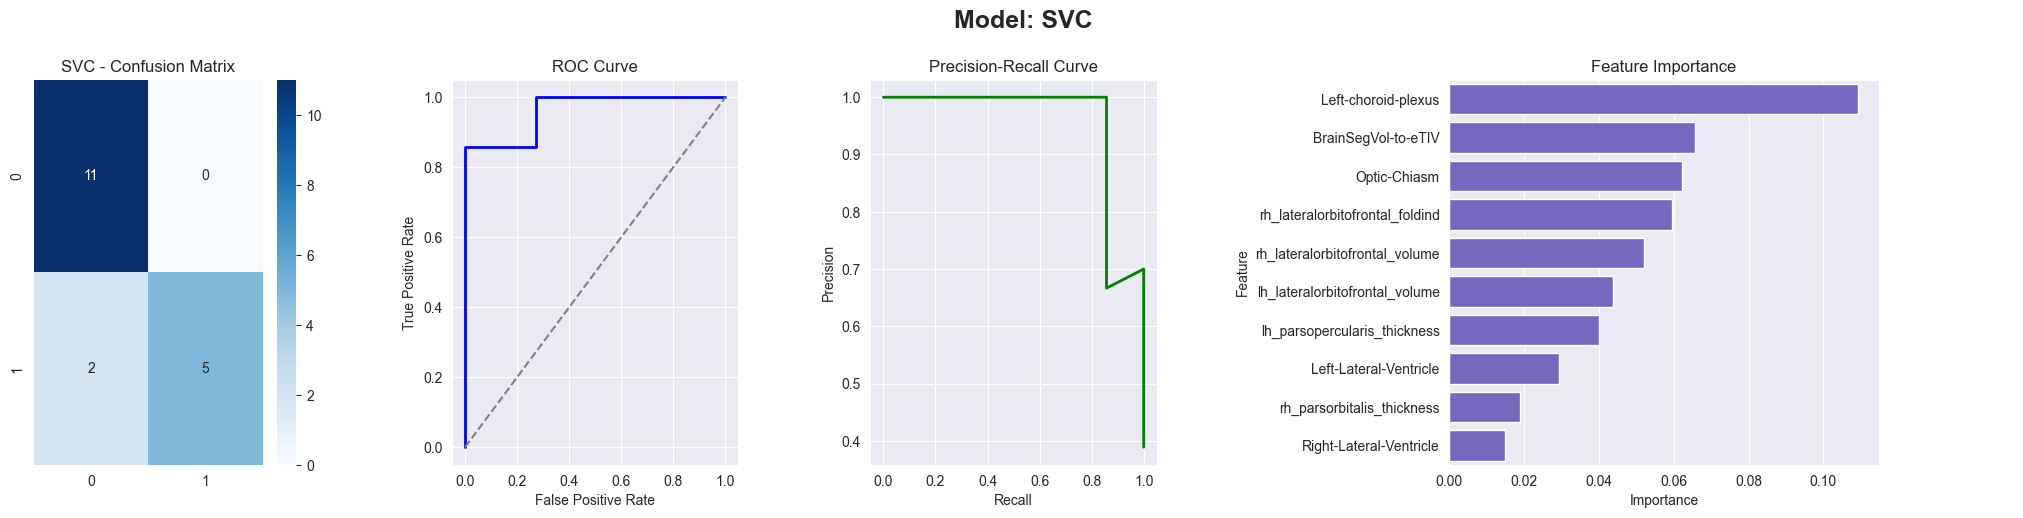


🔍 Processing CalibratedLinearSVC...


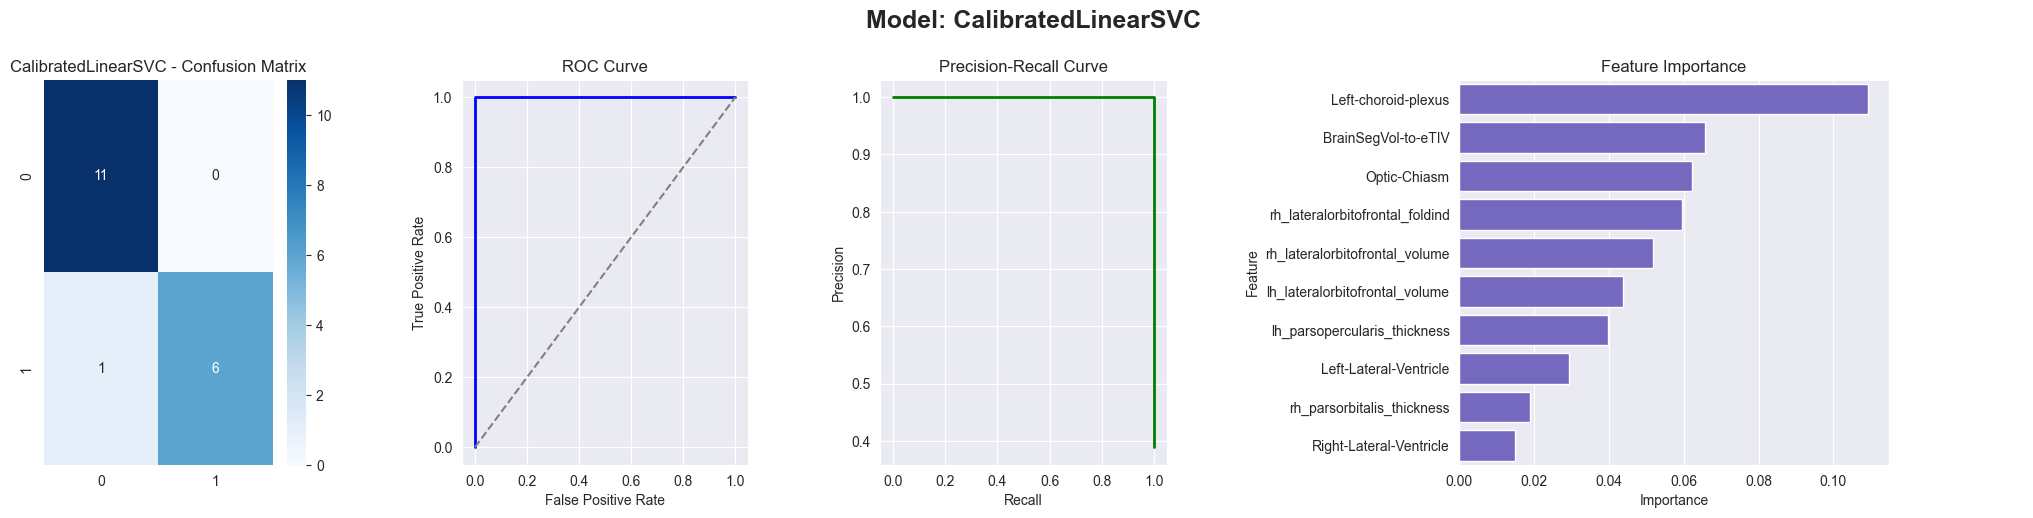


🔍 Processing NuSVC...


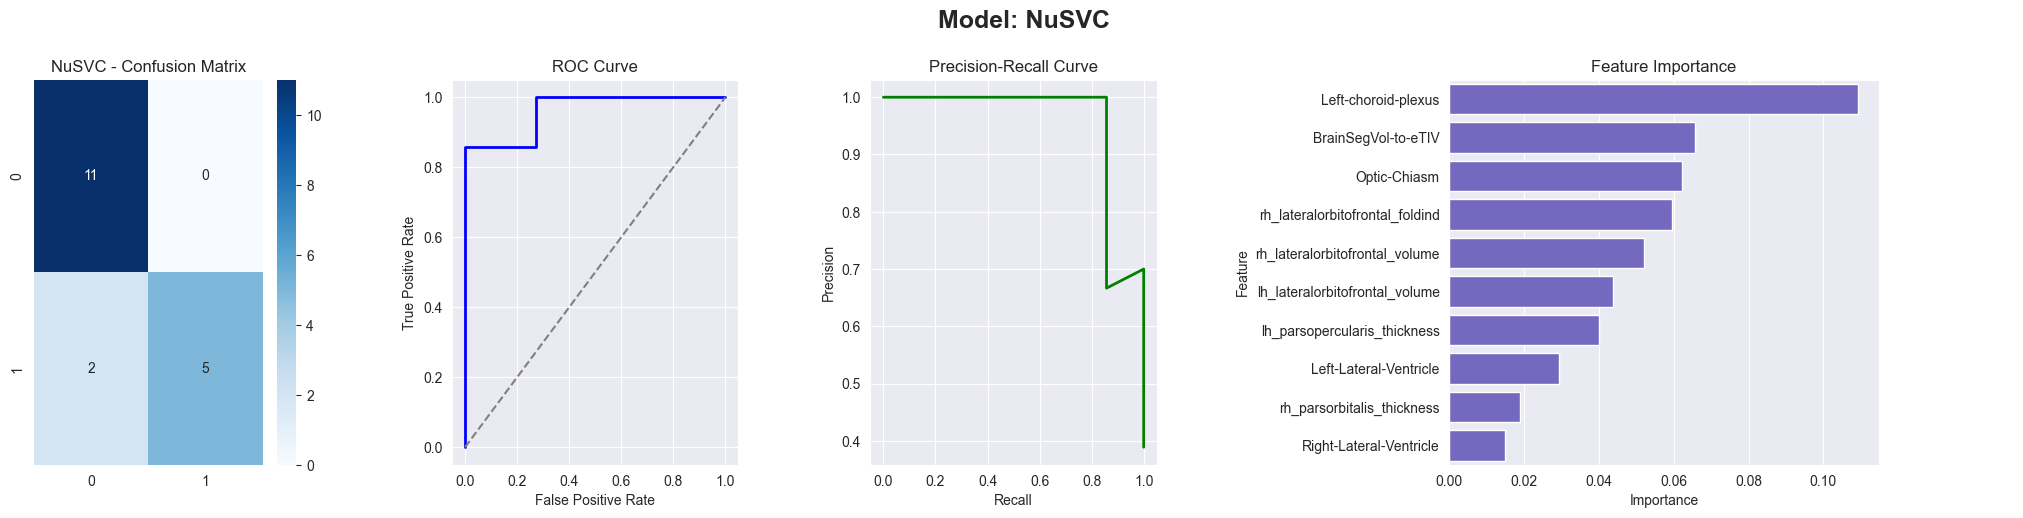


🔍 Processing KNN...


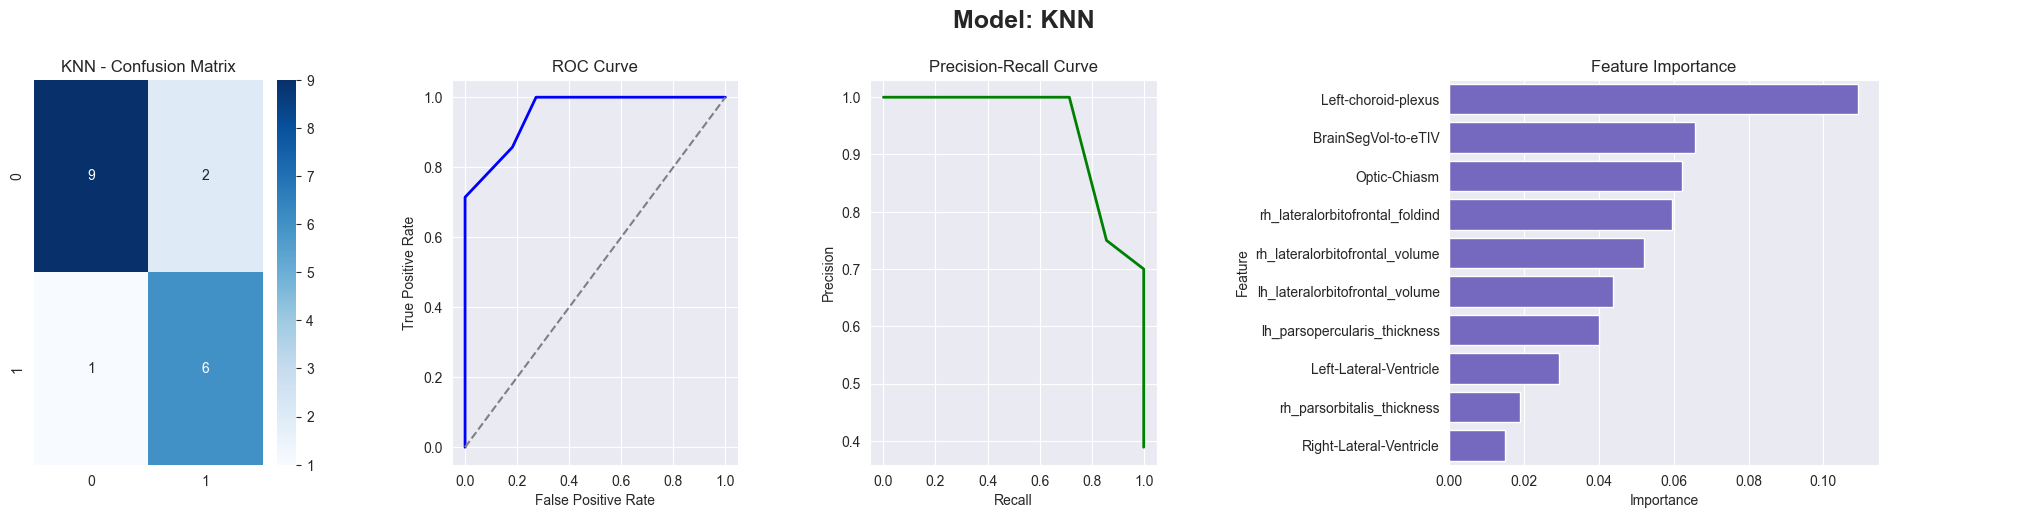


🔍 Processing GaussianProcessClassifier...


  0%|          | 0/18 [00:00<?, ?it/s]

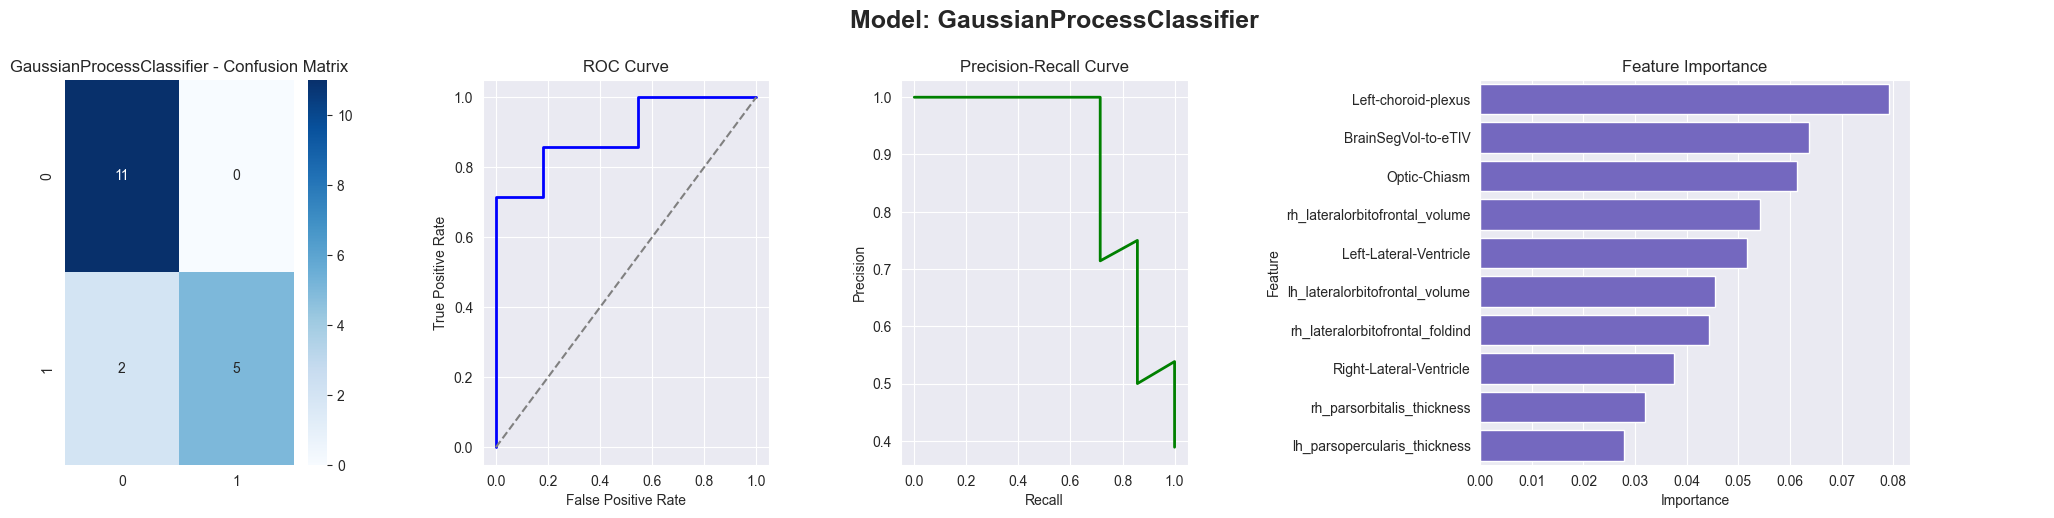


🔍 Processing MLPClassifier...


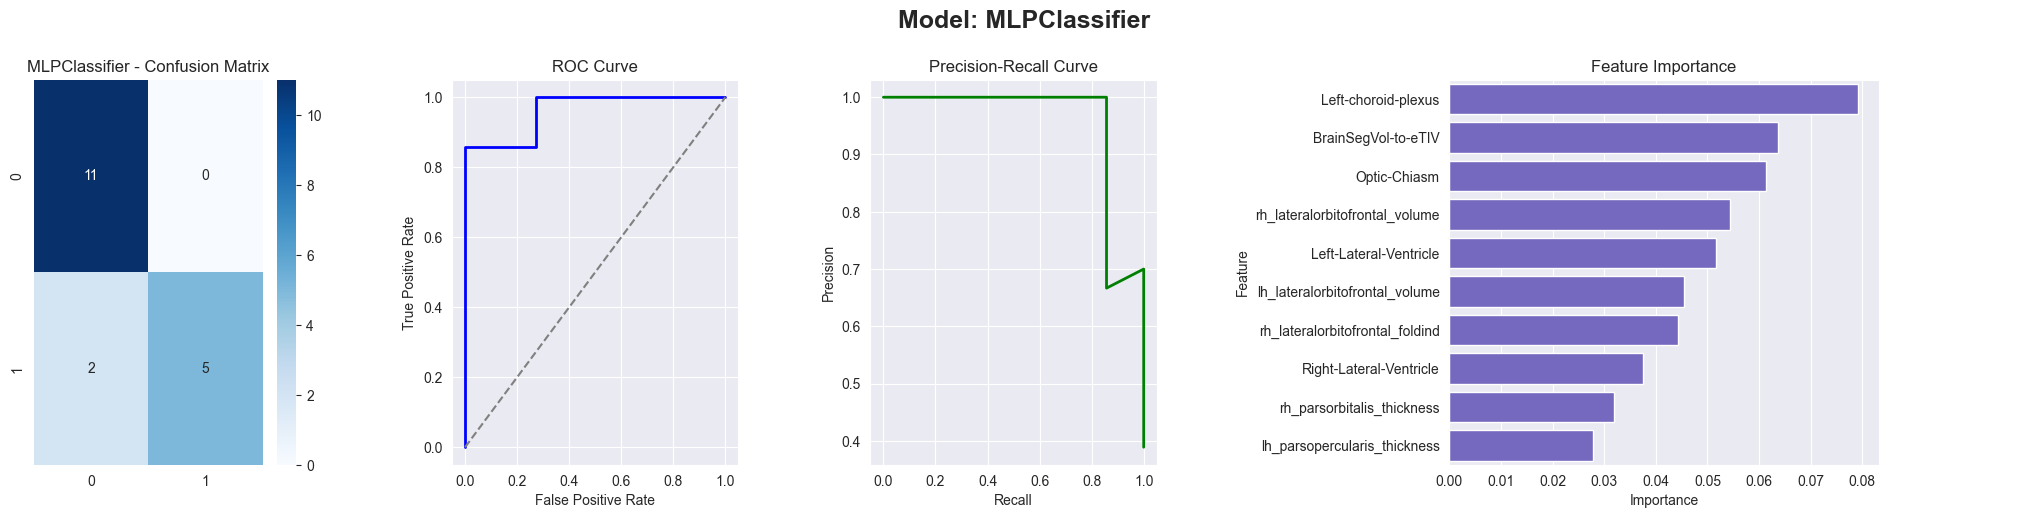


🔍 Processing XGBClassifier...


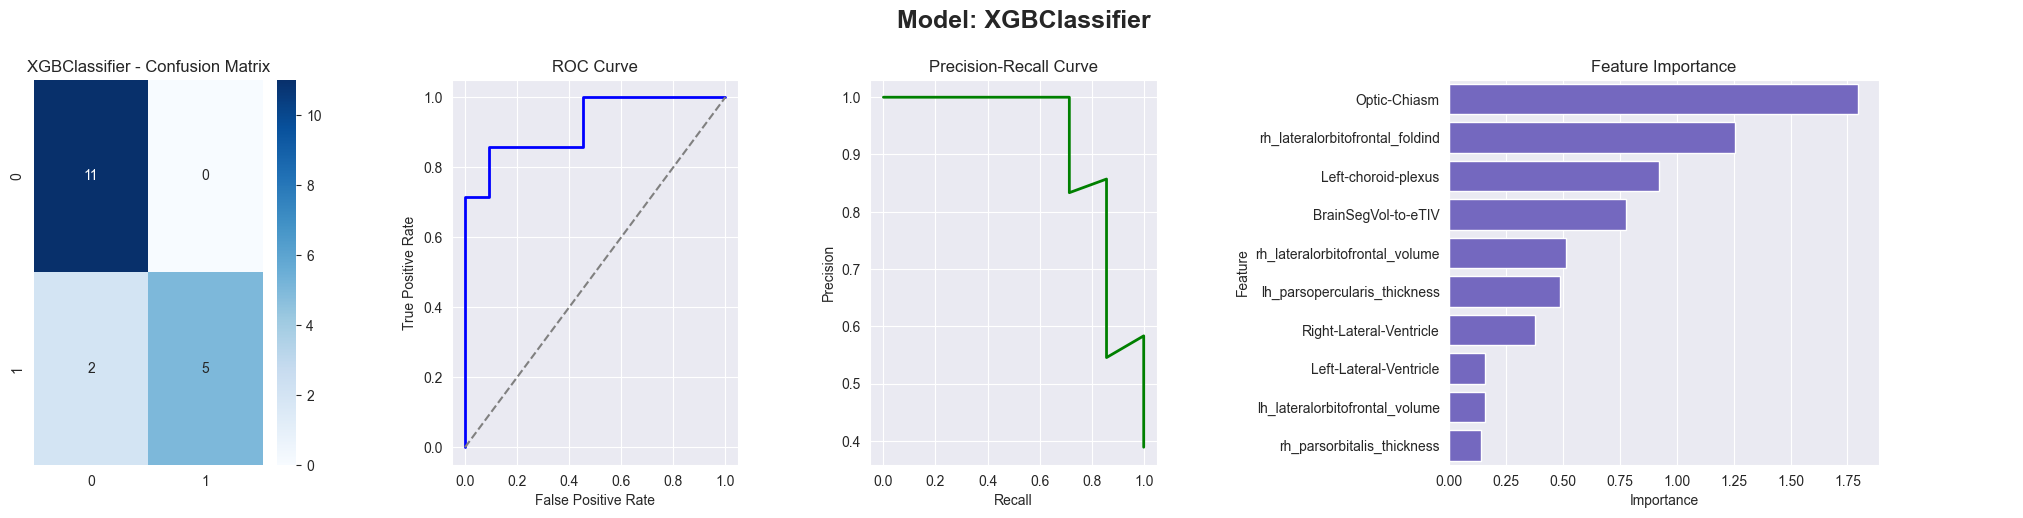


🔍 Processing LGBMClassifier...
[LightGBM] [Info] Number of positive: 52, number of negative: 52
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


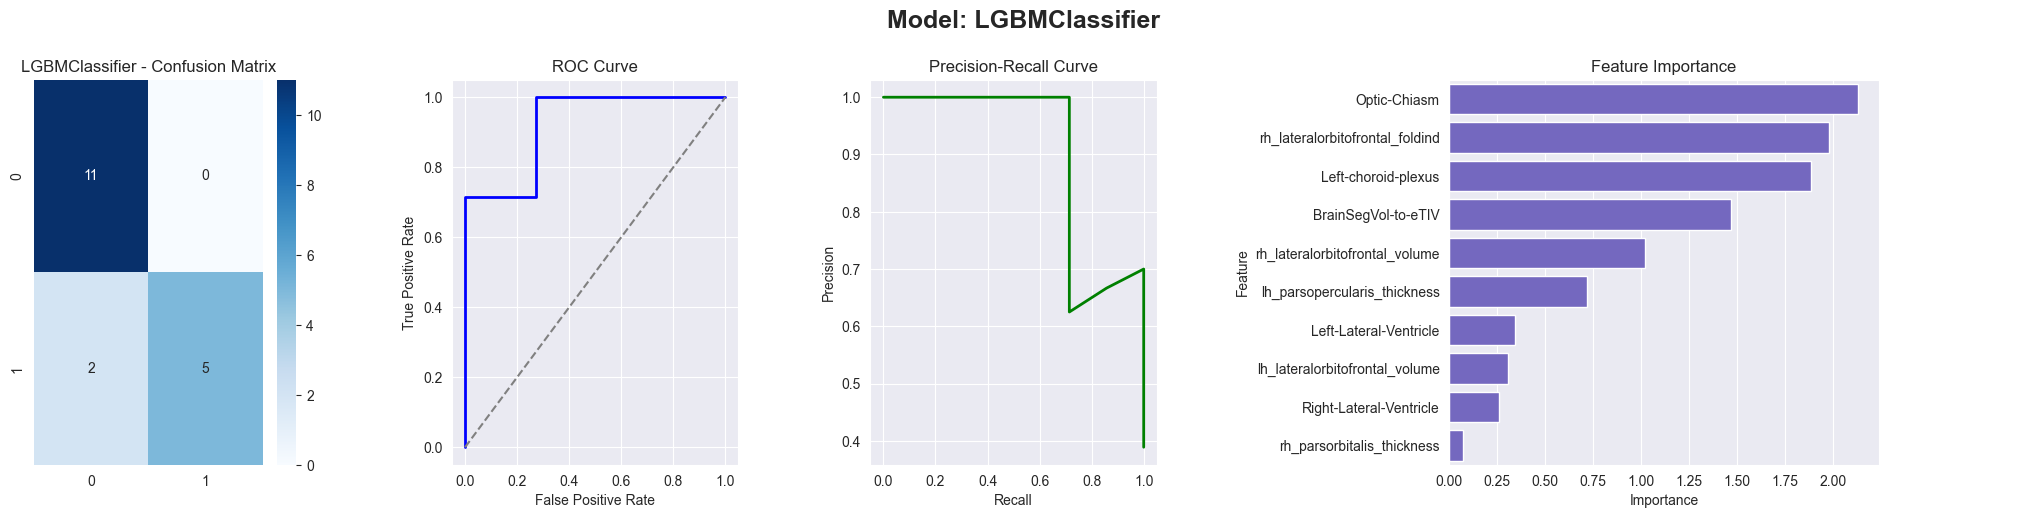


🔍 Processing CatBoostClassifier...


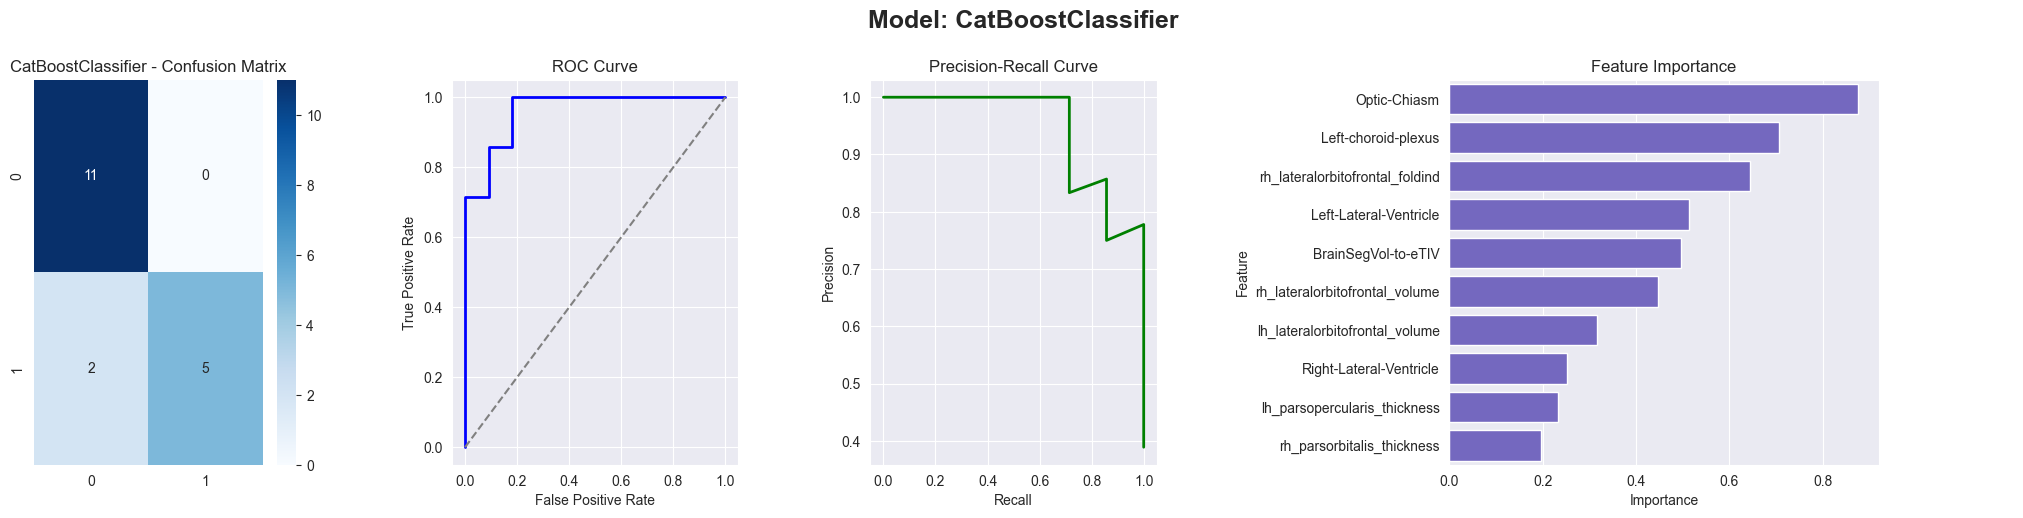

In [35]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

# Iterate over all models and generate visualizations
for model_name, model in models.items():
    print(f"\n🔍 Processing {model_name}...")

    # Train the model with SMOTE (if applicable)
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    model.fit(X_train_resampled, y_train_resampled)

    # Reset metrics to None before computing new values
    y_pred, y_proba = None, None
    fpr, tpr, roc_auc = None, None, None
    precision, recall = None, None
    conf_matrix = None
    shap_values, shap_feature_importance = None, None

    # Predictions
    try:
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
            y_proba = 1 / (1 + np.exp(-y_proba))  # Sigmoid transformation
        else:
            print(f"⚠️ {model_name} does not support probability predictions. Skipping ROC & PR curves.")

        # Compute Metrics if probability scores exist
        if y_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            precision, recall, _ = precision_recall_curve(y_test, y_proba)

        conf_matrix = confusion_matrix(y_test, y_pred)

    except Exception as e:
        print(f"❌ Error computing predictions & metrics for {model_name}: {e}")
        continue  # Skip to the next model if an error occurs

    # SHAP Values Calculation
    try:
        if model_name in ["RandomForest", "GradientBoosting", "XGBClassifier", "LGBMClassifier", "CatBoostClassifier"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            if isinstance(shap_values, list):
                shap_values = np.array(shap_values).mean(axis=0)  # Convert list to array

            shap_importance = np.abs(shap_values).mean(axis=0)

        elif model_name == "LogisticRegression":
            explainer = shap.LinearExplainer(model, X_train)
            shap_values = explainer.shap_values(X_test)
            shap_importance = np.abs(shap_values).mean(axis=0)

        elif model_name in ["SVC", "KNeighborsClassifier", "GaussianProcessClassifier"]:
            explainer = shap.KernelExplainer(model.predict, shap.kmeans(X_train, 10))
            shap_values = explainer.shap_values(X_test, nsamples=100)
            shap_importance = np.abs(shap_values).mean(axis=0)

        if shap_importance is not None and len(shap_importance) == X_train.shape[1]:
            shap_feature_importance = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': shap_importance
            }).sort_values(by="Importance", ascending=False).head(10)
        else:
            shap_feature_importance = None

    except Exception as e:
        print(f"❌ Error computing SHAP values for {model_name}: {e}")
        shap_feature_importance = None  # Ensure it is reset to None

    # Fallback to Feature Importance if SHAP is None
    if shap_feature_importance is None:
        try:
            if hasattr(model, "feature_importances_"):
                feature_importances = model.feature_importances_
            elif hasattr(model, "coef_"):
                feature_importances = np.abs(model.coef_).flatten()
            else:
                feature_importances = None

            if feature_importances is not None:
                shap_feature_importance = pd.DataFrame({
                    'Feature': X_train.columns,
                    'Importance': feature_importances
                }).sort_values(by="Importance", ascending=False).head(10)
                print(f"✅ Using `{model_name}` feature importance instead.")
            else:
                print(f"⚠️ No feature importance available for {model_name}. Skipping feature importance plot.")

        except Exception as e:
            print(f"❌ Error computing feature importance for {model_name}: {e}")
            shap_feature_importance = None

    # Print out when skipping a model due to missing data
    if shap_feature_importance is None:
        print(f"⚠️ No feature importance data available for {model_name}. Skipping plotting.")
        continue  # Skip plotting if no importance metrics exist

    # Plotting
    fig = plt.figure(figsize=(22, 5))
    gs = gridspec.GridSpec(1, 6, width_ratios=[1, 1, 1, 0.1, 1.5, 0.01])

    # Confusion Matrix
    ax0 = plt.subplot(gs[0])
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax0)
    ax0.set_title(f"{model_name} - Confusion Matrix")

    # ROC Curve
    ax1 = plt.subplot(gs[1])
    if roc_auc:
        ax1.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    ax1.plot([0, 1], [0, 1], color="gray", linestyle="--")
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title("ROC Curve")

    # Precision-Recall Curve
    ax2 = plt.subplot(gs[2])
    if precision is not None and recall is not None:
        ax2.plot(recall, precision, color="green", lw=2, label="Precision-Recall Curve")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-Recall Curve")

    # Empty Space
    ax_empty = plt.subplot(gs[3])
    ax_empty.axis("off")

    # Feature Importance Plot
    ax3 = plt.subplot(gs[4])
    sns.barplot(x=shap_feature_importance['Importance'], y=shap_feature_importance['Feature'], ax=ax3, color="slateblue")
    ax3.set_title("Feature Importance")

    # Extra empty space
    ax_space = plt.subplot(gs[5])
    ax_space.axis("off")

    plt.subplots_adjust(left=0.05, right=0.95, wspace=0.6, hspace=0.3)
    fig.suptitle(f"Model: {model_name}", fontsize=18, fontweight="bold", y=1.02)

    plt.show()


## ----------------- method 2 less models just the common ones

In [36]:
# 📌 SECTION 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib

# 📌 SECTION 2: Load & Preprocess Data
df = pd.read_csv(r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv")

# Drop Subject ID if present
df = df.drop(columns=['Subject_ID'], errors='ignore')

# Define feature matrix and target variable
X = df.drop(columns=['Label'])
y = df['Label']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 📌 SECTION 3: Bayesian Hyperparameter Tuning
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial, model_name):
    """Objective function for Optuna Bayesian Optimization."""
    
    y_train_array = y_train.to_numpy()  # Ensure y_train is a NumPy array

    if model_name == "Logistic Regression":
        C = trial.suggest_float("C", 0.01, 10, log=True)
        model = LogisticRegression(C=C, penalty="l2", solver="liblinear")

    elif model_name == "Random Forest":
        n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
        max_depth = trial.suggest_categorical("max_depth", [None, 10, 20, 30])
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10, step=2)
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)

    elif model_name == "Support Vector Machine":
        C = trial.suggest_float("C", 0.01, 10, log=True)
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
        model = SVC(C=C, kernel=kernel, probability=True, random_state=42)

    elif model_name == "K-Nearest Neighbors":
        n_neighbors = trial.suggest_int("n_neighbors", 3, 15, step=2)
        weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)

    elif model_name == "Gradient Boosting":
        n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)

    elif model_name == "XGBoost":
        n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        model = xgb.XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, eval_metric="logloss", random_state=42)

    # Cross-validation
    roc_auc_scores = []
    for train_idx, val_idx in kf.split(X_train, y_train_array):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train_array[train_idx], y_train_array[val_idx]

        # Apply SMOTE on training data only
        smote = SMOTE(random_state=42)
        X_fold_train_resampled, y_fold_train_resampled = smote.fit_resample(X_fold_train, y_fold_train)

        model.fit(X_fold_train_resampled, y_fold_train_resampled)
        y_proba = model.predict_proba(X_fold_val)[:, 1] if hasattr(model, "predict_proba") else None

        if y_proba is not None:
            roc_auc_scores.append(roc_auc_score(y_fold_val, y_proba))

    return np.mean(roc_auc_scores)

# 📌 SECTION 4: Perform Bayesian Optimization
models_to_tune = ["Logistic Regression", "Random Forest", "Support Vector Machine", "K-Nearest Neighbors", "Gradient Boosting", "XGBoost"]
optuna_results = {}

for model_name in models_to_tune:
    study = optuna.create_study(direction="maximize")  
    study.optimize(lambda trial: objective(trial, model_name), n_trials=30)

    optuna_results[model_name] = {
        "Best Params": study.best_params,
        "Best ROC-AUC (CV)": study.best_value
    }

# 📌 SECTION 5: Evaluate All Models on Test Set
metrics_summary = []

# Mapping model names to corresponding class constructors
model_mapping = {
    "Logistic Regression": LogisticRegression,
    "Random Forest": RandomForestClassifier,
    "Support Vector Machine": SVC,
    "K-Nearest Neighbors": KNeighborsClassifier,
    "Gradient Boosting": GradientBoostingClassifier,
    "XGBoost": xgb.XGBClassifier
}
#################################################
#  above gets the best parameters
#################################################
# below it fits the best parameters to each model
#################################################
for model_name, result in optuna_results.items():
    best_params = result["Best Params"]

    # Ensure SVM is instantiated with probability=True
    if model_name == "Support Vector Machine":
        model = SVC(**best_params, probability=True, random_state=42)
    elif model_name == "XGBoost":
        model = model_mapping[model_name](**best_params, eval_metric="logloss", random_state=42)
    else:
        model = model_mapping[model_name](**best_params)

    # Train best model with SMOTE on full train set
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    model.fit(X_train_resampled, y_train_resampled)

    # Predict on test set
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Compute Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="binary")
    recall = recall_score(y_test, y_pred, average="binary")
    f1 = f1_score(y_test, y_pred, average="binary")
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    metrics_summary.append([model_name, accuracy, precision, recall, f1, roc_auc])

    # Print metrics
    print(f"\n📊 {model_name} Test Set Metrics:")
    if roc_auc is not None:
        print(f"✅ Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | "
              f"F1 Score: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")
    else:
        print(f"✅ Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | "
              f"Recall: {recall:.4f} | F1 Score: {f1:.4f} | 🚨 ROC-AUC: Not Available (No `predict_proba`)")


# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_summary, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])
print("\n🔍 Test Performance Summary:")
print(metrics_df)

# 📌 Save Final Results
metrics_df.to_csv("D:/image_group_data/team44/Analysis/ML_short_results.csv", index=False)


[I 2025-02-04 12:37:34,890] A new study created in memory with name: no-name-a17e4d95-d5cd-4679-b419-20d24d839f52
[I 2025-02-04 12:37:34,926] Trial 0 finished with value: 0.9800000000000001 and parameters: {'C': 1.5862963022468277}. Best is trial 0 with value: 0.9800000000000001.
[I 2025-02-04 12:37:34,959] Trial 1 finished with value: 0.975 and parameters: {'C': 0.6419193189526815}. Best is trial 0 with value: 0.9800000000000001.
[I 2025-02-04 12:37:34,989] Trial 2 finished with value: 0.9800000000000001 and parameters: {'C': 0.05698203809363282}. Best is trial 0 with value: 0.9800000000000001.
[I 2025-02-04 12:37:35,019] Trial 3 finished with value: 0.975 and parameters: {'C': 0.3692551389406178}. Best is trial 0 with value: 0.9800000000000001.
[I 2025-02-04 12:37:35,048] Trial 4 finished with value: 0.975 and parameters: {'C': 0.4536963032658083}. Best is trial 0 with value: 0.9800000000000001.
[I 2025-02-04 12:37:35,087] Trial 5 finished with value: 0.9800000000000001 and parameter


📊 Logistic Regression Test Set Metrics:
✅ Accuracy: 0.9444 | Precision: 0.8333 | Recall: 1.0000 | F1 Score: 0.9091 | ROC-AUC: 0.9846

📊 Random Forest Test Set Metrics:
✅ Accuracy: 0.8889 | Precision: 0.8000 | Recall: 0.8000 | F1 Score: 0.8000 | ROC-AUC: 0.9692

📊 Support Vector Machine Test Set Metrics:
✅ Accuracy: 0.9444 | Precision: 1.0000 | Recall: 0.8000 | F1 Score: 0.8889 | ROC-AUC: 1.0000

📊 K-Nearest Neighbors Test Set Metrics:
✅ Accuracy: 0.8889 | Precision: 0.8000 | Recall: 0.8000 | F1 Score: 0.8000 | ROC-AUC: 0.9385

📊 Gradient Boosting Test Set Metrics:
✅ Accuracy: 0.8889 | Precision: 0.8000 | Recall: 0.8000 | F1 Score: 0.8000 | ROC-AUC: 0.9154

📊 XGBoost Test Set Metrics:
✅ Accuracy: 0.8889 | Precision: 0.8000 | Recall: 0.8000 | F1 Score: 0.8000 | ROC-AUC: 0.9692

🔍 Test Performance Summary:
                    Model  Accuracy  Precision  Recall  F1 Score   ROC-AUC
0     Logistic Regression  0.944444   0.833333     1.0  0.909091  0.984615
1           Random Forest  0.88888

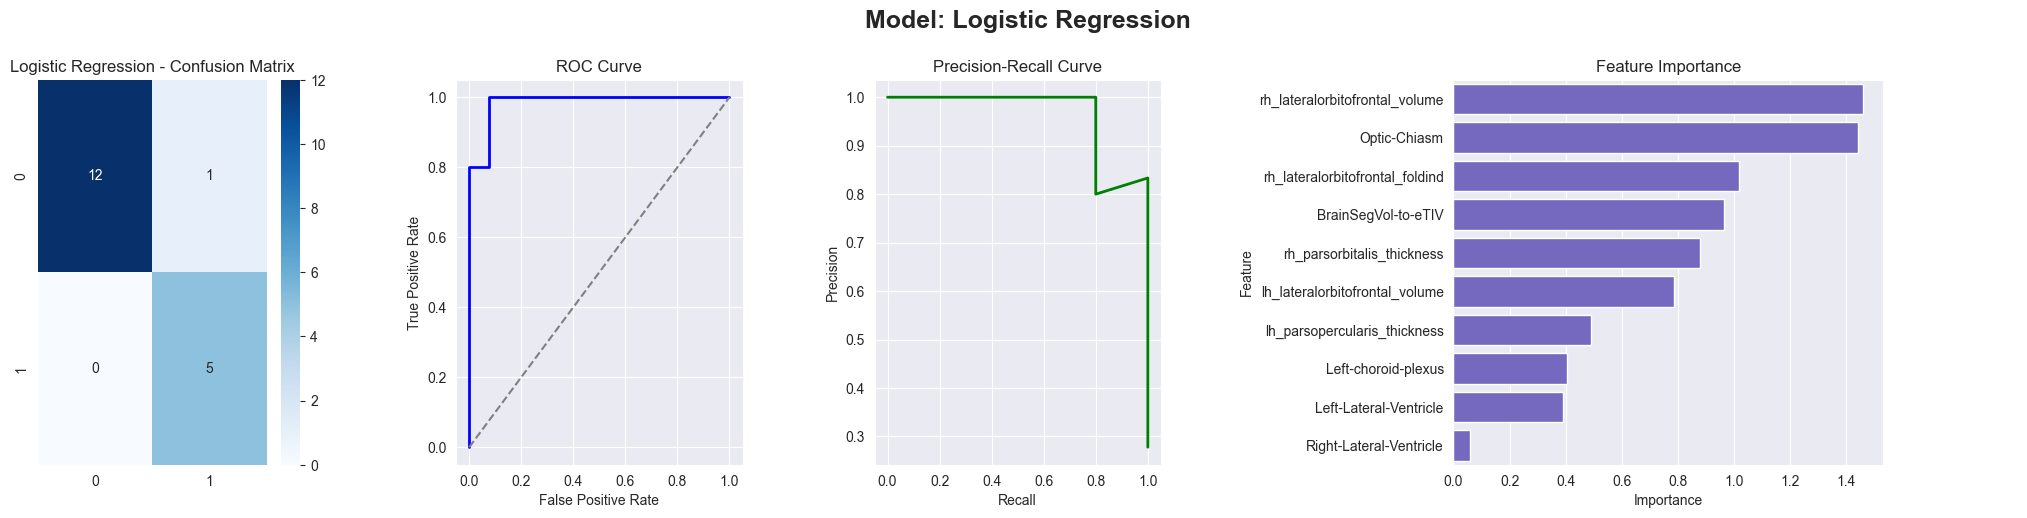

❌ Error computing SHAP values for Random Forest: Per-column arrays must each be 1-dimensional


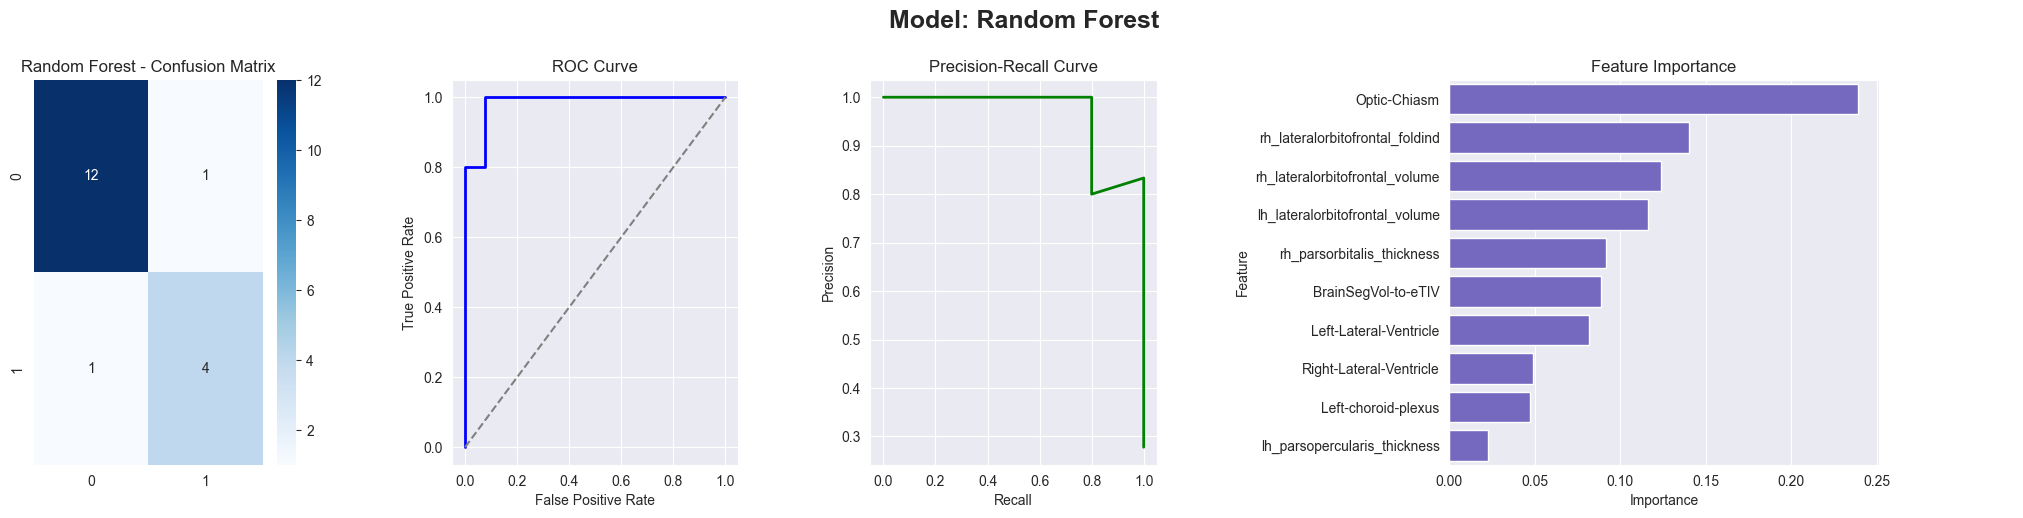

  0%|          | 0/18 [00:00<?, ?it/s]

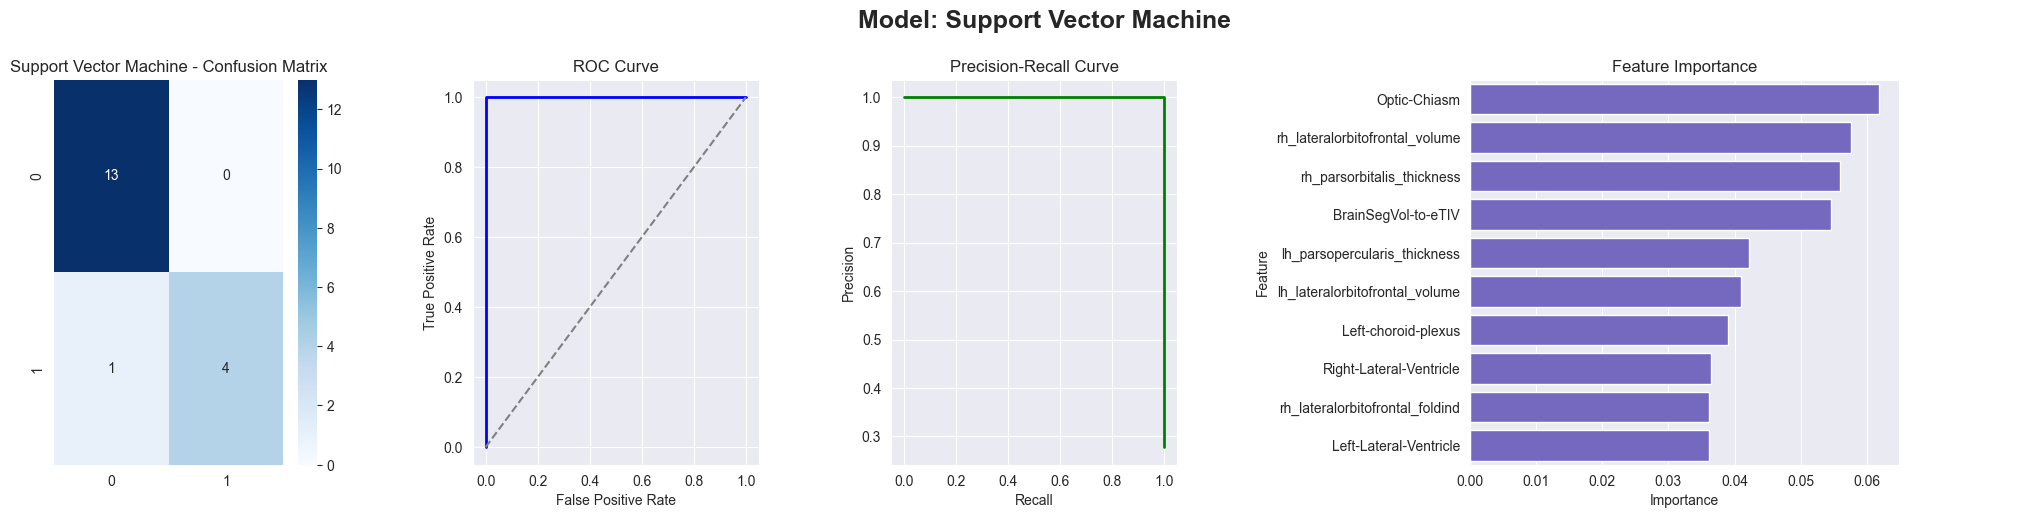

  0%|          | 0/18 [00:00<?, ?it/s]

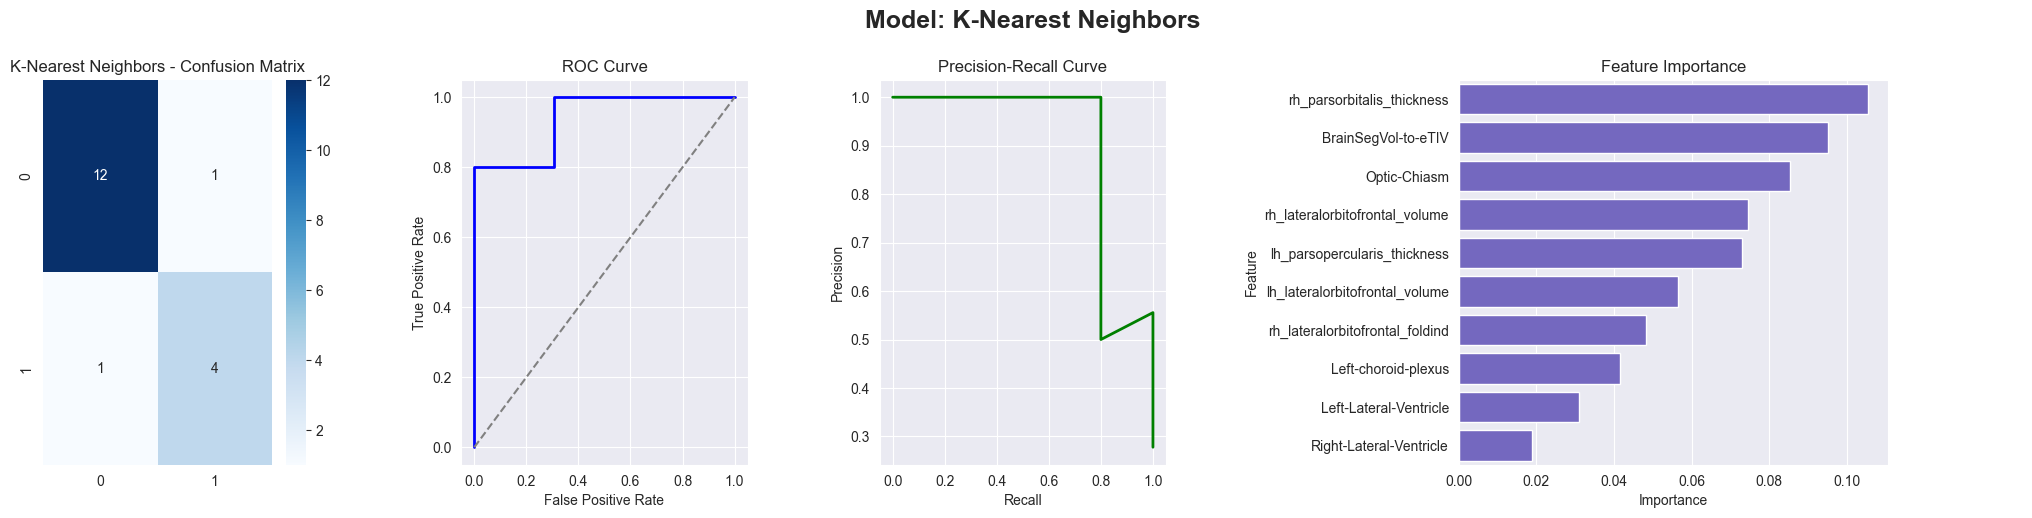

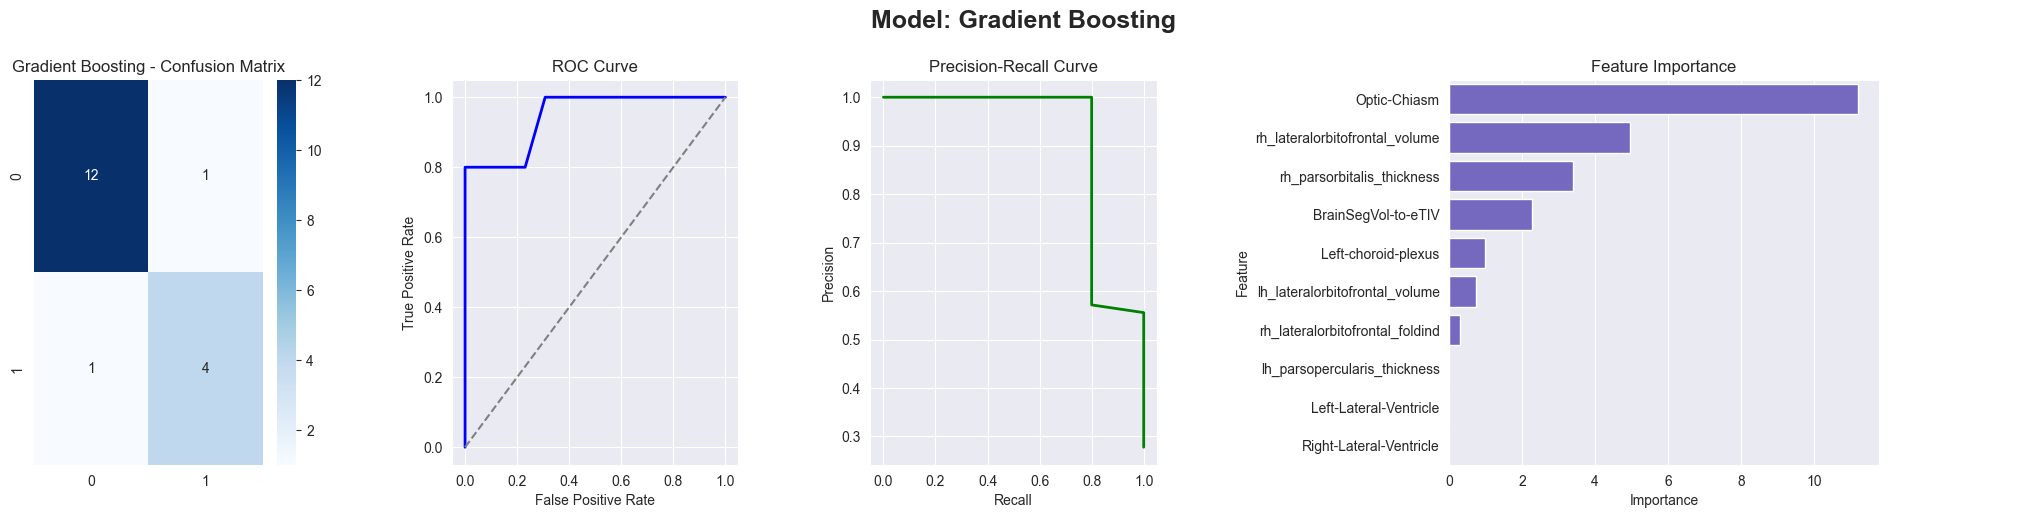

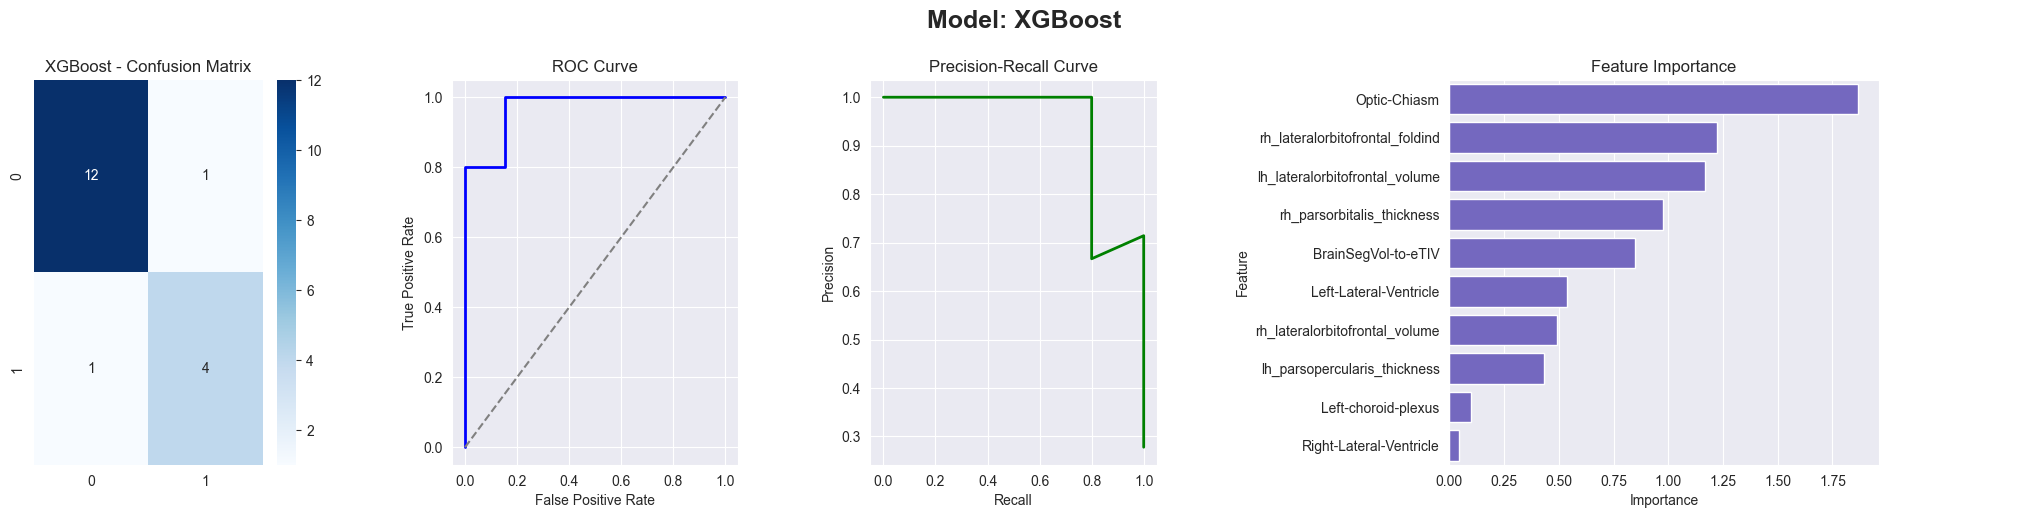

In [37]:

# Iterate over all models and generate visualizations
# Iterate over all models and generate visualizations
for model_name, result in optuna_results.items():
    best_params = result["Best Params"]

    if model_name in model_mapping:
        if model_name == "XGBoost":
            model = model_mapping[model_name](**best_params, eval_metric="logloss", random_state=42)
        elif model_name == "Support Vector Machine":
            model = model_mapping[model_name](**best_params, probability=True, random_state=42)  # ✅ Fix SVM Probability
        else:
            model = model_mapping[model_name](**best_params)
    else:
        raise ValueError(f"Model '{model_name}' not found in model_mapping.")

    # Train the model with SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Compute Metrics
    fpr, tpr, roc_auc = None, None, None
    precision, recall = None, None

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
    else:
        print(f"⚠️ {model_name} does not support `predict_proba()`. Skipping ROC & Precision-Recall curves.")

    conf_matrix = confusion_matrix(y_test, y_pred)

    # SHAP Values Calculation
    shap_values = None
    shap_feature_importance = None

    try:
        if model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            if isinstance(shap_values, list):  
                shap_values = np.mean(np.abs(shap_values), axis=0)

            shap_importance = np.abs(shap_values).mean(axis=0)

        elif model_name == "Logistic Regression":
            explainer = shap.LinearExplainer(model, X_train)
            shap_values = explainer.shap_values(X_test)
            shap_importance = np.abs(shap_values).mean(axis=0)

        elif model_name in ["Support Vector Machine", "K-Nearest Neighbors"]:
            explainer = shap.KernelExplainer(model.predict, shap.kmeans(X_train, 10))
            shap_values = explainer.shap_values(X_test, nsamples=100)
            shap_importance = np.abs(shap_values).mean(axis=0)

        if shap_importance is not None and len(shap_importance) == X_train.shape[1]:
            shap_feature_importance = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': shap_importance
            }).sort_values(by="Importance", ascending=False).head(10)
        else:
            shap_feature_importance = None

    except Exception as e:
        print(f"❌ Error computing SHAP values for {model_name}: {e}")

    # Fallback to Feature Importance if SHAP is None
    if shap_feature_importance is None:
        try:
            if model_name == "Random Forest":
                feature_importances = model.feature_importances_
                shap_feature_importance = pd.DataFrame({
                    'Feature': X_train.columns,
                    'Importance': feature_importances
                }).sort_values(by="Importance", ascending=False).head(10)
            elif model_name == "Logistic Regression":
                feature_importances = np.abs(model.coef_).flatten()
                shap_feature_importance = pd.DataFrame({
                    'Feature': X_train.columns,
                    'Importance': feature_importances
                }).sort_values(by="Importance", ascending=False).head(10)
            else:
                shap_feature_importance = None
        except Exception as e:
            print(f"❌ Error computing feature importance for {model_name}: {e}")

    # Plotting (only if SHAP is available)
    if shap_feature_importance is not None:
        fig = plt.figure(figsize=(22, 5))
        gs = gridspec.GridSpec(1, 6, width_ratios=[1, 1, 1, 0.1, 1.5, 0.01])  

        ax0 = plt.subplot(gs[0])
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax0)
        ax0.set_title(f"{model_name} - Confusion Matrix")

        ax1 = plt.subplot(gs[1])
        if roc_auc is not None:
            ax1.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
            ax1.plot([0, 1], [0, 1], color="gray", linestyle="--")
            ax1.set_xlabel("False Positive Rate")
            ax1.set_ylabel("True Positive Rate")
            ax1.set_title("ROC Curve")
        else:
            ax1.text(0.5, 0.5, "ROC Curve Not Available", ha="center", va="center", fontsize=12)
            ax1.axis("off")

        ax2 = plt.subplot(gs[2])
        if precision is not None and recall is not None:
            ax2.plot(recall, precision, color="green", lw=2, label="Precision-Recall Curve")
            ax2.set_xlabel("Recall")
            ax2.set_ylabel("Precision")
            ax2.set_title("Precision-Recall Curve")
        else:
            ax2.text(0.5, 0.5, "Precision-Recall Curve Not Available", ha="center", va="center", fontsize=12)
            ax2.axis("off")

        ax_empty = plt.subplot(gs[3])
        ax_empty.axis("off")  

        ax3 = plt.subplot(gs[4])
        sns.barplot(x=shap_feature_importance['Importance'], y=shap_feature_importance['Feature'], ax=ax3, color="slateblue")
        ax3.set_title("Feature Importance")

        ax_space = plt.subplot(gs[5])
        ax_space.axis("off")  

        plt.subplots_adjust(left=0.05, right=0.95, wspace=0.6, hspace=0.3)
        fig.suptitle(f"Model: {model_name}", fontsize=18, fontweight="bold", y=1.02)

        plt.show()
    else:
        print(f"⚠️ No feature importance data available for {model_name}. Skipping plotting.")


# regression

### Data Processing Pipeline Overview

This pipeline processes and updates structural data by extracting TDI scores and matching them with demographic data.

1. **Data Loading**:
   - **Structural data** is loaded from a CSV file.
   - **Demographic data** is loaded from an ODS file.

2. **Extract Numeric Subject ID**:
   - The function `extract_numeric_subject_id` uses regular expressions to extract the last numeric part from the `Subject_ID` in the dataset.

3. **TDI Update**:
   - A dictionary (`tdi_dict`) is created to map the `Subject_ID` (numeric part) from the **demographic data** to its corresponding **TDI score**.
   - The function `update_tdi_in_structural_data` updates the **structural data** by applying TDI scores based on the matched subject IDs.

4. **Data Update and Saving**:
   - The updated **structural data**, now containing TDI scores, is saved to a new CSV file.

#### Key Functions:
- **`extract_numeric_subject_id`**: Extracts the last numeric part from the `Subject_ID` using a regular expression.
- **`update_tdi_in_structural_data`**: Adds TDI scores to the structural data by matching the numeric part of `Subject_ID` from the demographic data.


In [38]:
import pandas as pd
import re

# Load the demographic data (File 1) and graph theory data (File 2)
demographic_data = pd.read_excel(r"D:\image_group_data\data\Demografical_data.ods")
graph_data = pd.read_csv(r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv")

# Function to extract numeric part of the subject ID from File 1 (Demographic Data)
def extract_subject_number_from_demographics(subject_name):
    if isinstance(subject_name, str):  # Check if it's a string
        # Assuming subject_name format is 'HC_sub01' or 'OLF_sub01'
        match = re.search(r'(HC|OLF)_sub(\d{2})', subject_name)
        if match:
            group = match.group(1)  # HC or OLF
            subject_number = match.group(2).zfill(3)  # Ensure it's 3 digits
            return group, subject_number
    return None, None  # Return None if subject_name is not a valid string

# Function to extract numeric part of the subject ID from File 2 (Graph Theory Data)
def extract_subject_number_from_graph(subject_id):
    if isinstance(subject_id, str):  # Check if it's a string
        # Regex to handle different patterns for the subject ID
        match = None
        # Match patterns like 'sub17', 'sub18', etc.
        if re.match(r'sub\d{2}', subject_id):  
            match = re.search(r'sub(\d{2})', subject_id)
        # Match patterns like 'subH01', 'subH02', etc.
        elif re.match(r'subH\d{2}', subject_id):  
            match = re.search(r'subH(\d{2})', subject_id)
        # Match patterns like 'h1sub13', 'h2sub16', etc.
        elif re.match(r'h1sub\d{2}', subject_id):
            match = re.search(r'h1sub(\d{2})', subject_id)
        elif re.match(r'h2sub\d{2}', subject_id):
            match = re.search(r'h2sub(\d{2})', subject_id)        
        elif re.match(r'h3sub\d{2}', subject_id):
            match = re.search(r'h3sub(\d{2})', subject_id)
        elif re.match(r'h4sub\d{2}', subject_id):
            match = re.search(r'h4sub(\d{2})', subject_id)            
        # Match patterns like 'team44HC1sub09', 'team44HC4sub54', etc.
        elif re.match(r'team44HC\dsub\d{2,3}', subject_id):  
            match = re.search(r'team44HC\dsub(\d{2,3})', subject_id)
        # Match patterns like 'team44OLF1sub05', 'team44OLF1sub10', etc.
        elif re.match(r'team44OLF\dsub\d{2,3}', subject_id):  
            match = re.search(r'team44OLF\dsub(\d{2,3})', subject_id)
        
        if match:
            # Get the numeric part and ensure it's 3 digits
            subject_number = match.group(1).zfill(3)  # Ensure it's 3 digits
            print(f"Extracted number: {subject_number} from {subject_id}")  # Print the extracted subject number
            return subject_number
    print(f"No match for {subject_id}")  # If no match is found, print this
    return None

# Create a dictionary for TDI scores based on the demographic data
def create_tdi_dict(demographic_data):
    tdi_dict = {}
    for _, row in demographic_data.iterrows():
        subject_name = row['Subjects']
        group, subject_number = extract_subject_number_from_demographics(subject_name)
        if group and subject_number:
            tdi_score = row['TDI']
            tdi_dict[(subject_number, group)] = tdi_score
    return tdi_dict

# Add TDI score to graph data based on subject number and group
def update_graph_with_tdi(graph_data, tdi_dict):
    def get_tdi_score(row):
        subject_number = extract_subject_number_from_graph(row['Subject_ID'])
        group = 'HC' if row['Label'] == 0 else 'OLF'
        # Match subject number and group, then get the TDI score
        if subject_number and (subject_number, group) in tdi_dict:
            return tdi_dict[(subject_number, group)]
        return None

    # Apply the function to the graph data and create a new 'TDI' column
    graph_data['TDI'] = graph_data.apply(get_tdi_score, axis=1)
    return graph_data

# Create the TDI dictionary from the demographic data
tdi_dict = create_tdi_dict(demographic_data)

# Update the graph data with TDI scores
updated_graph_data = update_graph_with_tdi(graph_data, tdi_dict)

# Save the updated graph data
updated_graph_data.to_csv(r'D:\image_group_data\team44\Analysis\regression_structural_data.csv', index=False)

print("Graph theory data has been updated with TDI scores.")


Extracted number: 017 from sub17
Extracted number: 018 from sub18
Extracted number: 019 from sub19
Extracted number: 023 from sub23
Extracted number: 024 from sub24
Extracted number: 025 from sub25
Extracted number: 026 from sub26
Extracted number: 027 from sub27
Extracted number: 028 from sub28
Extracted number: 029 from sub29
Extracted number: 032 from sub32
Extracted number: 033 from sub33
Extracted number: 035 from sub35
Extracted number: 036 from sub36
Extracted number: 037 from sub37
Extracted number: 038 from sub38
Extracted number: 040 from sub40
Extracted number: 001 from subH01
Extracted number: 002 from subH02
Extracted number: 003 from subH03
Extracted number: 004 from subH04
Extracted number: 005 from subH05
Extracted number: 006 from subH06
Extracted number: 007 from subH07
Extracted number: 008 from subH08
Extracted number: 013 from h1sub13
Extracted number: 014 from h1sub14
Extracted number: 015 from h1sub15
Extracted number: 016 from h2sub16
Extracted number: 017 from 

# gridsearcch

### Regression Pipeline Overview with Imbalance Handling

This pipeline applies various regression models to predict `TDI`, using feature extraction from the dataset.

1. **Data Preprocessing**:
   - The dataset is loaded, and `Subject_ID`, `Label`, and `TDI` columns are removed.
   - A log transformation is applied to `TDI` to stabilize variance and handle imbalance for linear models.

2. **Train-Test Split**:
   - The data is split into training and testing sets (80-20).

3. **Handling Imbalance**:
   - **Sample Weights**: Used for models like Random Forest, Decision Tree, and XGBoost to handle imbalance by assigning higher weights to underrepresented regions of the target variable.
   - **SMOTE**: Not directly applied in regression; instead, sample weights handle the imbalance.

4. **Model Tuning**:
   - **GridSearchCV** tunes hyperparameters for models, including:
     - Linear Regression
     - Random Forest (sample weights supported)
     - Gradient Boosting
     - XGBoost (sample weights supported)
     - Decision Tree (sample weights supported)
     - KNN, Lasso, Ridge, and ElasticNet

5. **Model Fitting**:
   - Models are trained using the training data, with sample weights applied where supported.

6. **Model Evaluation**:
   - Metrics: MAE, MSE, RMSE, and R² are calculated for both train and test data.

7. **Results**:
   - Metrics are saved to a CSV file for comparison.

#### Models Handling Imbalance:
- **Random Forest, Decision Tree, and XGBoost**: Use sample weights to handle imbalance.
- Other models (Linear Regression, Gradient Boosting, KNN) do not handle imbalance directly but use sample weights for improved focus on underrepresented data.


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# Function to evaluate the model and print MAE, MSE, RMSE, and R²
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Evaluates the model and prints MAE, MSE, RMSE, and R² for both train and test data
    """
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    # Train Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Test Metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"Train MAE: {train_mae:.4f}, Train MSE: {train_mse:.4f}, Train RMSE: {train_rmse:.4f}, Train R²: {train_r2:.4f}")
    print(f"Test MAE: {test_mae:.4f}, Test MSE: {test_mse:.4f}, Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
    
    return {
        'Train MAE': train_mae,
        'Train MSE': train_mse,
        'Train RMSE': train_rmse,
        'Train R²': train_r2,
        'Test MAE': test_mae,
        'Test MSE': test_mse,
        'Test RMSE': test_rmse,
        'Test R²': test_r2
    }

# Load data
data_path = 'D:/image_group_data/team44/Analysis/regression_structural_data.csv'
updated_structural_data = pd.read_csv(data_path)

# Extract features (X) and target (y)
X = updated_structural_data.drop(columns=['Subject_ID', 'Label', 'TDI'])  # Remove 'Label' and 'TDI' from features
y = updated_structural_data['TDI']  # Set 'TDI' as the target variable

# Apply log transformation to address imbalance for linear models
y_log = np.log1p(y)  # Log transformation to stabilize variance

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Initialize models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'XGBoost Regressor': xgb.XGBRegressor(random_state=42)
}

# Define parameter grids for each model
param_grids = {
    'Linear Regression': {
        'fit_intercept': [True, False]  # Removed 'normalize' parameter
    },
    'Random Forest Regressor': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'Gradient Boosting Regressor': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 1.0]
    },
    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'epsilon': [0.01, 0.1, 0.2],
        'kernel': ['linear', 'poly', 'rbf']
    },
    'ElasticNet': {
        'alpha': [0.1, 0.5, 1],
        'l1_ratio': [0.1, 0.5, 0.9]
    },
    'Lasso': {
        'alpha': [0.1, 0.5, 1]
    },
    'Ridge': {
        'alpha': [0.1, 0.5, 1]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    },
    'Decision Tree Regressor': {
        'max_depth': [3, 5, 10],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost Regressor': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    }
}

# Dictionary to hold the metrics for all models
metrics = {}

# Apply GridSearchCV for each model
for model_name, model in models.items():
    print(f"Grid Search for {model_name}...")
    
    # Use Grid Search if the model has a param_grid defined
    param_grid = param_grids.get(model_name, None)
    
    if param_grid:
        grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
        grid_search.fit(X_train, y_train)
        print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
        model = grid_search.best_estimator_

    # Calculate sample weights based on the target distribution
    weights = np.sqrt(np.abs(y_train - y_train.mean()))  # Higher weights for underrepresented regions of the target
    
    if model_name == "XGBoost Regressor" or model_name == "Random Forest Regressor" or model_name == "Decision Tree Regressor":
        # Models that support sample weights
        model.fit(X_train, y_train, sample_weight=weights)
    else:
        model.fit(X_train, y_train)

    metrics[model_name] = evaluate_model(model, X_train, y_train, X_test, y_test)

# Convert the metrics to DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics).T

# Save the metrics to a CSV file
output_file_path = 'D:/image_group_data/team44/Analysis/regression_grid_results_full_with_log_and_sample_weights.csv'
metrics_df.to_csv(output_file_path)

print(f"Model evaluation results saved to {output_file_path}")


Grid Search for Linear Regression...
Best Parameters for Linear Regression: {'fit_intercept': True}
Train MAE: 0.2517, Train MSE: 0.1081, Train RMSE: 0.3288, Train R²: 0.5858
Test MAE: 0.3226, Test MSE: 0.1509, Test RMSE: 0.3884, Test R²: 0.3981
Grid Search for Random Forest Regressor...
Best Parameters for Random Forest Regressor: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Train MAE: 0.1225, Train MSE: 0.0331, Train RMSE: 0.1820, Train R²: 0.8730
Test MAE: 0.2616, Test MSE: 0.1159, Test RMSE: 0.3404, Test R²: 0.5377
Grid Search for Gradient Boosting Regressor...
Best Parameters for Gradient Boosting Regressor: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Train MAE: 0.1959, Train MSE: 0.0657, Train RMSE: 0.2563, Train R²: 0.7483
Test MAE: 0.2841, Test MSE: 0.1393, Test RMSE: 0.3733, Test R²: 0.4442
Grid Search for Support Vector Regressor...
Best Parameters for Support Vector Regressor: 

wight and log? imbalence

##### Model Evaluation and Visualization Pipeline

This script evaluates models and visualizes performance.

1. **Models:**
    - Linear Regression
    - Random Forest Regressor
    - Gradient Boosting Regressor
    - Support Vector Regressor (SVR)
    - ElasticNet
    - Lasso
    - Ridge
    - K-Nearest Neighbors (KNN)
    - Decision Tree Regressor
    - XGBoost Regressor

2. **Metrics:**
    - **Residuals Plot:** Difference between actual and predicted values (with Lowess smoothing).
    - **Predictions vs Actuals:** Compares true vs predicted values; ideal case: points on the red line.
    - **Feature Importance:** Significant features contributing to model predictions.

3. **Notes:**
    - **ElasticNet** and **Lasso** ignore zero coefficients.

4. **Plot Explanation:**
    - **Residuals Plot:** Model fit assessment.
    - **Predictions vs Actual:** Comparison of actual vs predicted.
    - **Feature Importance:** Shows top influential features.


Evaluating Linear Regression...
Evaluating Random Forest Regressor...
Evaluating Gradient Boosting Regressor...
Evaluating Support Vector Regressor...
Evaluating ElasticNet...
Evaluating Lasso...
Evaluating Ridge...
Evaluating K-Nearest Neighbors...


C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


Evaluating Decision Tree Regressor...
Evaluating XGBoost Regressor...

Explanations for each type of plot:
1. Residuals plot: Shows the difference between actual and predicted values. Red line is lowess smoothing.
2. Predictions vs Actual: Compares actual vs predicted values with a red line as the ideal case.
3. Feature importance: Displays the most influential features for model predictions.


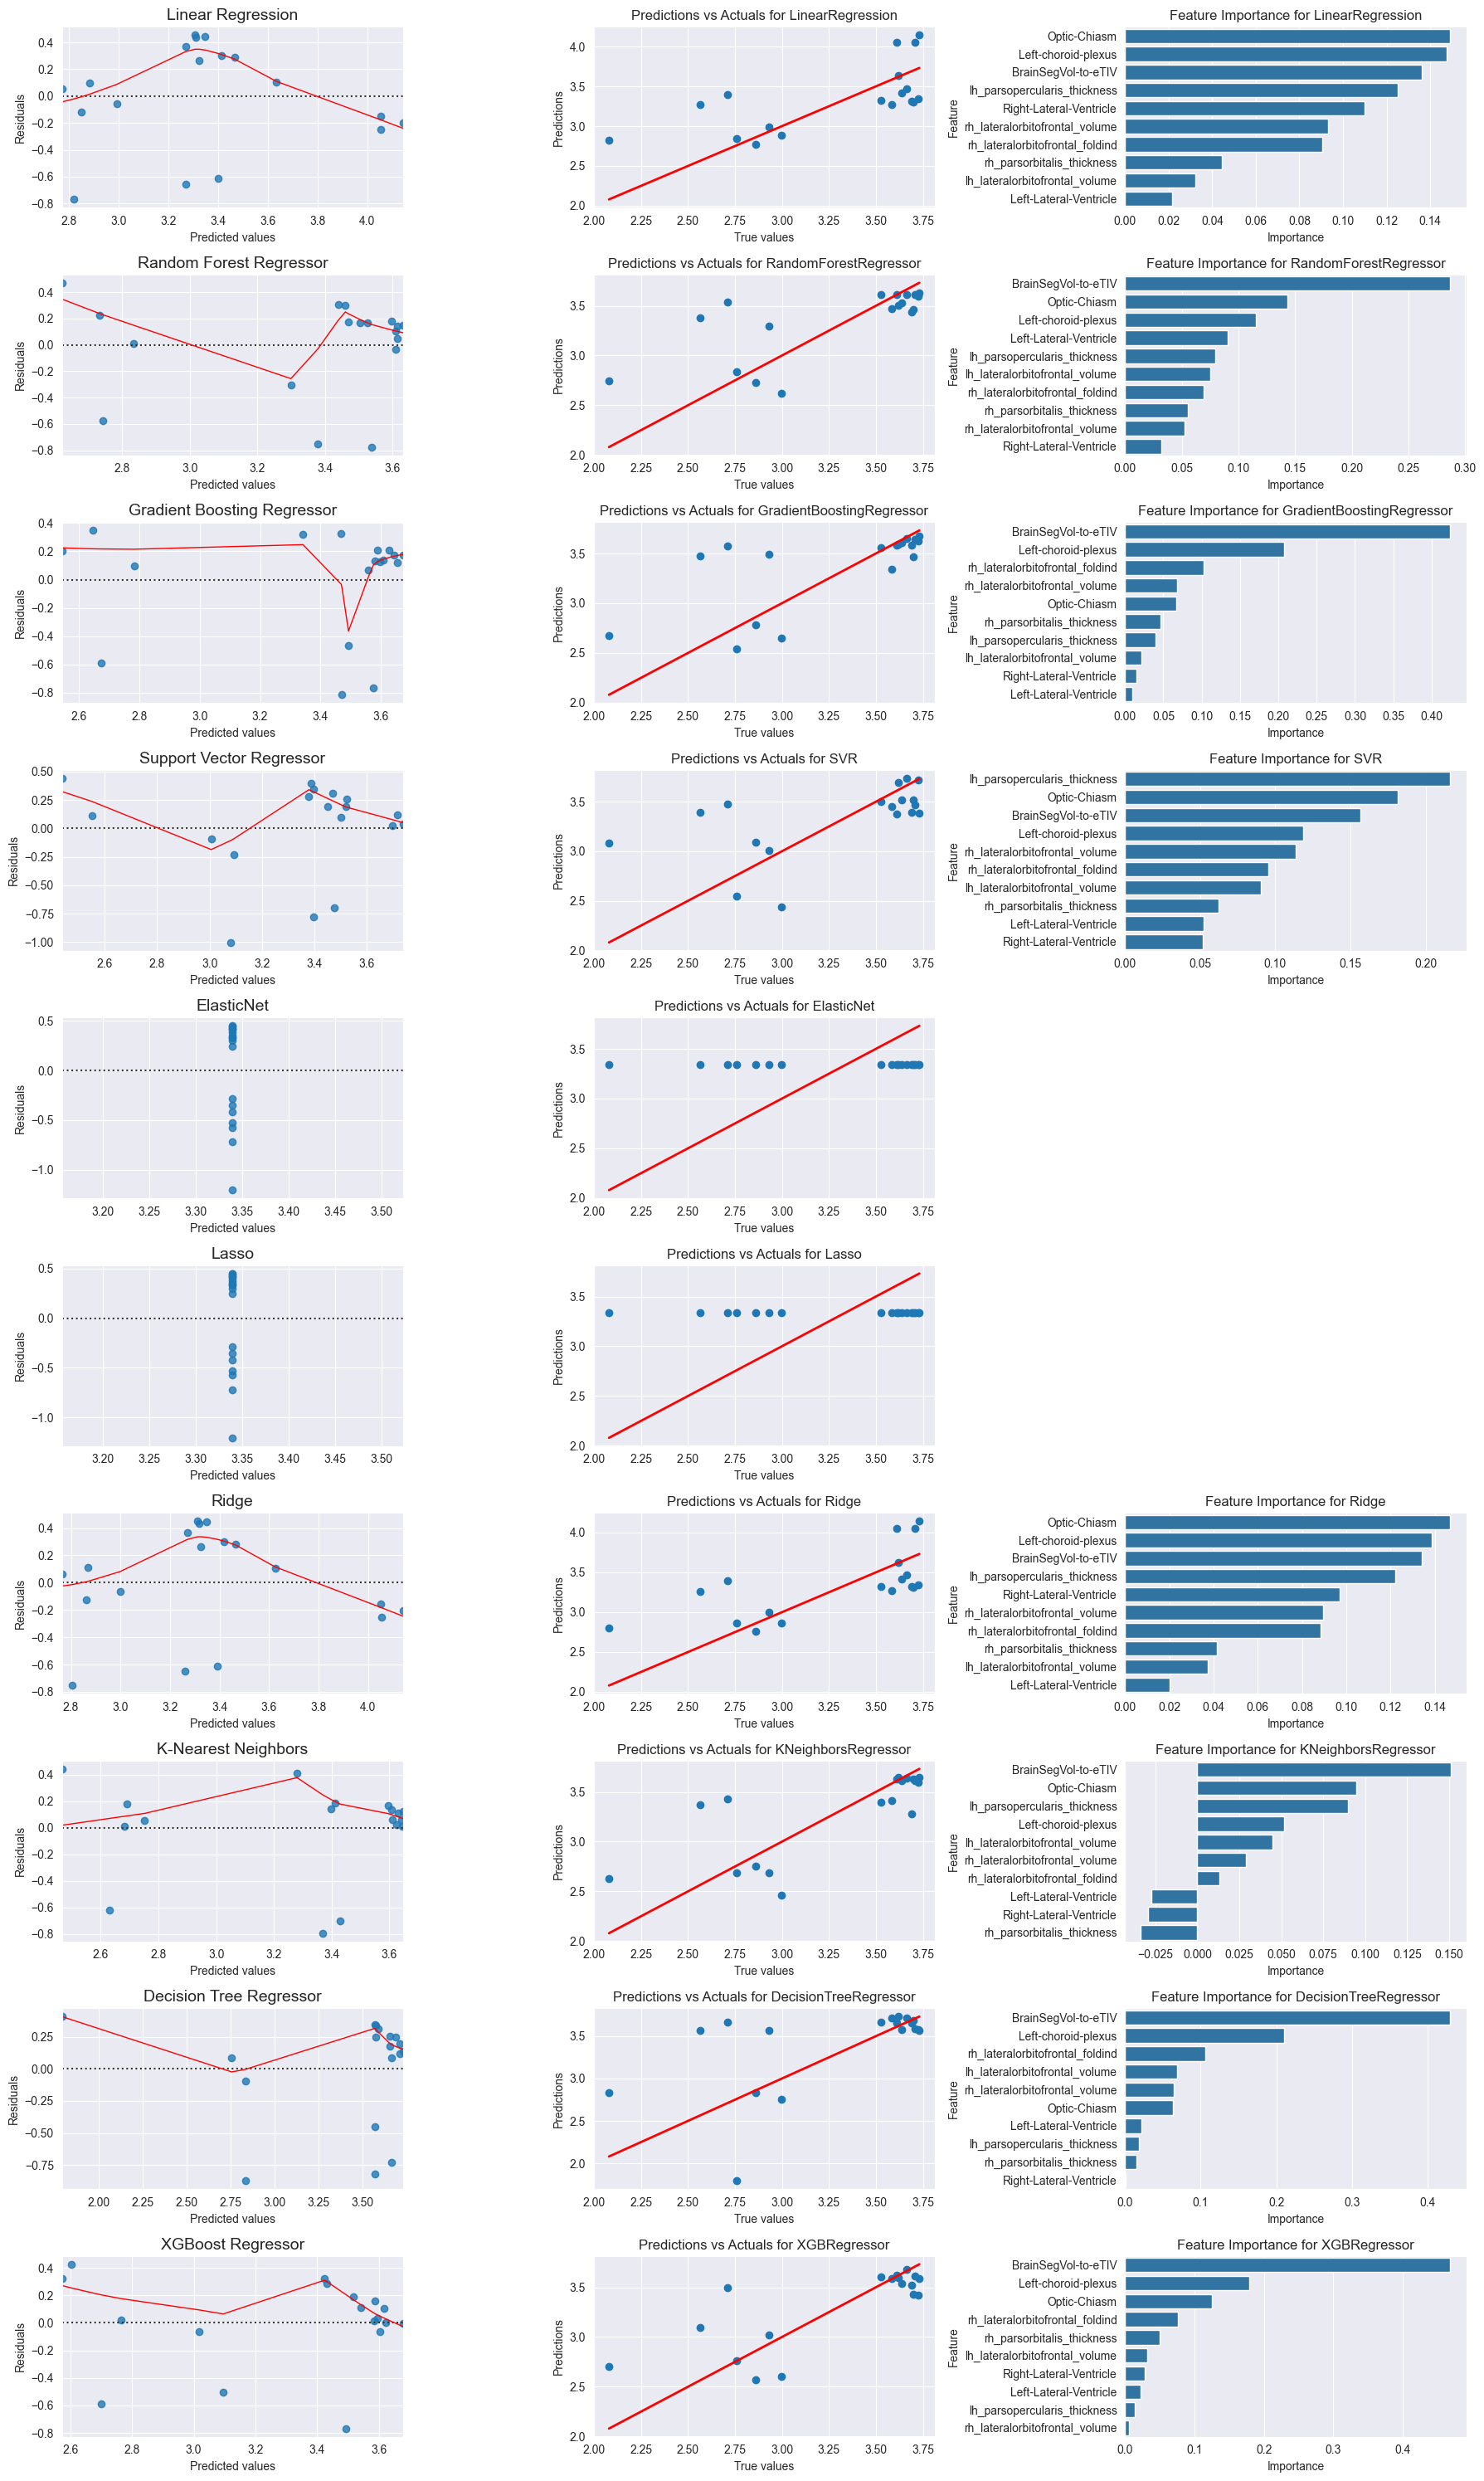

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import xgboost as xgb
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Function to plot residuals
def plot_residuals(model, X_test, y_test, ax):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1}, ax=ax)
    ax.set_xlabel('Predicted values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals plot for {model.__class__.__name__}')

# Function to plot predictions vs actual
def plot_predictions_vs_actual(model, X_test, y_test, ax):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
    ax.set_xlabel('True values')
    ax.set_ylabel('Predictions')
    ax.set_title(f'Predictions vs Actuals for {model.__class__.__name__}')

# Function to plot feature importance
def plot_feature_importance(model, X_train, ax):
    if hasattr(model, 'feature_importances_'):
        # For tree-based models like Random Forest, XGBoost, etc.
        feature_importance = model.feature_importances_
        features = X_train.columns
        importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
        ax.set_title(f'Feature Importance for {model.__class__.__name__}')
    
    elif hasattr(model, 'coef_'):
        # For linear models (ElasticNet, Lasso, Ridge, etc.)
        feature_importance = np.abs(model.coef_)
        
        # Only keep non-zero feature importances (for ElasticNet/Lasso)
        non_zero_importance = feature_importance[feature_importance > 1e-5]  # Ignore very small coefficients
        
        if non_zero_importance.size > 0:
            features = X_train.columns[:len(non_zero_importance)]  # Adjust size if some coefficients are zero
            importance_df = pd.DataFrame({'Feature': features, 'Importance': non_zero_importance})
            importance_df = importance_df.sort_values(by='Importance', ascending=False)
            sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
            ax.set_title(f'Feature Importance for {model.__class__.__name__}')
        else:
            # No significant features
            ax.set_visible(False)
            ax.set_title(f'No Significant Features for {model.__class__.__name__}')
    
    elif isinstance(model, KNeighborsRegressor):
        result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
        importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': result.importances_mean})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
        ax.set_title(f'Feature Importance for {model.__class__.__name__}')
    
    elif isinstance(model, SVR):
        result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
        importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': result.importances_mean})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
        ax.set_title(f'Feature Importance for {model.__class__.__name__}')
    
    else:
        ax.set_visible(False)

# List of models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'XGBoost Regressor': xgb.XGBRegressor(random_state=42)
}

# Initialize metrics dictionary
metrics = {}

# Create subplots for each model's residuals, predictions vs actuals, and feature importance
fig, axes = plt.subplots(len(models), 3, figsize=(18, 3 * len(models)))

# Assuming you've resampled your data with SMOTE
# Replace X_train_resampled and y_train_resampled with actual data
# Example:
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train each model and plot results
for i, (model_name, model) in enumerate(models.items()):
    print(f"Evaluating {model_name}...")
    
    model.fit(X_train, y_train)  # Use your resampled data here if needed
    
    # Plotting residuals, predictions vs actuals, and feature importance
    plot_residuals(model, X_test, y_test, axes[i, 0])  # Residuals plot
    plot_predictions_vs_actual(model, X_test, y_test, axes[i, 1])  # Predictions vs Actuals
    plot_feature_importance(model, X_train, axes[i, 2])  # Feature Importance plot
    
    axes[i, 0].set_title(model_name, fontsize=14, loc='center')

# Add explanations for each plot type
print("\nExplanations for each type of plot:")
print("1. Residuals plot: Shows the difference between actual and predicted values. Red line is lowess smoothing.")
print("2. Predictions vs Actual: Compares actual vs predicted values with a red line as the ideal case.")
print("3. Feature importance: Displays the most influential features for model predictions.")

# Adjust layout to avoid overlap
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.tight_layout()
plt.show()


baysian

### Regression Pipeline with Model Tuning and Imbalance Handling

This pipeline evaluates and tunes multiple regression models using Bayesian optimization while addressing class imbalance.

1. **Data Preprocessing**:
   - **Train-Test Split**: The data is split into training (80%) and testing (20%) sets.
   - **Log Transformation**: A log transformation is applied to the target variable (`TDI`) to stabilize variance and make the data more suitable for regression models, particularly for models that do not directly address imbalance.

2. **Imbalance Handling**:
   - **Log Transformation**: While not directly addressing class imbalance through resampling techniques like SMOTE, the log transformation can reduce the skewness of the target variable and make models more effective in handling imbalance.
   - **Sample Weights**: For models like **Random Forest**, **XGBoost**, **Gradient Boosting**, **SVR**, **Decision Trees**, and **KNN**, sample weights can be utilized to give higher importance to underrepresented regions of the target variable. This is particularly relevant for tree-based models.

3. **Model Evaluation**:
   - **Models Evaluated**:
     - Linear Regression
     - Random Forest Regressor
     - Gradient Boosting Regressor
     - Support Vector Regressor (SVR)
     - ElasticNet
     - Lasso
     - Ridge
     - K-Nearest Neighbors (KNN)
     - Decision Tree Regressor
     - XGBoost Regressor
   - **Metrics**: MAE, MSE, RMSE, and R² are calculated for both training and testing datasets to evaluate the model's predictive performance.

4. **Hyperparameter Tuning**:
   - **Bayesian Optimization (BayesSearchCV)** is used to fine-tune hyperparameters for each model.
     - **Random Forest**: Tuning parameters like `n_estimators`, `max_depth`, `min_samples_split`, etc.
     - **XGBoost**: Optimizes parameters like `learning_rate`, `subsample`, and `colsample_bytree`.
     - **Gradient Boosting**: Focuses on parameters such as `learning_rate`, `max_depth`, `min_samples_split`, and `n_estimators`.
     - **SVR**: Optimized for parameters like `C`, `gamma`, and `kernel`.
     - **KNN**: Tuning the number of neighbors (`n_neighbors`) and weights.

5. **Model Fitting and Evaluation**:
   - Models are trained using the log-transformed data (for models that benefit from it).
   - **BayesSearchCV** identifies the best hyperparameters for each model.
   - The models are evaluated on the test set, and results are stored for comparison.

6. **Results**:
   - The evaluation results are saved to a CSV file, which includes the best hyperparameters for each model.

#### Imbalance Handling for Each Model:
- **Random Forest, Decision Tree, XGBoost**: These models support the use of sample weights to address imbalance by giving more importance to underrepresented target values.
- **Gradient Boosting, SVR, KNN**: These models also support the use of sample weights to improve model performance on imbalanced data.
- **ElasticNet, Lasso, Ridge**: These models are generally not designed to handle imbalance directly, but the log transformation of the target variable helps reduce skewness and mitigate imbalance to some extent.

#### Summary:
The pipeline handles class imbalance mainly through the **log transformation** of the target variable and utilizes **sample weights** for models that can accommodate it. Hyperparameter tuning is done using **Bayesian optimization** to find the best configuration for each model.


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from skopt import BayesSearchCV  # Import Bayesian Search

# Function to evaluate the model and print MAE, MSE, RMSE, and R²
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Evaluates the model and prints MAE, MSE, RMSE, and R² for both train and test data
    """
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    # Train Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Test Metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"Train MAE: {train_mae:.4f}, Train MSE: {train_mse:.4f}, Train RMSE: {train_rmse:.4f}, Train R²: {train_r2:.4f}")
    print(f"Test MAE: {test_mae:.4f}, Test MSE: {test_mse:.4f}, Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}")
    
    return {
        'Train MAE': train_mae,
        'Train MSE': train_mse,
        'Train RMSE': train_rmse,
        'Train R²': train_r2,
        'Test MAE': test_mae,
        'Test MSE': test_mse,
        'Test RMSE': test_rmse,
        'Test R²': test_r2
    }

# Load data
data_path = 'D:/image_group_data/team44/Analysis/regression_structural_data.csv'
updated_structural_data = pd.read_csv(data_path)

# Extract features (X) and target (y)
X = updated_structural_data.drop(columns=['Subject_ID', 'Label', 'TDI'])  # Remove 'Label' and 'TDI' from features
y = updated_structural_data['TDI']  # Set 'TDI' as the target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply log transformation to the target variable for models that don't directly address imbalance
y_train_log = np.log1p(y_train)  # log(1 + TDI)
y_test_log = np.log1p(y_test)  # log(1 + TDI)

# Define the search space for hyperparameter tuning
param_grid_rf = {
    'n_estimators': (50, 500),
    'max_depth': (3, 20),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 10),
    'max_features': ['sqrt', 'log2', None]  # Corrected from 'auto' to valid values
}

param_grid_xgb = {
    'n_estimators': (50, 500),
    'learning_rate': (0.001, 0.1, 'uniform'),
    'max_depth': (3, 20),
    'subsample': (0.5, 1.0, 'uniform'),
    'colsample_bytree': (0.5, 1.0, 'uniform')
}

param_grid_gb = {
    'n_estimators': (50, 500),
    'learning_rate': (0.001, 0.1, 'uniform'),
    'max_depth': (3, 20),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 10)
}

param_grid_svr = {
    'C': (0.1, 10.0, 'uniform'),
    'kernel': ['linear', 'rbf'],
    'gamma': (0.001, 1.0, 'uniform')
}

param_grid_dt = {
    'max_depth': (3, 20),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 10)
}

param_grid_knn = {
    'n_neighbors': (3, 30),
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Set up Bayesian optimization using scikit-optimize (BayesSearchCV)
opt_rf = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

opt_xgb = BayesSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid_xgb,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

opt_gb = BayesSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

opt_svr = BayesSearchCV(
    SVR(),
    param_grid_svr,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

opt_dt = BayesSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

opt_knn = BayesSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit the models with Bayesian Optimization (with log transformation for certain models)
opt_rf.fit(X_train, y_train_log)
opt_xgb.fit(X_train, y_train_log)
opt_gb.fit(X_train, y_train_log)
opt_svr.fit(X_train, y_train_log)
opt_dt.fit(X_train, y_train_log)
opt_knn.fit(X_train, y_train_log)

# Output best hyperparameters found by Bayesian Optimization
print(f"Best hyperparameters for RandomForest: {opt_rf.best_params_}")
print(f"Best hyperparameters for XGBoost: {opt_xgb.best_params_}")
print(f"Best hyperparameters for GradientBoosting: {opt_gb.best_params_}")
print(f"Best hyperparameters for SVR: {opt_svr.best_params_}")
print(f"Best hyperparameters for DecisionTree: {opt_dt.best_params_}")
print(f"Best hyperparameters for KNeighbors: {opt_knn.best_params_}")

# Evaluate the models on the test set and collect metrics
metrics = {}

metrics['RandomForest'] = evaluate_model(opt_rf, X_train, y_train_log, X_test, y_test_log)
metrics['XGBoost'] = evaluate_model(opt_xgb, X_train, y_train_log, X_test, y_test_log)
metrics['GradientBoosting'] = evaluate_model(opt_gb, X_train, y_train_log, X_test, y_test_log)
metrics['SVR'] = evaluate_model(opt_svr, X_train, y_train_log, X_test, y_test_log)
metrics['DecisionTree'] = evaluate_model(opt_dt, X_train, y_train_log, X_test, y_test_log)
metrics['KNeighbors'] = evaluate_model(opt_knn, X_train, y_train_log, X_test, y_test_log)

# Convert the metrics to DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics).T

# Save the metrics to a CSV file
output_file_path = 'D:/image_group_data/team44/Analysis/regression_results_full_with_bayesian_all_models.csv'
metrics_df.to_csv(output_file_path)

print(f"Model evaluation results saved to {output_file_path}")


C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [3, 6, 10] before, using random point [7, 7, 10]
  warnings.warn(
C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [3, 6, 10] before, using random point [19, 8, 4]
  warnings.warn(
C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [3, 6, 10] before, using random point [19, 5, 6]
  warnings.warn(
C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [3, 6, 2] before, using random point [18, 7, 9]
  warnings.warn(
C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\skopt\optim

Best hyperparameters for RandomForest: OrderedDict({'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500})
Best hyperparameters for XGBoost: OrderedDict({'colsample_bytree': 0.5, 'learning_rate': 0.09119627040017272, 'max_depth': 17, 'n_estimators': 50, 'subsample': 0.7288361480393148})
Best hyperparameters for GradientBoosting: OrderedDict({'learning_rate': 0.044428669950817165, 'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 50})
Best hyperparameters for SVR: OrderedDict({'C': 0.1, 'gamma': 0.053401366157368235, 'kernel': 'rbf'})
Best hyperparameters for DecisionTree: OrderedDict({'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 3})
Best hyperparameters for KNeighbors: OrderedDict({'algorithm': 'auto', 'n_neighbors': 9, 'weights': 'distance'})
Train MAE: 0.1409, Train MSE: 0.0452, Train RMSE: 0.2126, Train R²: 0.8268
Test MAE: 0.2609, Test MSE: 0.1175, Test RMSE: 0.3428, Test R²: 0.5310


### Model Evaluation and Visualization Pipeline

This script evaluates machine learning models and visualizes performance.

1. **Models Evaluated:**
    - Linear Regression
    - Random Forest Regressor
    - Gradient Boosting Regressor
    - Support Vector Regressor (SVR)
    - ElasticNet
    - Lasso
    - Ridge
    - K-Nearest Neighbors (KNN)
    - Decision Tree Regressor
    - XGBoost Regressor

2. **Metrics Calculated:**
    - **Residuals Plot:** Shows the difference between actual and predicted values. The red line is a Lowess smoothing fit.
    - **Predictions vs Actuals:** Compares true vs predicted values. The ideal case is when all points lie along the red line.
    - **Feature Importance:** Displays significant features contributing to model predictions. Non-zero coefficients for linear models and feature importances for tree-based models.

3. **Important Notes:**
    - **ElasticNet** and **Lasso** ignore features with zero coefficients.

4. **Explanation of Plot Types:**
    - **Residuals Plot:** Assesses model fit.
    - **Predictions vs Actual:** Compares actual vs predicted values.
    - **Feature Importance:** Shows which features influence predictions most.


Evaluating Linear Regression...
Evaluating Random Forest Regressor...
Evaluating Gradient Boosting Regressor...
Evaluating Support Vector Regressor...
Evaluating ElasticNet...
Evaluating Lasso...
Evaluating Ridge...
Evaluating K-Nearest Neighbors...
Evaluating Decision Tree Regressor...
Evaluating XGBoost Regressor...

Explanations for each type of plot:
1. Residuals plot: Shows the difference between actual and predicted values. Red line is lowess smoothing.
2. Predictions vs Actual: Compares actual vs predicted values with a red line as the ideal case.
3. Feature importance: Displays the most influential features for model predictions.


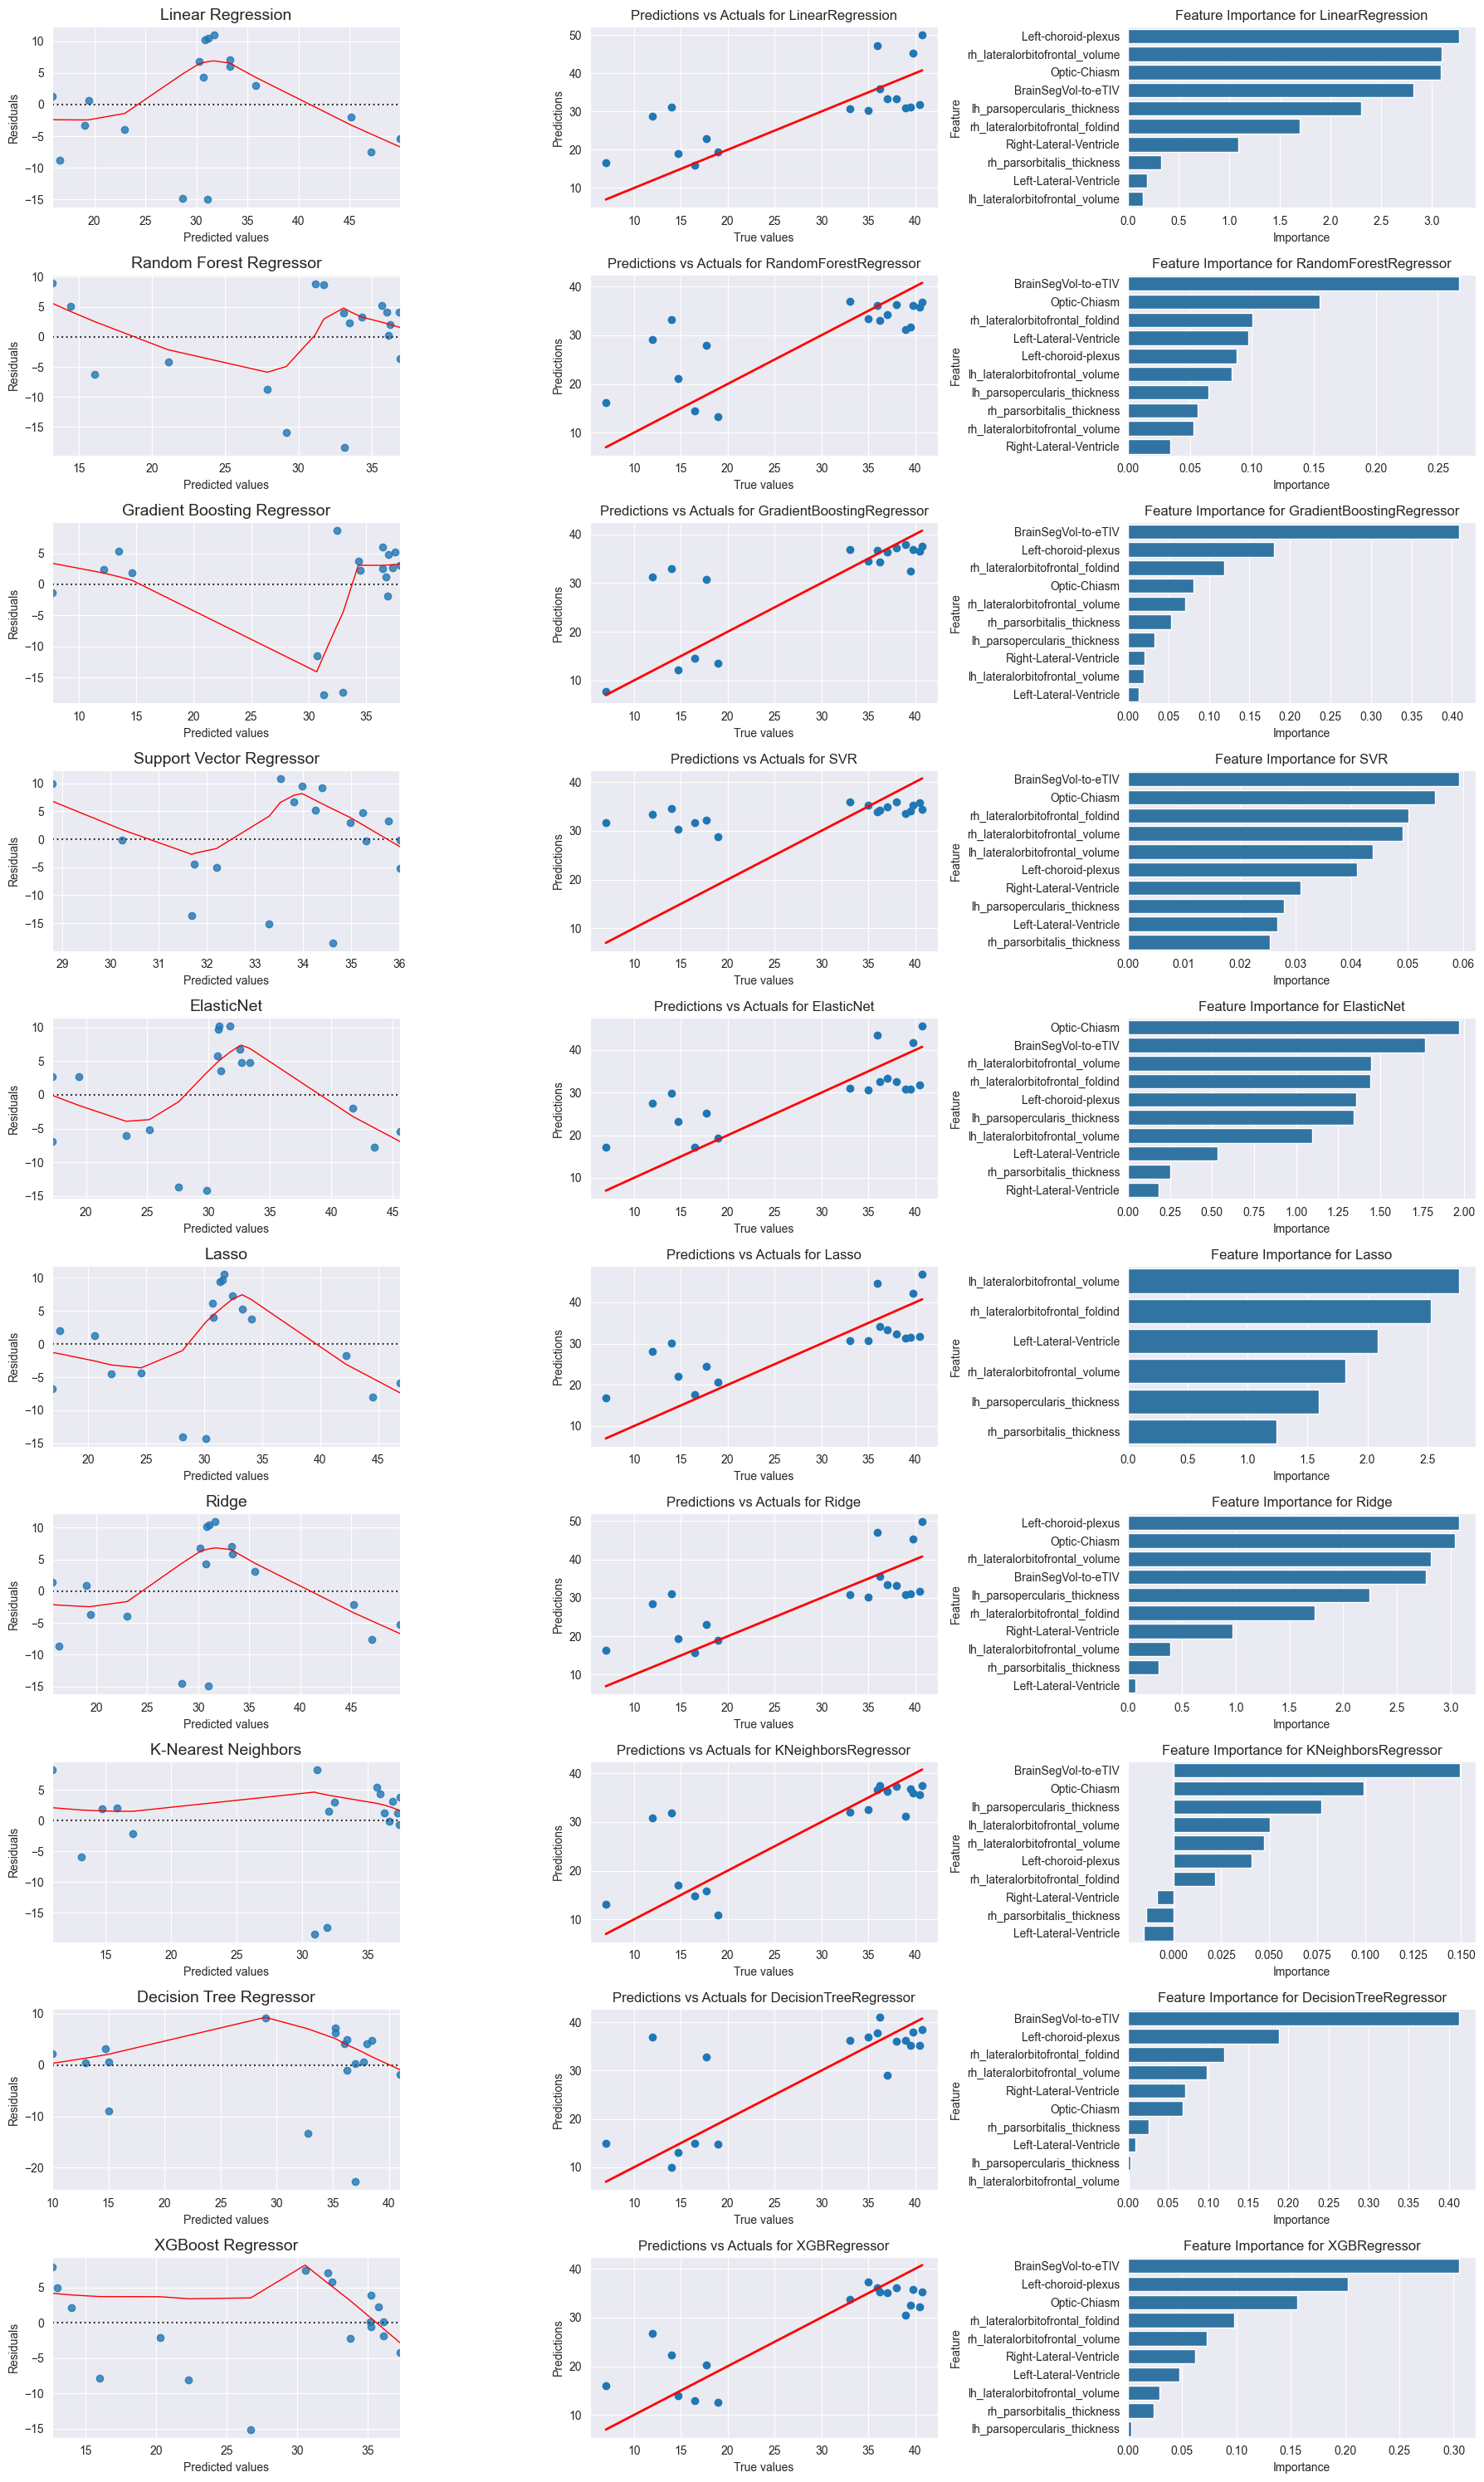

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import xgboost as xgb
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Define function to plot residuals
def plot_residuals(model, X_test, y_test, ax):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1}, ax=ax)
    ax.set_xlabel('Predicted values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals plot for {model.__class__.__name__}')

# Define function to plot predictions vs actual
def plot_predictions_vs_actual(model, X_test, y_test, ax):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
    ax.set_xlabel('True values')
    ax.set_ylabel('Predictions')
    ax.set_title(f'Predictions vs Actuals for {model.__class__.__name__}')

def plot_feature_importance(model, X_train, ax):
    if hasattr(model, 'feature_importances_'):
        # For tree-based models like Random Forest, XGBoost, etc.
        feature_importance = model.feature_importances_
        features = X_train.columns
        importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
        ax.set_title(f'Feature Importance for {model.__class__.__name__}')
    
    elif hasattr(model, 'coef_'):
        # For linear models (ElasticNet, Lasso, Ridge, etc.)
        feature_importance = np.abs(model.coef_)
        
        # Only keep non-zero feature importances (for ElasticNet/Lasso)
        non_zero_importance = feature_importance[feature_importance > 1e-5]  # Ignore very small coefficients
        
        if non_zero_importance.size > 0:
            features = X_train.columns[:len(non_zero_importance)]  # Adjust size if some coefficients are zero
            importance_df = pd.DataFrame({'Feature': features, 'Importance': non_zero_importance})
            importance_df = importance_df.sort_values(by='Importance', ascending=False)
            sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
            ax.set_title(f'Feature Importance for {model.__class__.__name__}')
        else:
            # No significant features
            ax.set_visible(False)
            ax.set_title(f'No Significant Features for {model.__class__.__name__}')
    
    elif isinstance(model, KNeighborsRegressor):
        result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
        importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': result.importances_mean})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
        ax.set_title(f'Feature Importance for {model.__class__.__name__}')
    
    elif isinstance(model, SVR):
        result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=42)
        importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': result.importances_mean})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax)
        ax.set_title(f'Feature Importance for {model.__class__.__name__}')
    
    else:
        ax.set_visible(False)



# List of models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'XGBoost Regressor': xgb.XGBRegressor(random_state=42)
}

# Initialize metrics dictionary
metrics = {}

# Create subplots for each model's residuals, predictions vs actuals, and feature importance
fig, axes = plt.subplots(len(models), 3, figsize=(18, 3 * len(models)))

# Assuming you've resampled your data with SMOTE
# Replace X_train_resampled and y_train_resampled with actual data
# Example:
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train each model and plot results
for i, (model_name, model) in enumerate(models.items()):
    print(f"Evaluating {model_name}...")
    
    model.fit(X_train, y_train)  # Use your resampled data here if needed
    
    # Plotting residuals, predictions vs actuals, and feature importance
    plot_residuals(model, X_test, y_test, axes[i, 0])  # Residuals plot
    plot_predictions_vs_actual(model, X_test, y_test, axes[i, 1])  # Predictions vs Actuals
    plot_feature_importance(model, X_train, axes[i, 2])  # Feature Importance plot
    
    axes[i, 0].set_title(model_name, fontsize=14, loc='center')

# Add explanations for each plot type
print("\nExplanations for each type of plot:")
print("1. Residuals plot: Shows the difference between actual and predicted values. Red line is lowess smoothing.")
print("2. Predictions vs Actual: Compares actual vs predicted values with a red line as the ideal case.")
print("3. Feature importance: Displays the most influential features for model predictions.")

# Adjust layout to avoid overlap
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.tight_layout()
plt.show()


# Deep learning 

---------------------------------------------

# suppervised classification

LSTM

In [43]:
import gc
import tensorflow as tf
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
import random
import os

# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Define evaluation metrics function
def evaluate_metrics(y_true, y_pred, y_pred_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_pred_prob)
    }
    return metrics

# Define a function to process a single dataset and evaluate the model
def process_dataset(file_path):
    # Load dataset
    df = pd.read_csv(file_path)
    X = df.drop(columns=['Label', 'Subject_ID'])
    y = df['Label'].values

    # Standardize features
    
    X_scaled = X

    # Optional PCA
    use_pca = False
    n_components = 10
    if use_pca:
        pca = PCA(n_components=n_components)
        X_scaled = pca.fit_transform(X_scaled)

    # Handle imbalanced data (optional)
    smote = SMOTE(random_state=seed)
    X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

    # Reshape for LSTM
    X_balanced = X_balanced.to_numpy()  # Convert to NumPy array before reshaping
    X_lstm = X_balanced.reshape((X_balanced.shape[0], 1, X_balanced.shape[1]))  # Now reshaping will work


    # K-Fold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    cv_accuracy = []
    cv_auc = []

    for train_idx, val_idx in kf.split(X_lstm):
        X_train_fold, X_val_fold = X_lstm[train_idx], X_lstm[val_idx]
        y_train_fold, y_val_fold = y_balanced[train_idx], y_balanced[val_idx]

        # Build the model
        model = Sequential([
            Input(shape=(1, X_train_fold.shape[2])),  # Use Input layer
            LSTM(64, activation='relu'),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='binary_crossentropy', metrics=['accuracy'])

        # Train the model with early stopping
        early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold),
                  epochs=20, batch_size=32, callbacks=[early_stopping], verbose=0)

        # Evaluate the fold
        y_val_pred_prob = model.predict(X_val_fold).ravel()
        y_val_pred = (y_val_pred_prob > 0.5).astype(int)
        cv_accuracy.append(accuracy_score(y_val_fold, y_val_pred))
        cv_auc.append(roc_auc_score(y_val_fold, y_val_pred_prob))

    # Final Model Training
    X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_balanced, test_size=0.2, random_state=seed)
    model = Sequential([
        Input(shape=(1, X_train.shape[2])),  # Use Input layer
        LSTM(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)

    model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=32,
              callbacks=[early_stopping, lr_scheduler, model_checkpoint])

    # Evaluate on the test set
    y_test_pred_prob = model.predict(X_test).ravel()
    y_test_pred = (y_test_pred_prob > 0.5).astype(int)
    test_metrics = evaluate_metrics(y_test, y_test_pred, y_test_pred_prob)

    # Compile results
    results = {
        "Dataset": os.path.basename(file_path),
        "CV_Accuracy": np.mean(cv_accuracy),
        "CV_AUC": np.mean(cv_auc),
        "Test_Accuracy": test_metrics["accuracy"],
        "Test_Precision": test_metrics["precision"],
        "Test_Recall": test_metrics["recall"],
        "Test_F1_Score": test_metrics["f1_score"],
        "Test_AUC": test_metrics["auc"]
    }
    return results

# Process multiple datasets
def process_datasets(dataset_paths):
    all_results = []
    for dataset_path in dataset_paths:
        print(f"Processing dataset: {dataset_path}")
        result = process_dataset(dataset_path)
        all_results.append(result)
    return pd.DataFrame(all_results)

# Example usage
dataset_paths = [
        r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv",
    ]

# Process all datasets and save results
final_results = process_datasets(dataset_paths)
final_results.to_csv(r"D:\image_group_data\team44\Analysis\LSTM_all_cor_ttest_bayesopt_smote_V2.csv", index=False)

print(final_results)


Processing dataset: D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.3813 - loss: 0.7210 - val_accuracy: 0.5000 - val_loss: 0.7130 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5329 - loss: 0.6979 - val_accuracy: 0.5000 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7094 - loss: 0.6789 - val_accuracy: 0.8000 - val_loss: 0.6734 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8168 - loss: 0.6661 - val_accuracy: 0.8000 - val_loss: 0.6550 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8959 - loss: 0.6570 - val_accuracy: 0.7000 -

In [44]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    make_scorer
)
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from scikeras.wrappers import KerasClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, InputLayer, Conv1D, Flatten,
    LSTM, GRU, BatchNormalization, MultiHeadAttention, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Bayesian Optimization
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


###############################################################################
# 1) Custom Specificity Scorer & Scoring Dict
###############################################################################
def specificity_score(y_true, y_pred):
    """TN/(TN+FP) for binary classification."""
    if y_pred.dtype not in [np.int32, np.int64, np.bool_]:
        y_pred = (y_pred >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp + 1e-9)

specificity_scorer = make_scorer(specificity_score, greater_is_better=True)

scoring = {
    'accuracy':    make_scorer(accuracy_score),
    'f1':          make_scorer(f1_score, average='binary'),
    'precision':   make_scorer(precision_score, average='binary', zero_division=0),
    'recall':      make_scorer(recall_score, average='binary'),
    'specificity': specificity_scorer,
    'roc_auc':     make_scorer(roc_auc_score, needs_proba=True)
}


###############################################################################
# 2) Model Builders (Using meta=None)
###############################################################################
from tensorflow.keras.regularizers import l2

def build_mlp_simple_model(lr=1e-3, hidden_units=64, dropout_rate=0.4, meta=None):
    input_dim = meta["n_features_in_"]
    model = Sequential([
        InputLayer(input_shape=(input_dim,)),
        Dense(hidden_units, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_mlp_deeper_model(
    lr=1e-3,
    hidden_units_1=128,
    hidden_units_2=64,
    hidden_units_3=32,
    dropout_rate=0.5,
    meta=None
):
    input_dim = meta["n_features_in_"]
    model = Sequential([
        InputLayer(input_shape=(input_dim,)),
        Dense(hidden_units_1, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(hidden_units_2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(hidden_units_3, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(1, activation='sigmoid')
    ])
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_1d_model(
    lr=1e-3,
    filters=32,
    kernel_size=3,
    hidden_units=64,
    dropout_rate=0.2,
    meta=None
):
    input_dim = meta["n_features_in_"]
    model = Sequential([
        InputLayer(input_shape=(input_dim, 1)),
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        Flatten(),
        Dense(hidden_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_gru_model(lr=1e-3, gru_units=64, dropout_rate=0.2, meta=None):
    input_dim = meta["n_features_in_"]
    model = Sequential([
        InputLayer(input_shape=(input_dim, 1)),
        GRU(gru_units, activation='tanh'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

from tensorflow.keras.layers import Input, MultiHeadAttention, Dense, Dropout, Flatten, LayerNormalization

def build_transformer_model(lr=1e-3, num_heads=4, hidden_units=64, dropout_rate=0.4, meta=None):
    input_dim = meta["n_features_in_"]
    
    # Input layer
    inputs = Input(shape=(input_dim, 1))
    
    # MultiHeadAttention layer
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=hidden_units)(inputs, inputs)
    attention_output = LayerNormalization()(attention_output)
    
    # Fully connected layers
    dense_output = Dense(hidden_units, activation='relu')(attention_output)
    dense_output = Dropout(dropout_rate)(dense_output)
    
    # Flatten the output before the final layer
    flat_output = Flatten()(dense_output)
    outputs = Dense(1, activation='sigmoid')(flat_output)
    
    # Define the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    opt = Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model



###############################################################################
# 3) Model Config Dictionary
###############################################################################
# We'll add a "reshape_to_3d" step if reshape_needed is True.
reshape_to_3d = FunctionTransformer(lambda X: np.expand_dims(X, axis=-1))

model_configs = {
    "MLP_Simple": {
        "build_fn": build_mlp_simple_model,
        "reshape_needed": False,
        "param_space": {
            "clf__model__lr": Real(1e-5, 1e-2, prior='log-uniform'),
            "clf__model__hidden_units": Integer(32, 256),
            "clf__model__dropout_rate": Real(0.0, 0.7),
            "clf__epochs": Integer(5, 50),
            "clf__batch_size": Integer(16, 128)
        }
    },
    "MLP_Deeper": {
        "build_fn": build_mlp_deeper_model,
        "reshape_needed": False,
        "param_space": {
            "clf__model__lr": Real(1e-5, 1e-2, prior='log-uniform'),
            "clf__model__hidden_units_1": Integer(64, 256),
            "clf__model__hidden_units_2": Integer(32, 128),
            "clf__model__hidden_units_3": Integer(16, 64),
            "clf__model__dropout_rate": Real(0.0, 0.7),
            "clf__epochs": Integer(5, 50),
            "clf__batch_size": Integer(16, 128)
        }
    },
    "CNN_1D": {
        "build_fn": build_cnn_1d_model,
        "reshape_needed": True,
        "param_space": {
            "clf__model__lr": Real(1e-5, 1e-2, prior='log-uniform'),
            "clf__model__filters": Integer(8, 64),
            "clf__model__kernel_size": Integer(2, 5),
            "clf__model__hidden_units": Integer(32, 256),
            "clf__model__dropout_rate": Real(0.0, 0.5),
            "clf__epochs": Integer(5, 50),
            "clf__batch_size": Integer(16, 128)
        }
    },
    "GRU": {
        "build_fn": build_gru_model,
        "reshape_needed": True,
        "param_space": {
            "clf__model__lr": Real(1e-5, 1e-2, prior='log-uniform'),
            "clf__model__gru_units": Integer(16, 128),
            "clf__model__dropout_rate": Real(0.0, 0.5),
            "clf__epochs": Integer(5, 50),
            "clf__batch_size": Integer(16, 128)
        }
    },
    "Transformer": {
        "build_fn": build_transformer_model,
        "reshape_needed": True,
        "param_space": {
            "clf__model__lr": Real(1e-5, 1e-2, prior='log-uniform'),
            "clf__model__num_heads": Integer(2, 8),
            "clf__model__hidden_units": Integer(32, 256),
            "clf__model__dropout_rate": Real(0.0, 0.7),
            "clf__epochs": Integer(5, 50),
            "clf__batch_size": Integer(16, 128)
        }
    }
}


###############################################################################
# 4) Main Function to Evaluate All Models on One CSV
###############################################################################
def evaluate_models_on_dataset(csv_path):
    df = pd.read_csv(csv_path)
    if 'Subject_ID' in df.columns:
        df.drop(columns=['Subject_ID'], inplace=True)
    X = df.drop(columns=['Label'])
    y = df['Label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    results = []

    for model_name, cfg in model_configs.items():
        print(f"=== Running Model: {model_name} on dataset: {os.path.basename(csv_path)} ===")

        build_fn       = cfg["build_fn"]
        reshape_needed = cfg["reshape_needed"]
        param_space    = cfg["param_space"]

        keras_estimator = KerasClassifier(
            model=build_fn,
            verbose=0,
            validation_split=0.2,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
        )

        # Build pipeline steps
        steps = [
            ("smote", SMOTE(random_state=42)),

        ]

        # If reshape_needed, add the "reshape_to_3d" step
        if reshape_needed:
            steps.append(("reshape", reshape_to_3d))

        # Finally, add the Keras classifier
        steps.append(("clf", keras_estimator))

        pipeline = Pipeline(steps)

        bayes_search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=param_space,
            n_iter=10,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='roc_auc',
            n_jobs=-1,
            refit=True,
            verbose=0,
            random_state=42
        )

        bayes_search.fit(X_train, y_train)

        best_pipeline = bayes_search.best_estimator_
        # Training metrics
        y_train_pred_proba = best_pipeline.predict_proba(X_train)[:, 1]
        y_train_pred = (y_train_pred_proba >= 0.5).astype(int)
        tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()

        train_metrics = {
            "train_accuracy":  accuracy_score(y_train, y_train_pred),
            "train_f1":        f1_score(y_train, y_train_pred),
            "train_precision": precision_score(y_train, y_train_pred, zero_division=0),
            "train_recall":    recall_score(y_train, y_train_pred),
            "train_specificity": tn_train / (tn_train + fp_train + 1e-9),
            "train_roc_auc":   roc_auc_score(y_train, y_train_pred_proba),
        }
        
        # Print training metrics
        print(f"Training Metrics for {model_name}: {train_metrics}")
        print(f"  Best Params for {model_name}: {bayes_search.best_params_}")

        # Predict directly from the final pipeline
        # This ensures the pipeline's "reshape" step is used on the test data
        y_test_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
        y_test_pred = (y_test_pred_proba >= 0.5).astype(int)

        test_metrics = {}
        test_metrics["test_accuracy"]  = accuracy_score(y_test, y_test_pred)
        test_metrics["test_f1"]        = f1_score(y_test, y_test_pred)
        test_metrics["test_precision"] = precision_score(y_test, y_test_pred, zero_division=0)
        test_metrics["test_recall"]    = recall_score(y_test, y_test_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
        specificity = tn / (tn + fp + 1e-9)
        test_metrics["test_specificity"] = specificity
        test_metrics["test_roc_auc"]  = roc_auc_score(y_test, y_test_pred_proba)
        print(f"Test Metrics for {model_name}: {test_metrics}")
        
        # Confusion matrix
        conf_matrix = confusion_matrix(y_test, y_test_pred)
        print(f"Confusion Matrix for {model_name}:\n{conf_matrix}")

        # Cross-validation results
        cv_results = bayes_search.cv_results_
        mean_cv_score = cv_results['mean_test_score'].max()
        print(f"Mean CV ROC-AUC for {model_name}: {mean_cv_score}")

        row = {
            "Dataset":   os.path.basename(csv_path),
            "Model":     model_name,
            "BestParams": bayes_search.best_params_,
            "conf_matrix": conf_matrix.tolist(),  # Convert confusion matrix to list for saving
            "mean_cv_roc_auc": mean_cv_score,
        }
        row.update(train_metrics)
        row.update(test_metrics)
        results.append(row)


    return pd.DataFrame(results)


###############################################################################
# 6) Example Usage for Multiple CSV Datasets
###############################################################################
if __name__ == "__main__":
    dataset_paths = [
        r"D:\image_group_data\team44\Analysis\structural_subR_missing_out_norm_fselect.csv",
    
    ]

    all_results = []
    for dpath in dataset_paths:
        df_res = evaluate_models_on_dataset(dpath)
        all_results.append(df_res)

    final_results = pd.concat(all_results, ignore_index=True)
    print(final_results)

    output_csv = r"D:\image_group_data\team44\Analysis\DL_all_cor_ttest_10itr_bayesopt_smote_overfit_V2.csv"
    final_results.to_csv(output_csv, index=False)
    print(f"Results saved to: {output_csv}")

=== Running Model: MLP_Simple on dataset: structural_subR_missing_out_norm_fselect.csv ===


C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(
C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Training Metrics for MLP_Simple: {'train_accuracy': 1.0, 'train_f1': 1.0, 'train_precision': 1.0, 'train_recall': 1.0, 'train_specificity': 0.9999999999800001, 'train_roc_auc': 1.0}
  Best Params for MLP_Simple: OrderedDict({'clf__batch_size': 110, 'clf__epochs': 45, 'clf__model__dropout_rate': 0.21238707691892247, 'clf__model__hidden_units': 245, 'clf__model__lr': 0.0039118639884156686})
Test Metrics for MLP_Simple: {'test_accuracy': 0.8888888888888888, 'test_f1': 0.8333333333333334, 'test_precision': 0.7142857142857143, 'test_recall': 1.0, 'test_specificity': 0.8461538460887574, 'test_roc_auc': 0.9846153846153847}
Confusion Matrix for MLP_Simple:
[[11  2]
 [ 0  5]]
Mean CV ROC-AUC for MLP_Simple: 0.9800000000000001
=== Running Model: MLP_Deeper on dataset: structural_subR_missing_out_norm_fselect.csv ===


C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Training Metrics for MLP_Deeper: {'train_accuracy': 0.9857142857142858, 'train_f1': 0.975609756097561, 'train_precision': 0.9523809523809523, 'train_recall': 1.0, 'train_specificity': 0.9799999999804001, 'train_roc_auc': 1.0}
  Best Params for MLP_Deeper: OrderedDict({'clf__batch_size': 85, 'clf__epochs': 40, 'clf__model__dropout_rate': 0.2513160523449827, 'clf__model__hidden_units_1': 232, 'clf__model__hidden_units_2': 89, 'clf__model__hidden_units_3': 45, 'clf__model__lr': 0.0008837563129351856})
Test Metrics for MLP_Deeper: {'test_accuracy': 0.8888888888888888, 'test_f1': 0.8333333333333334, 'test_precision': 0.7142857142857143, 'test_recall': 1.0, 'test_specificity': 0.8461538460887574, 'test_roc_auc': 0.9846153846153847}
Confusion Matrix for MLP_Deeper:
[[11  2]
 [ 0  5]]
Mean CV ROC-AUC for MLP_Deeper: 0.9949999999999999
=== Running Model: CNN_1D on dataset: structural_subR_missing_out_norm_fselect.csv ===


C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Training Metrics for CNN_1D: {'train_accuracy': 0.9428571428571428, 'train_f1': 0.8888888888888888, 'train_precision': 1.0, 'train_recall': 0.8, 'train_specificity': 0.9999999999800001, 'train_roc_auc': 0.981}
  Best Params for CNN_1D: OrderedDict({'clf__batch_size': 106, 'clf__epochs': 25, 'clf__model__dropout_rate': 0.26331011856384623, 'clf__model__filters': 48, 'clf__model__hidden_units': 234, 'clf__model__kernel_size': 4, 'clf__model__lr': 0.00018729846467312007})
Test Metrics for CNN_1D: {'test_accuracy': 0.9444444444444444, 'test_f1': 0.8888888888888888, 'test_precision': 1.0, 'test_recall': 0.8, 'test_specificity': 0.9999999999230769, 'test_roc_auc': 0.9846153846153847}
Confusion Matrix for CNN_1D:
[[13  0]
 [ 1  4]]
Mean CV ROC-AUC for CNN_1D: 0.9850000000000001
=== Running Model: GRU on dataset: structural_subR_missing_out_norm_fselect.csv ===


C:\Users\Growth fire\PycharmProjects\pythonProject\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Training Metrics for GRU: {'train_accuracy': 0.7428571428571429, 'train_f1': 0.5909090909090909, 'train_precision': 0.5416666666666666, 'train_recall': 0.65, 'train_specificity': 0.7799999999844001, 'train_roc_auc': 0.759}
  Best Params for GRU: OrderedDict({'clf__batch_size': 106, 'clf__epochs': 25, 'clf__model__dropout_rate': 0.26331011856384623, 'clf__model__gru_units': 96, 'clf__model__lr': 0.005147024286785697})
Test Metrics for GRU: {'test_accuracy': 0.7777777777777778, 'test_f1': 0.3333333333333333, 'test_precision': 1.0, 'test_recall': 0.2, 'test_specificity': 0.9999999999230769, 'test_roc_auc': 0.676923076923077}
Confusion Matrix for GRU:
[[13  0]
 [ 4  1]]
Mean CV ROC-AUC for GRU: 0.9600000000000002
=== Running Model: Transformer on dataset: structural_subR_missing_out_norm_fselect.csv ===
Training Metrics for Transformer: {'train_accuracy': 0.7142857142857143, 'train_f1': 0.0, 'train_precision': 0.0, 'train_recall': 0.0, 'train_specificity': 0.9999999999800001, 'train_roc_au